In [23]:
import os, numpy as np, xarray as xr
from pathlib import Path
from importlib import reload
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "core").exists() and (REPO_ROOT.parent / "core").exists():
    os.chdir(REPO_ROOT.parent)
    REPO_ROOT = Path.cwd()
    
from core import data, config
data.SlicesFeed.norm_type = 'l2'
import analyze_uncertainty as au
reload(au)

<module 'analyze_uncertainty' from '/home/alexf/phiVAE/analyze_uncertainty/__init__.py'>

# Aggregating for table

### Human volumes basic info

In [24]:
xarrs = {}
for x in [7,8,9,10]:
    xarrs[x] = xr.open_dataset(f'data/vol{x}.nc')

good_per_volume = [np.nansum(x['roi_mask_nans']) for x in xarrs.values()]
good_per_volume
print(rf"{good_per_volume} voxels per volume are not NaN across all volumes.")
print(rf"{np.mean(good_per_volume):.1f}$\pm${np.std(good_per_volume):.1f} voxels per volume on average are not NaN across all volumes.")
    
conc_masks = np.concatenate([x['roi_mask_nans'] for x in xarrs.values()], axis=1)
good_per_slice = [np.nansum(conc_masks[:, x, :])  for x in range(conc_masks.shape[1])]
print(rf"{np.mean(good_per_slice):.1f}$\pm${np.std(good_per_slice):.1f} voxels per slice on average are not NaN across all volumes.")
    

[177532.0, 169288.0, 174235.0, 154253.0] voxels per volume are not NaN across all volumes.
168827.0$\pm$8911.2 voxels per volume on average are not NaN across all volumes.
3751.7$\pm$935.8 voxels per slice on average are not NaN across all volumes.


### Human leave-1-out runs

In [26]:
human_MT_UQ_stats = {}

vols4fig = 'figs/vols4fig/'
for x in os.listdir(vols4fig):
    if x.startswith('vol'):
        human_MT_UQ_stats[x] = np.load(f'{vols4fig}/{x}/intermediates/MT_UQ_stats_allpoints.npz')        
        
vols4fig_apt = f'/home/alexf/phiVAE/figs/healthy_apt/'
tissue_params_est_npzs_by_vol = {testvolname: f'{vols4fig_apt}/{testvolname}/intermediates/apt_tissue_params_est.npz' for testvolname in ['vol7', 'vol8', 'vol9', 'vol10']}
human_APT_UQ_stats = {}
for x in os.listdir(vols4fig_apt):
    if x.startswith('vol'):
        human_APT_UQ_stats[x] = np.load(f'{vols4fig_apt}/{x}/intermediates/APT_UQ_stats_allpoints.npz') 

In [ ]:
human_vol_sli = -30

def agg_results(human_UQ_stats, human_vol_sli):
    list_keys = [
            'means_of_exact_posterior','covs_of_exact_posterior', 'timings',
            'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'mahas1', 'mahas2'
            ]
    AGG_human_res = {}
    for k in list_keys:
        AGG_human_res[k] = np.concatenate([x.get(k, []) for x in human_UQ_stats.values()])    
    for k in ['f_est', 'k_est', 'cov_nnpred_scaled']:    
        tmp_l = []    
        for vol_d in human_UQ_stats.values():
            data_sli = vol_d[k][:, human_vol_sli, :]
            tmp_l.extend([data_sli[_x, _y] for (_x, _y) in vol_d['good_xy_points']])
        AGG_human_res[k] = np.array(tmp_l)

    return AGG_human_res

AGG_human_MT_res = agg_results(human_MT_UQ_stats, human_vol_sli)
AGG_human_APT_res = agg_results(human_APT_UQ_stats, human_vol_sli)


#### Timings

In [29]:
print(human_MT_UQ_stats.keys())
list(list(human_MT_UQ_stats.values())[0].keys())

dict_keys(['vol8_w_net_trained_on_vol7-9-10_2026-05-28_h00-m33', 'vol7_w_net_trained_on_vol8-9-10_2026-05-27_h22-m08', 'vol10_w_net_trained_on_vol7-8-9_2026-05-28_h05-m14', 'vol9_w_net_trained_on_vol7-8-10_2026-05-28_h02-m52'])


['mahas1',
 'mahas2',
 'CR_areas',
 'nnCR_areas',
 'good_xy_points',
 'f_est',
 'k_est',
 'cov_nnpred_scaled',
 'covs_of_exact_posterior',
 'modes_of_exact_posterior',
 'means_of_exact_posterior',
 'timings',
 'train_time',
 'exact_posterior_min_nrmse_percs',
 'nn_posterior_min_nrmse_percs',
 'KL(P1||P2)',
 'KL(P2||P1)',
 'Jensen-Shannon Divergence',
 'Hellinger Distance',
 'Bhattacharyya Distance',
 'cdf_at_gt']

In [31]:
all_voxel_timings = np.concatenate([human_MT_UQ_stats[x]['timings'] for x in human_MT_UQ_stats.keys()])
print(fr"Bayes per voxel: {np.mean(all_voxel_timings):.1f}$\pm{np.std(all_voxel_timings):.1f}$sec")

all_slice_timings = [np.sum(human_MT_UQ_stats[x]['timings']) for x in human_MT_UQ_stats.keys()]
print(fr"Bayes per slice: {np.mean(all_slice_timings)/60:.1f}$\pm{np.std(all_slice_timings)/60:.1f}$min")
print(fr"Bayes per brain: {45*np.mean(all_slice_timings)/3600:.1f}$\pm{np.std(all_slice_timings)/3600:.1f}$hour")

Bayes per voxel: 1.6$\pm0.5$sec
Bayes per slice: 126.8$\pm7.0$min
Bayes per brain: 95.1$\pm0.1$hour


#### Mahas

In [35]:
len(AGG_human_MT_res['mahas1'] )
print(np.percentile(AGG_human_MT_res['mahas1'], [50, 75, 95, 99]))
print(np.mean(AGG_human_MT_res['mahas1']), np.std(AGG_human_MT_res['mahas1']), len(AGG_human_MT_res['mahas1'] ))
_mahas1 = np.reshape(np.array(AGG_human_MT_res['mahas1']), (10, -1)).mean(axis=0)
print(np.percentile(_mahas1, [50, 75, 95, 99]))
print(np.mean(_mahas1), np.std(_mahas1), len(_mahas1))

[ 2.56546927  4.24436198  9.46375637 22.75719145]
5.549063801536251 212.44975950480904 188570
[ 3.31379098  4.1240714   6.28288567 10.4732914 ]
5.549063801536251 67.14975779438335 18857


In [ ]:
reload(au)

maha_th = 4
ok_mahas1_perc, ok_mahas2_perc = [], []
maha_lists = {'all_mahas1_mt':[], 'all_mahas2_mt':[]}
take_typical_sample = True
typical_parenchyma_mahas1 = []
typical_parenchyma_mahas2 = []

for k, vol_data_d in human_MT_UQ_stats.items():
    test_vol_name = k.split('_w_')[0]
    data_xa_test = xr.open_dataset(f'./data/{test_vol_name}.nc') 
    whites = data_xa_test.white_mask[:, human_vol_sli, :].to_numpy()
    whites[np.isnan(whites)] = 0
    grays = data_xa_test.gray_mask[:, human_vol_sli, :].to_numpy()
    grays[np.isnan(grays)] = 0
    parenchyma_mask = (whites + grays) >0  
    parenchyma_inds = np.array([i for i, (_x,_y) in enumerate(vol_data_d['good_xy_points']) if parenchyma_mask[_x, _y]])
    parenchyma_mahas1 = vol_data_d['mahas1'].reshape(-1, 10)[parenchyma_inds, :] # .flatten()  # keeping the x10 samplings per voxel
    parenchyma_mahas2 = vol_data_d['mahas2'].reshape(-1, 10)[parenchyma_inds, :] # .flatten()
    if take_typical_sample:
        # voxelwise-typical, percentage will be over subject parenchyma voxels
        _parenchyma_mahas1 = np.median(parenchyma_mahas1, axis=1)  # median
        _parenchyma_mahas2 =  np.median(parenchyma_mahas2, axis=1)
    else:
        _parenchyma_mahas1 = parenchyma_mahas1.flatten()
        _parenchyma_mahas2 = parenchyma_mahas2.flatten()
    ok_mahas1_perc.append(100*np.sum(_parenchyma_mahas1 < maha_th) / len(_parenchyma_mahas1))
    ok_mahas2_perc.append(100*np.sum(_parenchyma_mahas2 < maha_th) / len(_parenchyma_mahas2))
    maha_lists['all_mahas1_mt'].extend(parenchyma_mahas1.flatten())
    maha_lists['all_mahas2_mt'].extend(parenchyma_mahas2.flatten())
    typical_parenchyma_mahas1.append(np.median(_parenchyma_mahas1))
    typical_parenchyma_mahas2.append(np.median(_parenchyma_mahas2))
    print(len(parenchyma_inds), len(vol_data_d['good_xy_points']))

print(ok_mahas1_perc, ok_mahas2_perc)

4383 4729
4576 4951
4105 4323
4521 4854
[80.05932010038786, 86.51660839160839, 90.66991473812423, 61.97743861977439] [95.84759297284964, 95.23601398601399, 92.78928136419002, 95.17805795178057]


In [39]:
print(ok_mahas1_perc, ok_mahas2_perc)

[80.05932010038786, 86.51660839160839, 90.66991473812423, 61.97743861977439] [95.84759297284964, 95.23601398601399, 92.78928136419002, 95.17805795178057]


In [ ]:
maha_lists['all_mahas2_mt'] = np.array(maha_lists['all_mahas2_mt'])
maha_lists['all_mahas1_mt'] = np.array(maha_lists['all_mahas1_mt'])

all_mahas1_below_4 = maha_lists['all_mahas1_mt'][maha_lists['all_mahas1_mt'] < maha_th]
all_mahas2_below_4 = maha_lists['all_mahas2_mt'][maha_lists['all_mahas2_mt'] < maha_th]

/home/alexf/phiVAE/analyze_uncertainty/metrics.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{x:.0f}%" for x in plt.gca().get_yticks() * 100])


<Axes: xlabel='Mahalanobis distance', ylabel='Percentage of voxels in bin'>

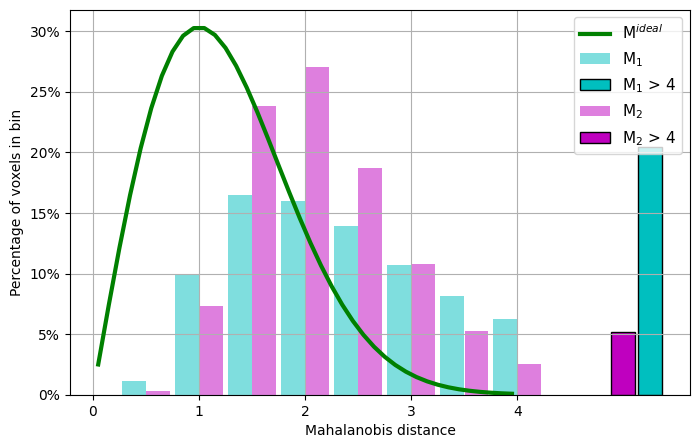

In [42]:
reload(au)

au.summarize_mahas(maha_lists['all_mahas1_mt'], maha_lists['all_mahas2_mt'], th=maha_th)

#### CIs

Fraction of points with 1-sigma CI crossing zero: 55.2% out of 4729
Fraction of points with 1-sigma have CI of the 2 methods intersecting: 84.2% out of 4729
Fraction of points with 2-sigma CI crossing zero: 86.0% out of 4729
Fraction of points with 2-sigma have CI of the 2 methods intersecting: 98.5% out of 4729
Fraction of points with 3-sigma CI crossing zero: 95.3% out of 4729
Fraction of points with 3-sigma have CI of the 2 methods intersecting: 99.9% out of 4729
Fraction of points with 4-sigma CI crossing zero: 97.6% out of 4729
Fraction of points with 4-sigma have CI of the 2 methods intersecting: 100.0% out of 4729
Fraction of points with 1-sigma CI crossing zero: 56.3% out of 4729
Fraction of points with 1-sigma have CI of the 2 methods overlapping: 82.7% out of 4729
Fraction of points with 2-sigma CI crossing zero: 82.8% out of 4729
Fraction of points with 2-sigma have CI of the 2 methods overlapping: 96.0% out of 4729
Fraction of points with 3-sigma CI crossing zero: 94.5% out

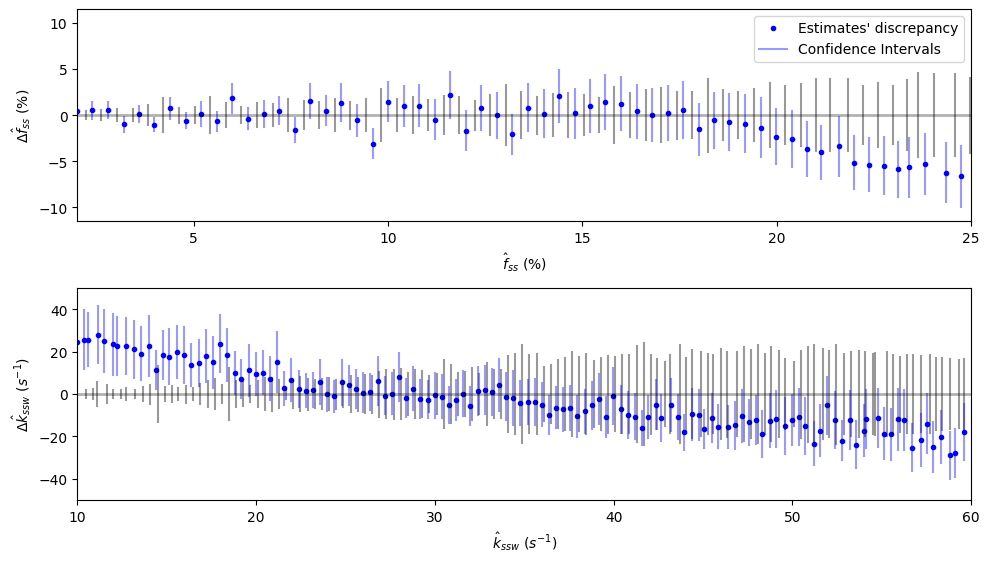

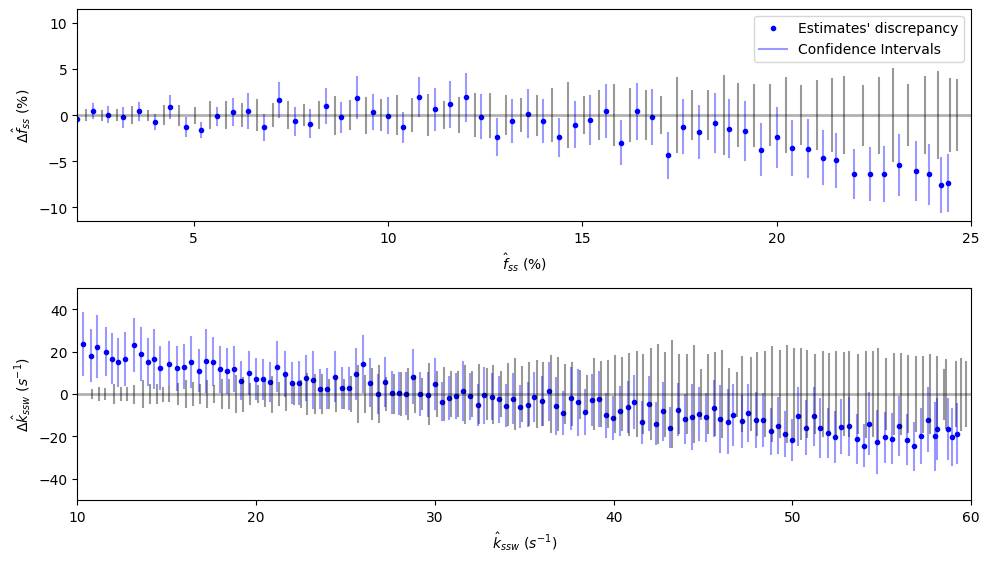

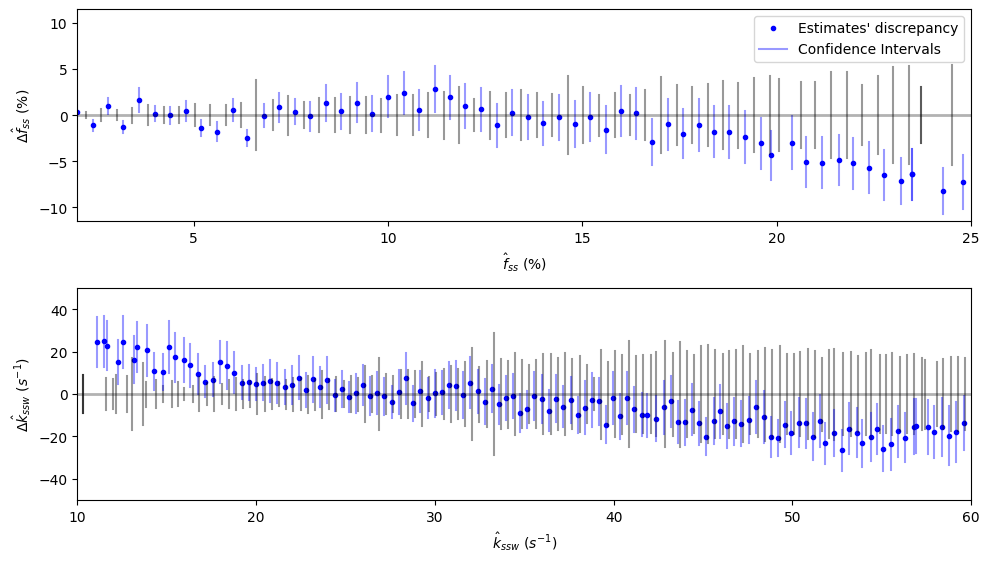

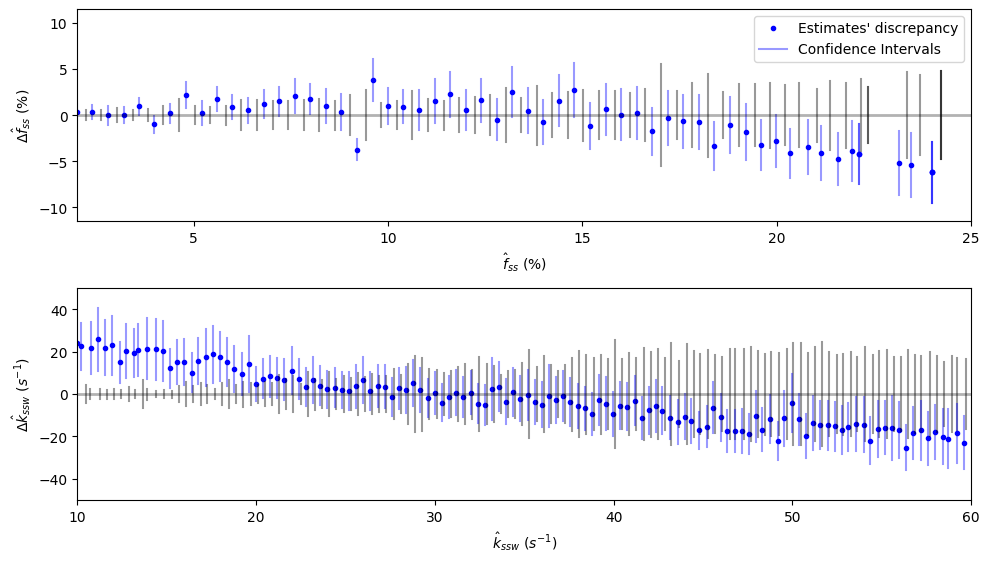

In [43]:
l_f_perc_CIs_intersect, l_k_perc_CIs_intersect = [], [] 
l_f_perc_NN_CI_covers_exact, l_k_perc_NN_CI_covers_exact = [], []

for human_MT_res in human_MT_UQ_stats.values():
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*human_MT_res['means_of_exact_posterior'])

    (f_perc_CIs_intersect, k_perc_CIs_intersect, f_perc_NN_CI_covers_exact, k_perc_NN_CI_covers_exact) = \
    au.analyze_CI_intersections(
        human_MT_res['f_est'], np.array(f_best_dotprod_arr), 
        human_MT_res['k_est'], np.array(k_best_dotprod_arr), 
        human_MT_res['cov_nnpred_scaled'], np.array(human_MT_res['covs_of_exact_posterior']), human_MT_res['good_xy_points'], 
        sli=-30, is_mt=True, figsize=(10, 8), # df=0.008, dk=15, fmin=0.07, fmax=0.3, result_fig=None
    )
    l_f_perc_CIs_intersect.append(f_perc_CIs_intersect)
    l_k_perc_CIs_intersect.append(k_perc_CIs_intersect)
    l_f_perc_NN_CI_covers_exact.append(f_perc_NN_CI_covers_exact)
    l_k_perc_NN_CI_covers_exact.append(k_perc_NN_CI_covers_exact)

In [44]:
print(f'fss CI intersect: {np.mean(l_f_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_f_perc_CIs_intersect):.1f}\\% (n={len(l_f_perc_CIs_intersect)})')
print(f'kssw CI intersect: {np.mean(l_k_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_k_perc_CIs_intersect):.1f}\\% (n={len(l_k_perc_CIs_intersect)})')
print('----')
print(f'fss CI inc true-MAP: {np.mean(l_f_perc_NN_CI_covers_exact):.1f}\\%$\\pm${np.std(l_f_perc_NN_CI_covers_exact):.1f}\\% (n={len(l_f_perc_NN_CI_covers_exact)})')
print(f'kssw CI inc true-MAP: {np.mean(l_k_perc_NN_CI_covers_exact):.1f}\\%$\\pm${np.std(l_k_perc_NN_CI_covers_exact):.1f}\\% (n={len(l_k_perc_NN_CI_covers_exact)})')

fss CI intersect: 98.5\%$\pm$0.5\% (n=4)
kssw CI intersect: 97.1\%$\pm$1.0\% (n=4)
----
fss CI inc true-MAP: 83.6\%$\pm$2.5\% (n=4)
kssw CI inc true-MAP: 81.2\%$\pm$2.1\% (n=4)


#### Scatters and Pearsons

In [ ]:
human_MT_pears_f_l, human_MT_pears_k_l, human_MT_pears_f_ci_l, human_MT_pears_k_ci_l = [], [], [], []

for human_MT_res in human_MT_UQ_stats.values():
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*human_MT_res['means_of_exact_posterior'])
    f_est_sli = human_MT_res['f_est'][:, human_vol_sli, :]
    k_est_sli = human_MT_res['k_est'][:, human_vol_sli, :]
    cov_est_sli = human_MT_res['cov_nnpred_scaled'][:, human_vol_sli, :]
    f_est_nn_l = [f_est_sli[_x, _y] for (_x, _y) in human_MT_res['good_xy_points']]
    k_est_nn_l = [k_est_sli[_x, _y] for (_x, _y) in human_MT_res['good_xy_points']]
    cov_nnpred_scaled_l = [cov_est_sli[_x, _y] for (_x, _y) in human_MT_res['good_xy_points']]
    
    pears_f, pears_k, pears_f_ci, pears_k_ci = au.analyze_scatter(
        f_est_nn_l, f_best_dotprod_arr, k_est_nn_l, k_best_dotprod_arr, 
        cov_nnpred_scaled_l, np.array(human_MT_res['covs_of_exact_posterior']),
        is_mt=True, alpha=0.2
    )
    human_MT_pears_f_l.append(pears_f)
    human_MT_pears_k_l.append(pears_k)
    human_MT_pears_f_ci_l.append(pears_f_ci)     
    human_MT_pears_k_ci_l.append(pears_k_ci)

#### Summary table

In [46]:
len(AGG_human_MT_res['nn_posterior_min_nrmse_percs'])

18857

In [47]:
[np.median(v['KL(P1||P2)']) for v in human_MT_UQ_stats.values()], [np.median(v['KL(P2||P1)']) for v in human_MT_UQ_stats.values()]

([2.060470302785986, 1.551398849569204, 1.6658582883686919, 3.472963620082104],
 [4.104488612341934, 2.1572312048624576, 2.060808105320453, 7.148569140688119])

In [48]:
KLdist_medians = [np.median(v['KL(P1||P2)']) for v in human_MT_UQ_stats.values()]
KLdist_means = [np.mean(v['KL(P1||P2)']) for v in human_MT_UQ_stats.values()]
#  'Jensen-Shannon Divergence',
#  'Hellinger Distance',
#  'Bhattacharyya Distance']
humanMT_JS_medians = [np.median(v['Jensen-Shannon Divergence']) for v in human_MT_UQ_stats.values()]
humanMT_Hell_medians = [np.median(v['Hellinger Distance']) for v in human_MT_UQ_stats.values()]

KLdist_medians, KLdist_means

([2.060470302785986, 1.551398849569204, 1.6658582883686919, 3.472963620082104],
 [2.935143531059281, 2.617664127798051, 2.831123254578016, 4.0641968368733785])

In [49]:
import pandas as pd
from IPython.display import display, Latex

mean_over_agg_voxels = False

if mean_over_agg_voxels:
    nn_posterior_min_nrmse_percs_DISP = AGG_human_MT_res['nn_posterior_min_nrmse_percs']
    exact_posterior_min_nrmse_percs_DISP = AGG_human_MT_res['exact_posterior_min_nrmse_percs']
else:
    nn_posterior_min_nrmse_percs_DISP = [np.mean(human_MT_UQ_stats[x]['nn_posterior_min_nrmse_percs']) for x in human_MT_UQ_stats.keys()]
    exact_posterior_min_nrmse_percs_DISP = [np.mean(human_MT_UQ_stats[x]['exact_posterior_min_nrmse_percs']) for x in human_MT_UQ_stats.keys()]

df = pd.DataFrame({  # \ estimate
    'Metrics \\downarrow | Setup\\rightarrow': [ # \\ \\ |\\ \\      
        'Fit\\ NRMSE\\ @\\ best\\ est.,','voxelwise' + (',\\ mean\\ per\\ subject' if not mean_over_agg_voxels else ''),
        "Estimates'\\ correlation", '(Pearson\\ r,\\ per\\ subject)',
        "CI\\ size\\ correlation", '(Pearson\\ r,\\ per\\ subject)',
        'Univariate\\ CIs\\ intersect','(voxels\'\\ perc.\\ per\\ subject)', #'CI\\ intersect\\ perc.', '(per\\ subject)', #,\\ across\\ n=4)',        
        'Mahalanobis\\ dist.,\\ ', '(voxels\'\\ median\\ per\\ subject)', # (^*exc.\\ outliers)',
        'Discrepant\\ posteriors','(\\%\\ voxels\\ per\\ subject)', #'Outliers\\ perc.', '(per\\ subject)', #,\\ across\\ n=4)',
        'Posteriors\\ divergence\\ metrics', '(voxels\'\\ median\\ per\\ subject)', ''
        ],
    'Healthy\\ humans,\\ ssMT\\ 3T\\ pulsed': [
        # NRMSEs:
        f'NN: {np.mean(nn_posterior_min_nrmse_percs_DISP):.1f}\\%$\\pm'+\
            f'${np.std(nn_posterior_min_nrmse_percs_DISP):.1f}\\% (n={len(nn_posterior_min_nrmse_percs_DISP)})',
        f'Ref: {np.mean(exact_posterior_min_nrmse_percs_DISP):.1f}\\%$\\pm'+\
            f'${np.std(exact_posterior_min_nrmse_percs_DISP):.1f}\\% (n={len(exact_posterior_min_nrmse_percs_DISP)})',
        # est correlation
        'f$_{s}$:\\ '+f'{np.mean(human_MT_pears_f_l):.2f}$\\pm${np.std(human_MT_pears_f_l):.2f}\\ (n={len(human_MT_pears_f_l)})',
        'k$_{sw}$:\\ '+f'{np.mean(human_MT_pears_k_l):.2f}$\\pm${np.std(human_MT_pears_k_l):.2f}\\ (n={len(human_MT_pears_k_l)})',
        # CI-size correlation
        'f$_{s}$:\\ '+f'{np.mean(human_MT_pears_f_ci_l):.2f}$\\pm${np.std(human_MT_pears_f_ci_l):.2f}\\ (n={len(human_MT_pears_f_ci_l)})',
        'k$_{sw}$:\\ '+f'{np.mean(human_MT_pears_k_ci_l):.2f}$\\pm${np.std(human_MT_pears_k_ci_l):.2f}\\ (n={len(human_MT_pears_k_ci_l)})',
        # CI intersect
        'f$_{ss}$:\\ '+f'{np.mean(l_f_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_f_perc_CIs_intersect):.1f}\\%\\ (n={len(l_f_perc_CIs_intersect)})',
        'k$_{ssw}$:\\ '+f'{np.mean(l_k_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_k_perc_CIs_intersect):.1f}\\%\\ (n={len(l_k_perc_CIs_intersect)})',
        f"M$_1$={np.nanmean(typical_parenchyma_mahas1):.2f}$\\pm${np.nanstd(typical_parenchyma_mahas1):.2f}\\ (n={len(typical_parenchyma_mahas1)})", 
        f"M$_2$={np.nanmean(typical_parenchyma_mahas2):.2f}$\\pm${np.nanstd(typical_parenchyma_mahas2):.2f}\\ (n={len(typical_parenchyma_mahas2)})", 
        f"$M_1>4$:\\ {100-np.mean(ok_mahas1_perc):.1f}\\%$\\pm${np.std(ok_mahas1_perc):.1f}\\%\\ (n={len(ok_mahas1_perc)})",
        f"$M_2>4$:\\ {100-np.mean(ok_mahas2_perc):.1f}\\%$\\pm${np.std(ok_mahas2_perc):.1f}\\%\\ (n={len(ok_mahas2_perc)})",
        f"KL: {np.mean(KLdist_medians):.2f}$\\pm${np.std(KLdist_medians):.2f}\\ (n={len(KLdist_medians)})",
        f"JS: {np.mean(humanMT_JS_medians):.2f}$\\pm${np.std(humanMT_JS_medians):.2f}\\ (n={len(humanMT_JS_medians)})",
        f"HL: {np.mean(humanMT_Hell_medians):.2f}$\\pm${np.std(humanMT_Hell_medians):.2f}\\ (n={len(humanMT_Hell_medians)})",
        ],
})
# Generate LaTeX code (default is tabular)
latex_code = df.to_latex(index=False, escape=False, column_format='l|cc|r')
# Convert 'tabular' to 'array' for MathJax/KaTeX rendering in Notebooks
# 1. Replace environment name
latex_array = latex_code.replace('tabular', 'array')
# 2. Replace booktabs rules with hline (if present)
latex_array = latex_array.replace('$','')
latex_array = latex_array.replace('\\toprule', '\\hline').replace('\\midrule', '\\hline').replace('\\bottomrule', '\\hline')
# 3. Wrap in math mode delimiters $$ ... $$
latex_display = f"$$ \n{latex_array}\n $$"
display(Latex(latex_display))
print(latex_code)

<IPython.core.display.Latex object>

\begin{tabular}{l|cc|r}
\toprule
Metrics \downarrow | Setup\rightarrow & Healthy\ humans,\ ssMT\ 3T\ pulsed \\
\midrule
Fit\ NRMSE\ @\ best\ est., & NN: 2.9\%$\pm$0.1\% (n=4) \\
voxelwise,\ mean\ per\ subject & Ref: 2.6\%$\pm$0.1\% (n=4) \\
Estimates'\ correlation & f$_{s}$:\ 0.95$\pm$0.00\ (n=4) \\
(Pearson\ r,\ per\ subject) & k$_{sw}$:\ 0.48$\pm$0.03\ (n=4) \\
CI\ size\ correlation & f$_{s}$:\ 0.76$\pm$0.05\ (n=4) \\
(Pearson\ r,\ per\ subject) & k$_{sw}$:\ 0.28$\pm$0.07\ (n=4) \\
Univariate\ CIs\ intersect & f$_{ss}$:\ 98.5\%$\pm$0.5\%\ (n=4) \\
(voxels'\ perc.\ per\ subject) & k$_{ssw}$:\ 97.1\%$\pm$1.0\%\ (n=4) \\
Mahalanobis\ dist.,\  & M$_1$=2.53$\pm$0.61\ (n=4) \\
(voxels'\ median\ per\ subject) & M$_2$=2.07$\pm$0.32\ (n=4) \\
Discrepant\ posteriors & $M_1>4$:\ 20.2\%$\pm$11.0\%\ (n=4) \\
(\%\ voxels\ per\ subject) & $M_2>4$:\ 5.2\%$\pm$1.2\%\ (n=4) \\
Posteriors\ divergence\ metrics & KL: 2.19$\pm$0.77\ (n=4) \\
(voxels'\ median\ per\ subject) & JS: 0.53$\pm$0.14\ (n=4) \\
 &

#### BCoV

In [50]:
_param_means = {'fss_gray_means': [], 'fss_white_means': [], 'kss_gray_means': [], 'kss_white_means': []}

for setup_name, human_MT_res in human_MT_UQ_stats.items():
    vol_name = setup_name.split('_w_')[0]
    data_xa = xr.open_dataset(f'data/{vol_name}.nc' )
    _param_means['fss_gray_means'].append(np.nanmean(data_xa['gray_mask'].to_numpy() * human_MT_res['f_est']))    
    _param_means['fss_white_means'].append(np.nanmean(data_xa['white_mask'].to_numpy() * human_MT_res['f_est']))
    _param_means['kss_gray_means'].append(np.nanmean(data_xa['gray_mask'].to_numpy() * human_MT_res['k_est']))
    _param_means['kss_white_means'].append(np.nanmean(data_xa['white_mask'].to_numpy() * human_MT_res['k_est']))

for _param_name, _param_value in _param_means.items():
    print(f'{_param_name}: {np.mean(_param_value):.1f}$\\pm${np.std(_param_value):.1f} (n={len(_param_value)}), CV$_{{BS}}$ = {100*np.std(_param_value)/np.mean(_param_value):.1f}\\%')    

fss_gray_means: 6.4$\pm$0.5 (n=4), CV$_{BS}$ = 7.1\%
fss_white_means: 11.3$\pm$0.2 (n=4), CV$_{BS}$ = 1.9\%
kss_gray_means: 24.9$\pm$0.5 (n=4), CV$_{BS}$ = 1.9\%
kss_white_means: 22.8$\pm$0.9 (n=4), CV$_{BS}$ = 3.9\%


### Patients

In [51]:
def patient2table(patient_MT_UQ_stats, sli=27):
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*patient_MT_UQ_stats['means_of_exact_posterior'])
    print('len good_xy_points', len(patient_MT_UQ_stats['good_xy_points']))        
    (patient_f_perc_CIs_intersect, patient_k_perc_CIs_intersect, f_perc_NN_CI_covers_exact, k_perc_NN_CI_covers_exact) = \
        au.analyze_CI_intersections(
            patient_MT_UQ_stats['f_est'], np.array(f_best_dotprod_arr), 
            patient_MT_UQ_stats['k_est'], np.array(k_best_dotprod_arr), 
            patient_MT_UQ_stats['cov_nnpred_scaled'], np.array(patient_MT_UQ_stats['covs_of_exact_posterior']), patient_MT_UQ_stats['good_xy_points'], 
            sli=sli, is_mt=True, figsize=(10, 8), # df=0.008, dk=15, fmin=0.07, fmax=0.3, result_fig=None
        )
    # !! slice of interest (sli) should be synced to the notebook (erlangen.ipynb in this case)
    
    if take_typical_sample:
        patient_mahas1 = np.median(patient_MT_UQ_stats['mahas1'].reshape(-1, 10), axis=1)
        patient_mahas2 = np.median(patient_MT_UQ_stats['mahas2'].reshape(-1, 10), axis=1)
    else:
        patient_mahas1 = patient_MT_UQ_stats['mahas1']
        patient_mahas2 = patient_MT_UQ_stats['mahas2']    
        
    patient_ok_mahas1_perc = 100*np.sum(patient_mahas1 < maha_th)/len(patient_mahas1)
    patient_ok_mahas2_perc = 100*np.sum(patient_mahas2 < maha_th)/len(patient_mahas2)
    
    patientMT_KL_median = np.median(patient_MT_UQ_stats['KL(P1||P2)'])
    patientMT_JS_median = np.median(patient_MT_UQ_stats['Jensen-Shannon Divergence']) 
    patientMT_Hell_median = np.median(patient_MT_UQ_stats['Hellinger Distance'])
    f_est_sli = patient_MT_UQ_stats['f_est'][:, sli, :]
    k_est_sli = patient_MT_UQ_stats['k_est'][:, sli, :]
    cov_nnpred_scaled_sli = patient_MT_UQ_stats['cov_nnpred_scaled'][:, sli, :]
    f_est_nn_l = [f_est_sli[_x, _y] for (_x, _y) in patient_MT_UQ_stats['good_xy_points']]
    k_est_nn_l = [k_est_sli[_x, _y] for (_x, _y) in patient_MT_UQ_stats['good_xy_points']]
    cov_nnpred_scaled_l = [cov_nnpred_scaled_sli[_x, _y] for (_x, _y) in patient_MT_UQ_stats['good_xy_points']]

    pears_f, pears_k, pears_f_ci, pears_k_ci = au.analyze_scatter(
        f_est_nn_l, f_best_dotprod_arr, k_est_nn_l, k_best_dotprod_arr, 
        cov_nnpred_scaled_l, np.array(patient_MT_UQ_stats['covs_of_exact_posterior']),
        is_mt=True, alpha=0.2 #, to_plot=False
    )
    return [
        f'NN: {np.mean(patient_MT_UQ_stats['nn_posterior_min_nrmse_percs']):.1f}\\%' +\
            ('$\\pm$'+f'{np.std(patient_MT_UQ_stats['nn_posterior_min_nrmse_percs']):.1f}\\% (n={len(patient_MT_UQ_stats['nn_posterior_min_nrmse_percs'])})' if mean_over_agg_voxels else ''),
        f'Ref: {np.mean(patient_MT_UQ_stats['exact_posterior_min_nrmse_percs']):.1f}\\%' +\
            ('$\\pm$'+f'{np.std(patient_MT_UQ_stats['exact_posterior_min_nrmse_percs']):.1f}\\% (n={len(patient_MT_UQ_stats['exact_posterior_min_nrmse_percs'])})' if mean_over_agg_voxels else ''),
        # est correlation
        'f$_{s}$:\\ '+f'{pears_f:.2f}',
        'k$_{sw}$:\\ '+f'{pears_k:.2f}',
        # CI-size correlation
        'f$_{s}$:\\ '+f'{pears_f_ci:.2f}',
        'k$_{sw}$:\\ '+f'{pears_k_ci:.2f}',
        # CI intersect
        'f$_{ss}$:\\ '+f'{patient_f_perc_CIs_intersect:.1f}\\%',
        'k$_{ssw}$:\\ '+f'{patient_k_perc_CIs_intersect:.1f}\\%',
        f"M$_1$={np.nanmedian(patient_mahas1):.2f}", #an(patient_mahas1_for_meanstd):.2f}$\\pm${np.nanstd(patient_mahas1_for_meanstd):.2f}", 
        f"M$_2$={np.nanmedian(patient_mahas2):.2f}", #$\\pm${np.nanstd(patient_mahas2_for_meanstd):.2f}", 
        f"$M_1>4$:\\ {100-patient_ok_mahas1_perc:.1f}\\%",
        f"$M_2>4$:\\ {100-patient_ok_mahas2_perc:.1f}\\%",
        f'KL: {patientMT_KL_median:.2f}', f'JS: {patientMT_JS_median:.2f}', f'HL: {patientMT_Hell_median:.2f}'
        ]

len good_xy_points 4943
Fraction of points with 1-sigma CI crossing zero: 65.7% out of 4943
Fraction of points with 1-sigma have CI of the 2 methods intersecting: 90.0% out of 4943
Fraction of points with 2-sigma CI crossing zero: 88.4% out of 4943
Fraction of points with 2-sigma have CI of the 2 methods intersecting: 98.5% out of 4943
Fraction of points with 3-sigma CI crossing zero: 94.0% out of 4943
Fraction of points with 3-sigma have CI of the 2 methods intersecting: 99.7% out of 4943
Fraction of points with 4-sigma CI crossing zero: 96.5% out of 4943
Fraction of points with 4-sigma have CI of the 2 methods intersecting: 99.9% out of 4943
Fraction of points with 1-sigma CI crossing zero: 55.6% out of 4943
Fraction of points with 1-sigma have CI of the 2 methods overlapping: 83.6% out of 4943
Fraction of points with 2-sigma CI crossing zero: 86.1% out of 4943
Fraction of points with 2-sigma have CI of the 2 methods overlapping: 96.6% out of 4943
Fraction of points with 3-sigma CI c

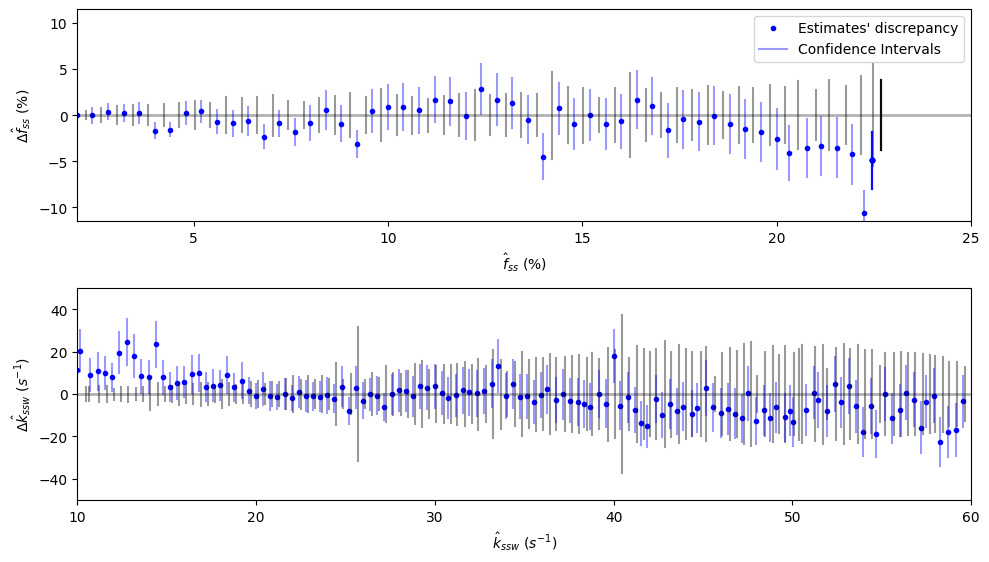

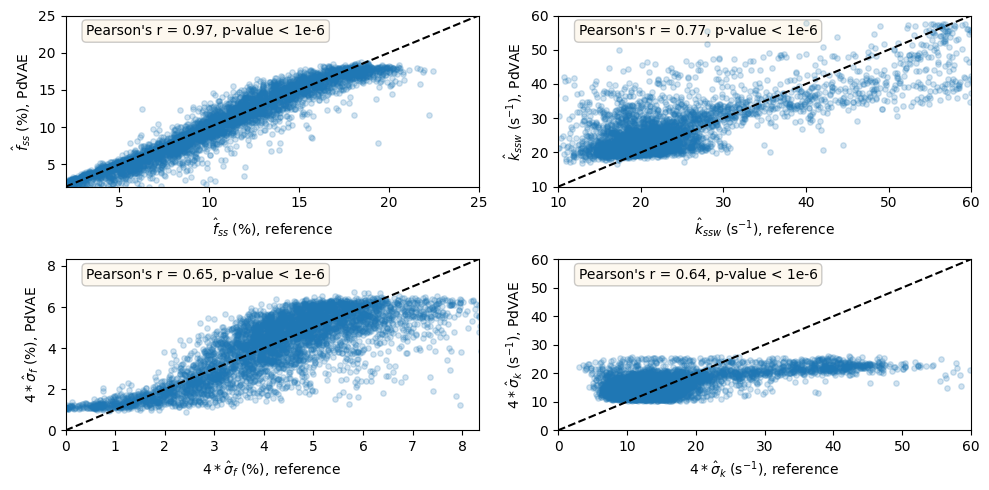

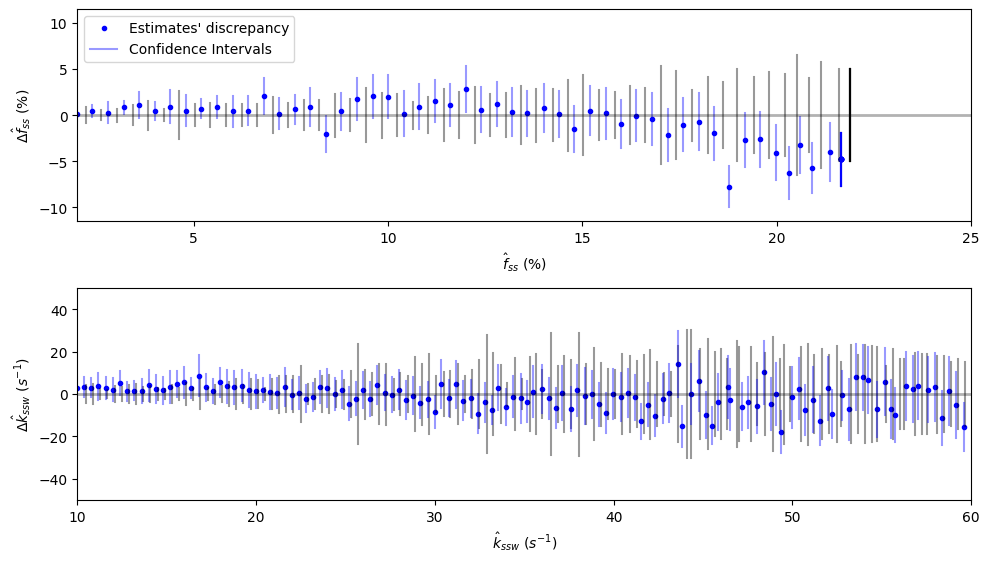

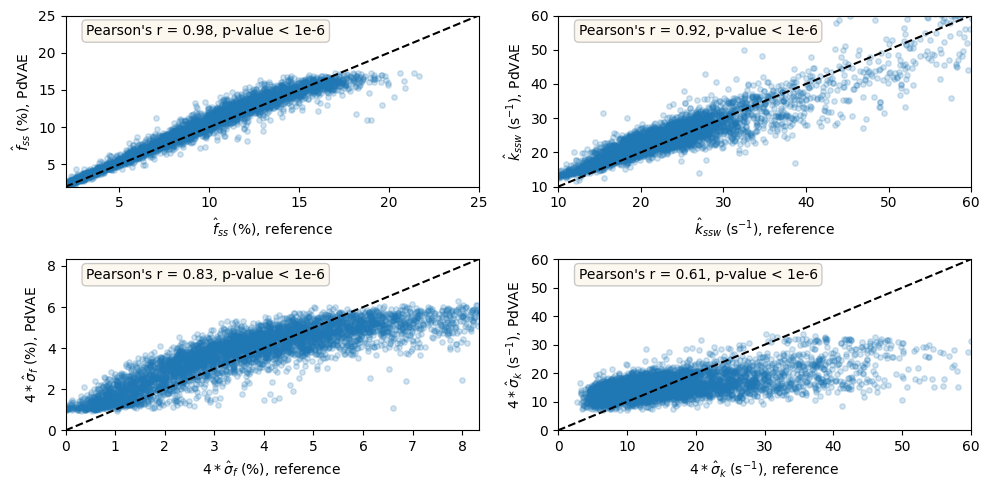

In [52]:
GBM_patient_res_folder = 'figs/patients/erlangen__2026-06-08_22h'

patient_MT_UQ_stats = np.load(f'{GBM_patient_res_folder}/intermediates/MT_UQ_stats_allpoints.npz')  
df['GBM patient,\\ ssMT\\ 3T\\ pulsed'] = patient2table(patient_MT_UQ_stats, sli=27)
GBM_patient_MT_UQ_stats = patient_MT_UQ_stats

AD_patient_res_folder = 'figs/patients/ichilov_alz__2026-06-09_01h/'
ADpatient_MT_UQ_stats = np.load(f'{AD_patient_res_folder}/intermediates/MT_UQ_stats_allpoints.npz')  
df['AD patient,\\ ssMT\\ 3T\\ pulsed'] = patient2table(ADpatient_MT_UQ_stats, sli=3)

# /home/alexf/phiVAE/figs/patients/ichilov_alz__2026-05-27_20h

In [53]:
df

,Metrics \downarrow | Setup\rightarrow,"Healthy\ humans,\ ssMT\ 3T\ pulsed","GBM patient,\ ssMT\ 3T\ pulsed","AD patient,\ ssMT\ 3T\ pulsed"
0,"Fit\ NRMSE\ @\ best\ est.,",NN: 2.9\%$\pm$0.1\% (n=4),NN: 2.4\%,NN: 3.1\%
1,"voxelwise,\ mean\ per\ subject",Ref: 2.6\%$\pm$0.1\% (n=4),Ref: 2.2\%,Ref: 2.8\%
2,Estimates'\ correlation,f$_{s}$:\ 0.95$\pm$0.00\ (n=4),f$_{s}$:\ 0.97,f$_{s}$:\ 0.98
3,"(Pearson\ r,\ per\ subject)",k$_{sw}$:\ 0.48$\pm$0.03\ (n=4),k$_{sw}$:\ 0.77,k$_{sw}$:\ 0.92
4,CI\ size\ correlation,f$_{s}$:\ 0.76$\pm$0.05\ (n=4),f$_{s}$:\ 0.65,f$_{s}$:\ 0.83
5,"(Pearson\ r,\ per\ subject)",k$_{sw}$:\ 0.28$\pm$0.07\ (n=4),k$_{sw}$:\ 0.64,k$_{sw}$:\ 0.61
6,Univariate\ CIs\ intersect,f$_{ss}$:\ 98.5\%$\pm$0.5\%\ (n=4),f$_{ss}$:\ 98.5\%,f$_{ss}$:\ 100.0\%
7,(voxels'\ perc.\ per\ subject),k$_{ssw}$:\ 97.1\%$\pm$1.0\%\ (n=4),k$_{ssw}$:\ 96.6\%,k$_{ssw}$:\ 99.9\%
8,"Mahalanobis\ dist.,\",M$_1$=2.53$\pm$0.61\ (n=4),M$_1$=2.69,M$_1$=2.82
9,(voxels'\ median\ per\ subject),M$_2$=2.07$\pm$0.32\ (n=4),M$_2$=1.98,M$_2$=2.30


## Mouse runs

In [54]:
import os, numpy as np

mice_MT_UQ_stats = {}
mice_APT_UQ_stats = {} 

mice_folders = []
for x in os.listdir('figs/mice/'):
    if not 'BAD' in x and os.path.isdir(f'figs/mice/{x}'): #x.startswith('vol'):
        print(x)
        try:
            mice_MT_UQ_stats[x] = np.load(f'figs/mice/{x}/intermediates/MT_UQ_stats_allpoints.npz')
            mice_folders.append(f'figs/mice/{x}')
        except Exception as e:
            print(e)
        try:
            mice_APT_UQ_stats[x] = np.load(f'figs/mice/{x}/intermediates/APT_UQ_stats_allpoints.npz')    
        except Exception as e:
            print(e)

ozohar_two_ears_20240404_091158
ozohar_right_20240404_125156
C4_None_20_alex
[Errno 2] No such file or directory: 'figs/mice/C4_None_20_alex/intermediates/MT_UQ_stats_allpoints.npz'
[Errno 2] No such file or directory: 'figs/mice/C4_None_20_alex/intermediates/APT_UQ_stats_allpoints.npz'
ped_Control_2L_2025-01-09
ped_C1_1L_20241113_1245
ped_Control_2R_2025-01-09
ped_Control_1L1R_2025-01-09
fig2
[Errno 2] No such file or directory: 'figs/mice/fig2/intermediates/MT_UQ_stats_allpoints.npz'
[Errno 2] No such file or directory: 'figs/mice/fig2/intermediates/APT_UQ_stats_allpoints.npz'
ped_Control_None_2025-01-09


In [55]:
mice_folders

['figs/mice/ozohar_two_ears_20240404_091158',
 'figs/mice/ozohar_right_20240404_125156',
 'figs/mice/ped_Control_2L_2025-01-09',
 'figs/mice/ped_C1_1L_20241113_1245',
 'figs/mice/ped_Control_2R_2025-01-09',
 'figs/mice/ped_Control_1L1R_2025-01-09',
 'figs/mice/ped_Control_None_2025-01-09']

In [56]:
len(mice_MT_UQ_stats.keys()), mice_MT_UQ_stats.keys()

(7,
 dict_keys(['ozohar_two_ears_20240404_091158', 'ozohar_right_20240404_125156', 'ped_Control_2L_2025-01-09', 'ped_C1_1L_20241113_1245', 'ped_Control_2R_2025-01-09', 'ped_Control_1L1R_2025-01-09', 'ped_Control_None_2025-01-09']))

In [57]:
list(mice_MT_UQ_stats['ped_C1_1L_20241113_1245'].keys())

['mahas1',
 'mahas2',
 'CR_areas',
 'nnCR_areas',
 'good_xy_points',
 'timings',
 'train_time',
 'f_est',
 'k_est',
 'cov_nnpred_scaled',
 'covs_of_exact_posterior',
 'modes_of_exact_posterior',
 'means_of_exact_posterior',
 'exact_posterior_min_nrmse_percs',
 'nn_posterior_min_nrmse_percs',
 'KL(P1||P2)',
 'KL(P2||P1)',
 'Jensen-Shannon Divergence',
 'Hellinger Distance',
 'Bhattacharyya Distance',
 'cdf_at_gt']

In [58]:
mice_MT_UQ_stats['ped_C1_1L_20241113_1245']['cov_nnpred_scaled'].shape

(24, 1, 35, 2, 2)

In [59]:
list_keys = [
        'means_of_exact_posterior','covs_of_exact_posterior', 'timings',
        'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'mahas1', 'mahas2'
        ]
AGG_mice_APT_res = {}
for k in list_keys:
    AGG_mice_APT_res[k] = np.concatenate([x.get(k, []) for x in mice_APT_UQ_stats.values()])    
for k in ['f_est', 'k_est', 'cov_nnpred_scaled']:    
    AGG_mice_APT_res[k] = np.concatenate([[x[k][_x, 0, _y] for (_x, _y) in x['good_xy_points']] for x in mice_APT_UQ_stats.values()], axis=0)
    
AGG_mice_MT_res = {}
for k in list_keys:
    AGG_mice_MT_res[k] = np.concatenate([x.get(k, []) for x in mice_MT_UQ_stats.values()])    
for k in ['f_est', 'k_est', 'cov_nnpred_scaled']:    
    AGG_mice_MT_res[k] = np.concatenate([[x[k][_x, 0, _y] for (_x, _y) in x['good_xy_points']] for x in mice_MT_UQ_stats.values()], axis=0)

### timings

In [60]:
train_timings = [np.sum(x['train_time']) for x in mice_MT_UQ_stats.values()]
print(fr"Training time (two protocols): {np.mean(train_timings)/60:.1f}$\pm{np.std(train_timings)/60:.1f}$min")
len(train_timings)

Training time (two protocols): 7.0$\pm0.9$min


7

In [61]:
mt_apt_slice_timings = []
for stats in [mice_MT_UQ_stats, mice_APT_UQ_stats]:
    listlist = [x['timings'] for x in stats.values()]
    all_voxel_timings = np.concatenate(listlist)
    print(f"n(mice)={len(listlist)}, n(voxels)={len(all_voxel_timings)}")
    slice_timings = [np.sum(x['timings']) for x in stats.values()]
    print(fr"Bayes per voxel: {np.mean(all_voxel_timings):.2f}$\pm{np.std(all_voxel_timings):.2f}$sec")
    print(fr"Bayes per slice/mouse: {np.mean(slice_timings)/60:.1f}$\pm{np.std(slice_timings)/60:.1f}$min")
    mt_apt_slice_timings = slice_timings if len(mt_apt_slice_timings)==0 else np.array(mt_apt_slice_timings) + np.array(slice_timings)

print(fr"Bayes per slice/mouse: {np.mean(mt_apt_slice_timings)/60:.1f}$\pm{np.std(mt_apt_slice_timings)/60:.1f}$min")

n(mice)=7, n(voxels)=3590
Bayes per voxel: 0.57$\pm0.01$sec
Bayes per slice/mouse: 4.9$\pm0.6$min
n(mice)=7, n(voxels)=3590
Bayes per voxel: 0.57$\pm0.01$sec
Bayes per slice/mouse: 4.9$\pm0.6$min
Bayes per slice/mouse: 9.8$\pm1.3$min


### NRMSEs

APT nn_posterior_min_nrmse_percs: 3.3\%$\pm$1.6\% (n=3590)
APT exact_posterior_min_nrmse_percs: 3.2\%$\pm$1.5\% (n=3590)


array([<Axes: xlabel='NRMSE at MAP (%)\n(exact posterior)', ylabel='NRMSE at MAP  (%)\n(neural network)'>,
       <Axes: xlabel='NRMSE at MAP (%)\n(exact posterior)', ylabel='NRMSE at MAP  (%)\n(neural network)'>],
      dtype=object)

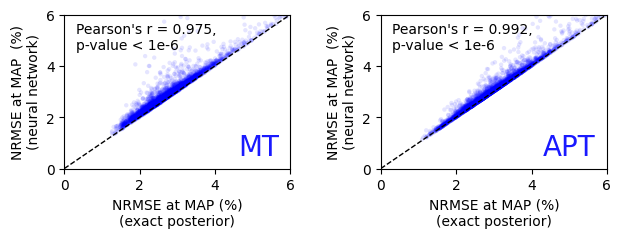

In [116]:
from scipy.stats import pearsonr

print(
    f'APT nn_posterior_min_nrmse_percs: {np.mean(AGG_mice_APT_res['nn_posterior_min_nrmse_percs']):.1f}\\%$\\pm'+\
    f'${np.std(AGG_mice_APT_res['nn_posterior_min_nrmse_percs']):.1f}\\% (n={len(AGG_mice_APT_res['nn_posterior_min_nrmse_percs'])})'
)
print(
    f'APT exact_posterior_min_nrmse_percs: {np.mean(AGG_mice_APT_res['exact_posterior_min_nrmse_percs']):.1f}\\%$\\pm'+\
    f'${np.std(AGG_mice_APT_res['exact_posterior_min_nrmse_percs']):.1f}\\% (n={len(AGG_mice_APT_res['exact_posterior_min_nrmse_percs'])})'
)

def plot_nrmse_scatter(mt_agg=None, apt_agg=None, fig=None, mt_apt_or_both='both', draw_title=True):
    fig = fig or plt.figure(figsize=(7, 2))
    axes = fig.subplots(1, 2) if mt_apt_or_both=='both' else [fig.subplots(1,1)]
    ops = []
    if mt_apt_or_both in ['MT', 'both'] and mt_agg is not None:
        ops.append([mt_agg, 'MT'])
    if mt_apt_or_both in ['APT', 'both'] and apt_agg is not None:
        ops.append([apt_agg, 'APT'])
    if len(ops)==0:
        raise ValueError("No data to plot, check mt_apt_or_both and input aggs")
    for axind, (data, title) in enumerate(ops):    
        if (title=='MT' and not mt_apt_or_both in ['MT', 'both']) or \
           (title=='APT' and not mt_apt_or_both in ['APT', 'both']):
            pass
        ax = axes[axind]          
        ax.plot([0,6],[0,6],'k--', linewidth=1)
        xx, yy = data['exact_posterior_min_nrmse_percs'], data['nn_posterior_min_nrmse_percs']
        ax.scatter(xx, yy, s=10, alpha=0.1, edgecolors='none', color='b')
        ax.set_xlabel('NRMSE at MAP (%)\n(exact posterior)') #min. NRMSE @ MAP est. (%)                    
        ax.set_ylabel('NRMSE at MAP  (%)\n(neural network)') 
        ax.set_xlim(0, 6); ax.set_ylim(0, 6)
        pearsons_r_f, p_value = pearsonr(xx, yy)
        ax.text(
            0.05, 0.95, f"Pearson's r = {pearsons_r_f:.3f}, \n" + (f"p-value={p_value:.2e}" if p_value>1e-6 else "p-value < 1e-6"),
            transform=ax.transAxes, verticalalignment='top',
        )
        if draw_title:
            ax.text(0.95, 0.05, title, fontsize=20, color='b', alpha=0.9, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right')
        plt.subplots_adjust(wspace=0.4) 
    return axes
    
plot_nrmse_scatter(mt_agg=AGG_mice_MT_res, apt_agg=AGG_mice_APT_res)


### Mahas

In [63]:
maha_lists = {}
maha_lists['all_mahas1_mt'] = np.concatenate([x['mahas1'] for x in mice_MT_UQ_stats.values()])
maha_lists['all_mahas2_mt'] = np.concatenate([x['mahas2'] for x in mice_MT_UQ_stats.values()])
maha_lists['all_mahas1_apt'] = np.concatenate([x['mahas1'] for x in mice_APT_UQ_stats.values()])
maha_lists['all_mahas2_apt'] = np.concatenate([x['mahas2'] for x in mice_APT_UQ_stats.values()])

maha_lists['MT_mahas1_voxelwise_medians_by_subject'] = [np.median(x['mahas1'].reshape(-1, 10), axis=1) for x in mice_MT_UQ_stats.values()]
maha_lists['MT_mahas2_voxelwise_medians_by_subject'] = [np.median(x['mahas2'].reshape(-1, 10), axis=1) for x in mice_MT_UQ_stats.values()]
maha_lists['APT_mahas1_voxelwise_medians_by_subject'] = [np.median(x['mahas1'].reshape(-1, 10), axis=1) for x in mice_APT_UQ_stats.values()]
maha_lists['APT_mahas2_voxelwise_medians_by_subject'] = [np.median(x['mahas2'].reshape(-1, 10), axis=1) for x in mice_APT_UQ_stats.values()]

len(maha_lists['all_mahas2_apt'] )

all_mahas1_mt_below_4 = maha_lists['all_mahas1_mt'][maha_lists['all_mahas1_mt']<4]
all_mahas2_mt_below_4 = maha_lists['all_mahas2_mt'][maha_lists['all_mahas2_mt']<4]
all_mahas1_apt_below_4 = maha_lists['all_mahas1_apt'][maha_lists['all_mahas1_apt']<4]
all_mahas2_apt_below_4 = maha_lists['all_mahas2_apt'][maha_lists['all_mahas2_apt']<4]

In [64]:

ok_mahas_perc_dict = {}
for statname, stat_list in zip(['MT','APT'], [mice_MT_UQ_stats, mice_APT_UQ_stats]):
    for k in ['mahas1', 'mahas2']:    
        if take_typical_sample:
            ok_mahas_perc = [100*np.sum(np.median(stat[k].reshape(-1,10), axis=1) < maha_th)/len(np.median(stat[k].reshape(-1,10), axis=1)) for stat in stat_list.values()]
        else:
            ok_mahas_perc = [100*np.sum(stat[k] < maha_th)/len(stat[k]) for stat in stat_list.values()]
        
        ok_mahas_perc_dict[f'{statname}_{k}'] = ok_mahas_perc
        print(k, statname)
        print(f'ok_mahas_perc (<{maha_th}) = {np.mean(ok_mahas_perc):.1f}\\%$\pm${np.std(ok_mahas_perc):.1f}\\% (n={len(ok_mahas_perc)})')
        print(f'bad_mahas_perc (<{maha_th}) = {np.mean(100-np.array(ok_mahas_perc)):.1f}\\%$\pm${np.std(ok_mahas_perc):.1f}\\% (n={len(ok_mahas_perc)})')

mahas1 MT
ok_mahas_perc (<4) = 87.1\%$\pm$6.0\% (n=7)
bad_mahas_perc (<4) = 12.9\%$\pm$6.0\% (n=7)
mahas2 MT
ok_mahas_perc (<4) = 91.9\%$\pm$4.0\% (n=7)
bad_mahas_perc (<4) = 8.1\%$\pm$4.0\% (n=7)
mahas1 APT
ok_mahas_perc (<4) = 96.3\%$\pm$1.4\% (n=7)
bad_mahas_perc (<4) = 3.7\%$\pm$1.4\% (n=7)
mahas2 APT
ok_mahas_perc (<4) = 91.9\%$\pm$5.6\% (n=7)
bad_mahas_perc (<4) = 8.1\%$\pm$5.6\% (n=7)


<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1763304/1374370416.py:11: SyntaxWarning: invalid escape sequence '\p'
  print(f'ok_mahas_perc (<{maha_th}) = {np.mean(ok_mahas_perc):.1f}\\%$\pm${np.std(ok_mahas_perc):.1f}\\% (n={len(ok_mahas_perc)})')
/tmp/ipykernel_1763304/1374370416.py:12: SyntaxWarning: invalid escape sequence '\p'
  print(f'bad_mahas_perc (<{maha_th}) = {np.mean(100-np.array(ok_mahas_perc)):.1f}\\%$\pm${np.std(ok_mahas_perc):.1f}\\% (n={len(ok_mahas_perc)})')


/home/alexf/phiVAE/analyze_uncertainty/metrics.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{x:.0f}%" for x in plt.gca().get_yticks() * 100])


<Axes: xlabel='Mahalanobis distance', ylabel='Percentage of voxels in bin'>

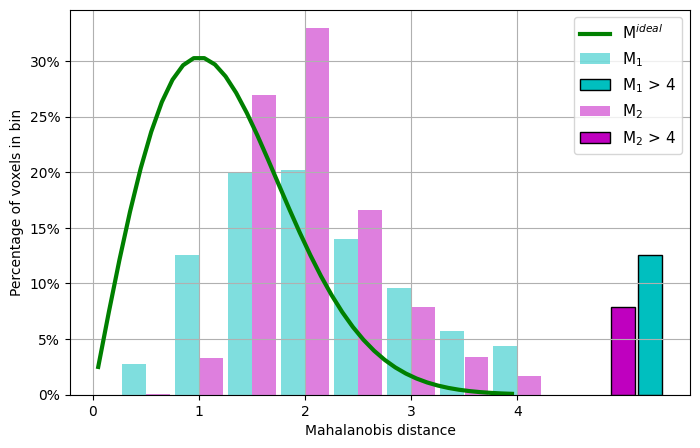

In [65]:
au.summarize_mahas(maha_lists['all_mahas1_mt'], maha_lists['all_mahas2_mt'], th=maha_th)

### CIs

In [ ]:
l_fss_perc_CIs_intersect, l_kssw_perc_CIs_intersect = [], [] 
l_fss_perc_NN_CI_covers_exact, l_kssw_perc_NN_CI_covers_exact = [], []

for human_MT_res in mice_MT_UQ_stats.values():
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*human_MT_res['means_of_exact_posterior'])

    (f_perc_CIs_intersect, k_perc_CIs_intersect, f_perc_NN_CI_covers_exact, k_perc_NN_CI_covers_exact) = \
    au.analyze_CI_intersections(
        human_MT_res['f_est'], np.array(f_best_dotprod_arr), 
        human_MT_res['k_est'], np.array(k_best_dotprod_arr), 
        human_MT_res['cov_nnpred_scaled'], np.array(human_MT_res['covs_of_exact_posterior']), human_MT_res['good_xy_points'], 
        sli=0, is_mt=True, figsize=(10, 8), # df=0.008, dk=15, fmin=0.07, fmax=0.3, result_fig=None
    )
    l_fss_perc_CIs_intersect.append(f_perc_CIs_intersect)
    l_kssw_perc_CIs_intersect.append(k_perc_CIs_intersect)
    l_fss_perc_NN_CI_covers_exact.append(f_perc_NN_CI_covers_exact)
    l_kssw_perc_NN_CI_covers_exact.append(k_perc_NN_CI_covers_exact)

In [67]:
print(f'fss CI intersect: {np.mean(l_f_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_f_perc_CIs_intersect):.1f}\\% (n={len(l_f_perc_CIs_intersect)})')
print(f'kssw CI intersect: {np.mean(l_k_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_k_perc_CIs_intersect):.1f}\\% (n={len(l_k_perc_CIs_intersect)})')
print('----')
print(f'fss CI inc true-MAP: {np.mean(l_f_perc_NN_CI_covers_exact):.1f}\\%$\\pm${np.std(l_f_perc_NN_CI_covers_exact):.1f}\\% (n={len(l_f_perc_NN_CI_covers_exact)})')
print(f'kssw CI inc true-MAP: {np.mean(l_k_perc_NN_CI_covers_exact):.1f}\\%$\\pm${np.std(l_k_perc_NN_CI_covers_exact):.1f}\\% (n={len(l_k_perc_NN_CI_covers_exact)})')

fss CI intersect: 98.5\%$\pm$0.5\% (n=4)
kssw CI intersect: 97.1\%$\pm$1.0\% (n=4)
----
fss CI inc true-MAP: 83.6\%$\pm$2.5\% (n=4)
kssw CI inc true-MAP: 81.2\%$\pm$2.1\% (n=4)


In [ ]:

l_f_perc_CIs_intersect, l_k_perc_CIs_intersect = [], [] 
l_f_perc_NN_CI_covers_exact, l_k_perc_NN_CI_covers_exact = [], []

for mouse_APT_res in mice_APT_UQ_stats.values():
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*mouse_APT_res['means_of_exact_posterior'])

    (f_perc_CIs_intersect, k_perc_CIs_intersect, f_perc_NN_CI_covers_exact, k_perc_NN_CI_covers_exact) = \
    au.analyze_CI_intersections(
        mouse_APT_res['f_est'], np.array(f_best_dotprod_arr), 
        mouse_APT_res['k_est'], np.array(k_best_dotprod_arr), 
        mouse_APT_res['cov_nnpred_scaled'], np.array(mouse_APT_res['covs_of_exact_posterior']), mouse_APT_res['good_xy_points'], 
        sli=0, is_mt=False, figsize=(10, 8), df=0.008, dk=15, fmin=0.07, fmax=0.3
    )
    l_f_perc_CIs_intersect.append(f_perc_CIs_intersect)
    l_k_perc_CIs_intersect.append(k_perc_CIs_intersect)
    l_f_perc_NN_CI_covers_exact.append(f_perc_NN_CI_covers_exact)
    l_k_perc_NN_CI_covers_exact.append(k_perc_NN_CI_covers_exact)


In [69]:
print(f'fs CI intersect: {np.mean(l_f_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_f_perc_CIs_intersect):.1f}\\% (n={len(l_f_perc_CIs_intersect)})')
print(f'ksw CI intersect: {np.mean(l_k_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_k_perc_CIs_intersect):.1f}\\% (n={len(l_k_perc_CIs_intersect)})')
print('----')
print(f'fs CI inc true-MAP: {np.mean(l_f_perc_NN_CI_covers_exact):.1f}\\%$\\pm${np.std(l_f_perc_NN_CI_covers_exact):.1f}\\% (n={len(l_f_perc_NN_CI_covers_exact)})')
print(f'ksw CI inc true-MAP: {np.mean(l_k_perc_NN_CI_covers_exact):.1f}\\%$\\pm${np.std(l_k_perc_NN_CI_covers_exact):.1f}\\% (n={len(l_k_perc_NN_CI_covers_exact)})')

fs CI intersect: 99.9\%$\pm$0.1\% (n=7)
ksw CI intersect: 99.5\%$\pm$0.4\% (n=7)
----
fs CI inc true-MAP: 93.3\%$\pm$4.1\% (n=7)
ksw CI inc true-MAP: 94.1\%$\pm$6.0\% (n=7)


### Scatters and Pearsons

In [ ]:
reload(au)
APT_pears_f_l, APT_pears_k_l, APT_pears_f_ci_l, APT_pears_k_ci_l = [], [], [], []
for mouse_APT_res in mice_APT_UQ_stats.values():
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*mouse_APT_res['means_of_exact_posterior'])
    f_est_nn_l = [mouse_APT_res['f_est'][_x, 0, _y] for (_x, _y) in mouse_APT_res['good_xy_points']]
    k_est_nn_l = [mouse_APT_res['k_est'][_x, 0, _y] for (_x, _y) in mouse_APT_res['good_xy_points']]
    cov_nnpred_scaled_l = [mouse_APT_res['cov_nnpred_scaled'][_x, 0, _y] for (_x, _y) in mouse_APT_res['good_xy_points']]
    
    pears_f, pears_k, pears_f_ci, pears_k_ci = au.analyze_scatter(
        f_est_nn_l, f_best_dotprod_arr, k_est_nn_l, k_best_dotprod_arr, 
        cov_nnpred_scaled_l, np.array(mouse_APT_res['covs_of_exact_posterior']),
        is_mt=False, alpha=0.2
    )
    APT_pears_f_l.append(pears_f)
    APT_pears_k_l.append(pears_k)
    APT_pears_f_ci_l.append(pears_f_ci)     
    APT_pears_k_ci_l.append(pears_k_ci)

MT_pears_f_l, MT_pears_k_l, MT_pears_f_ci_l, MT_pears_k_ci_l = [], [], [], []
for MT_res in mice_MT_UQ_stats.values():
    f_best_dotprod_arr, k_best_dotprod_arr = zip(*MT_res['means_of_exact_posterior'])
    f_est_nn_l = [MT_res['f_est'][_x, 0, _y] for (_x, _y) in MT_res['good_xy_points']]
    k_est_nn_l = [MT_res['k_est'][_x, 0, _y] for (_x, _y) in MT_res['good_xy_points']]
    cov_nnpred_scaled_l = [MT_res['cov_nnpred_scaled'][_x, 0, _y] for (_x, _y) in MT_res['good_xy_points']]
    
    pears_f, pears_k, pears_f_ci, pears_k_ci = au.analyze_scatter(
        f_est_nn_l, f_best_dotprod_arr, k_est_nn_l, k_best_dotprod_arr, 
        cov_nnpred_scaled_l, np.array(MT_res['covs_of_exact_posterior']),
        is_mt=True, alpha=0.2
    )
    MT_pears_f_l.append(pears_f)
    MT_pears_k_l.append(pears_k)
    MT_pears_f_ci_l.append(pears_f_ci)     
    MT_pears_k_ci_l.append(pears_k_ci)

### Summary table

In [72]:
if mean_over_agg_voxels:
    MT_nn_posterior_min_nrmse_percs_DISP = AGG_mice_MT_res['nn_posterior_min_nrmse_percs']
    MT_exact_posterior_min_nrmse_percs_DISP = AGG_mice_MT_res['exact_posterior_min_nrmse_percs']    
    APT_nn_posterior_min_nrmse_percs_DISP = AGG_mice_APT_res['nn_posterior_min_nrmse_percs']
    APT_exact_posterior_min_nrmse_percs_DISP = AGG_mice_APT_res['exact_posterior_min_nrmse_percs']
else:
    MT_nn_posterior_min_nrmse_percs_DISP = [np.mean(mice_MT_UQ_stats[x]['nn_posterior_min_nrmse_percs']) for x in mice_MT_UQ_stats.keys()]
    MT_exact_posterior_min_nrmse_percs_DISP = [np.mean(mice_MT_UQ_stats[x]['exact_posterior_min_nrmse_percs']) for x in mice_MT_UQ_stats.keys()]
    APT_nn_posterior_min_nrmse_percs_DISP = [np.mean(mice_APT_UQ_stats[x]['nn_posterior_min_nrmse_percs']) for x in mice_APT_UQ_stats.keys()]
    APT_exact_posterior_min_nrmse_percs_DISP = [np.mean(mice_APT_UQ_stats[x]['exact_posterior_min_nrmse_percs']) for x in mice_APT_UQ_stats.keys()]
    
    
maha1_apt_subject_medians = [np.median(x) for x in maha_lists['APT_mahas1_voxelwise_medians_by_subject']]
maha2_apt_subject_medians = [np.median(x) for x in maha_lists['APT_mahas2_voxelwise_medians_by_subject']]
maha1_mt_subject_medians = [np.median(x) for x in maha_lists['MT_mahas1_voxelwise_medians_by_subject']]
maha2_mt_subject_medians = [np.median(x) for x in maha_lists['MT_mahas2_voxelwise_medians_by_subject']]

mouseMT_KLdist_medians = [np.median(v['KL(P1||P2)']) for v in mice_MT_UQ_stats.values()]
mouseAPT_KLdist_medians = [np.median(v['KL(P1||P2)']) for v in mice_APT_UQ_stats.values()]
mouseMT_JS_medians = [np.median(v['Jensen-Shannon Divergence']) for v in mice_MT_UQ_stats.values()]
mouseMT_Hell_medians = [np.median(v['Hellinger Distance']) for v in mice_MT_UQ_stats.values()]
mouseAPT_JS_medians = [np.median(v['Jensen-Shannon Divergence']) for v in mice_APT_UQ_stats.values()]
mouseAPT_Hell_medians = [np.median(v['Hellinger Distance']) for v in mice_APT_UQ_stats.values()]

#  tumor-bearing\\ mouse\\ brains's
df['Murine\\ tumor\\ model,\\ APT\\ 7T\\ CW'] = [
        # NRMSEs:
        f'NN: {np.mean(APT_nn_posterior_min_nrmse_percs_DISP):.1f}\\%$\\pm'+\
            f'${np.std(APT_nn_posterior_min_nrmse_percs_DISP):.1f}\\% (n={len(APT_nn_posterior_min_nrmse_percs_DISP)})',
        f'Ref: {np.mean(APT_exact_posterior_min_nrmse_percs_DISP):.1f}\\%$\\pm'+\
            f'${np.std(APT_exact_posterior_min_nrmse_percs_DISP):.1f}\\% (n={len(APT_exact_posterior_min_nrmse_percs_DISP)})',
        # est correlation
        'f$_{s}$:\\ '+f'{np.mean(APT_pears_f_l):.2f}$\\pm${np.std(APT_pears_f_l):.2f}\\ (n={len(APT_pears_f_l)})',
        'k$_{sw}$:\\ '+f'{np.mean(APT_pears_k_l):.2f}$\\pm${np.std(APT_pears_k_l):.2f}\\ (n={len(APT_pears_k_l)})',
        # CI-size correlation
        'f$_{s}$:\\ '+f'{np.mean(APT_pears_f_ci_l):.2f}$\\pm${np.std(APT_pears_f_ci_l):.2f}\\ (n={len(APT_pears_f_ci_l)})',
        'k$_{sw}$:\\ '+f'{np.mean(APT_pears_k_ci_l):.2f}$\\pm${np.std(APT_pears_k_ci_l):.2f}\\ (n={len(APT_pears_k_ci_l)})',
        # CI intersect
        'f$_{s}$:\\ '+f'{np.mean(l_f_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_f_perc_CIs_intersect):.1f}\\%\\ (n={len(l_f_perc_CIs_intersect)})',
        'k$_{sw}$:\\ '+f'{np.mean(l_k_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_k_perc_CIs_intersect):.1f}\\%\\ (n={len(l_kssw_perc_CIs_intersect)})',
        # Mahalanobises        
        f"M$_1$={np.nanmean(maha1_apt_subject_medians):.2f}$\\pm${np.nanstd(maha1_apt_subject_medians):.2f}\\ (n={len(maha1_apt_subject_medians)})", 
        f"M$_2$={np.nanmean(maha2_apt_subject_medians):.2f}$\\pm${np.nanstd(maha2_apt_subject_medians):.2f}\\ (n={len(maha2_apt_subject_medians)})", 
        f"$M_1>4$:\\ {100-np.mean(ok_mahas_perc_dict['APT_mahas1']):.1f}\\%$\\pm${np.std(ok_mahas_perc_dict['APT_mahas1']):.1f}\\% (n={len(ok_mahas_perc_dict['APT_mahas1'])})",
        f"$M_2>4$:\\ {100-np.mean(ok_mahas_perc_dict['APT_mahas2']):.1f}\\%$\\pm${np.std(ok_mahas_perc_dict['APT_mahas2']):.1f}\\% (n={len(ok_mahas_perc_dict['APT_mahas2'])})",
        f"KL:\\ {np.mean(mouseAPT_KLdist_medians):.2f}$\\pm${np.std(mouseAPT_KLdist_medians):.2f}\\ (n={len(mouseAPT_KLdist_medians)})", 
        f"JS:\\ {np.mean(mouseAPT_JS_medians):.2f}$\\pm${np.std(mouseAPT_JS_medians):.2f}\\ (n={len(mouseAPT_JS_medians)})",
        f"HL:\\ {np.mean(mouseAPT_Hell_medians):.2f}$\\pm${np.std(mouseAPT_Hell_medians):.2f}\\ (n={len(mouseAPT_Hell_medians)})",
        ]

df['Same,\\ ssMT\\ 7T\\ CW'] = [ 
        # NRMSEs
        f'NN: {np.mean(MT_nn_posterior_min_nrmse_percs_DISP):.1f}\\%$\\pm'+\
            f'${np.std(MT_nn_posterior_min_nrmse_percs_DISP):.1f}\\% (n={len(MT_nn_posterior_min_nrmse_percs_DISP)})',
        f'Ref: {np.mean(MT_exact_posterior_min_nrmse_percs_DISP):.1f}\\%$\\pm'+\
            f'${np.std(MT_exact_posterior_min_nrmse_percs_DISP):.1f}\\% (n={len(MT_exact_posterior_min_nrmse_percs_DISP)})',
        # est correlation
        'f$_{ss}$:\\ '+f'{np.mean(MT_pears_f_l):.2f}$\\pm${np.std(MT_pears_f_l):.2f}\\ (n={len(MT_pears_f_l)})',
        'k$_{ssw}$:\\ '+f'{np.mean(MT_pears_k_l):.2f}$\\pm${np.std(MT_pears_k_l):.2f}\\ (n={len(MT_pears_k_l)})',
        # CI-size correlation
        'f$_{ss}$:\\ '+f'{np.mean(MT_pears_f_ci_l):.2f}$\\pm${np.std(MT_pears_f_ci_l):.2f}\\ (n={len(MT_pears_f_ci_l)})',
        'k$_{ssw}$:\\ '+f'{np.mean(MT_pears_k_ci_l):.2f}$\\pm${np.std(MT_pears_k_ci_l):.2f}\\ (n={len(MT_pears_k_ci_l)})',
        # CI intersect
        'f$_{ss}$:\\ '+f'{np.mean(l_fss_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_fss_perc_CIs_intersect):.1f}\\%\\ (n={len(l_fss_perc_CIs_intersect)})',
        'k$_{ssw}$:\\ '+f'{np.mean(l_kssw_perc_CIs_intersect):.1f}\\%$\\pm${np.std(l_kssw_perc_CIs_intersect):.1f}\\%\\ (n={len(l_kssw_perc_CIs_intersect)})',
        # Mahalanobises
        f"M$_1$={np.nanmean(maha1_mt_subject_medians):.2f}$\\pm${np.nanstd(maha1_mt_subject_medians):.2f}\\ (n={len(maha1_mt_subject_medians)})", 
        f"M$_2$={np.nanmean(maha2_mt_subject_medians):.2f}$\\pm${np.nanstd(maha2_mt_subject_medians):.2f}\\ (n={len(maha2_mt_subject_medians)})", 
        f"$M_1>4$:\\ {100-np.mean(ok_mahas_perc_dict['MT_mahas1']):.1f}\\%$\\pm${np.std(ok_mahas_perc_dict['MT_mahas1']):.1f}\\% (n={len(ok_mahas_perc_dict['MT_mahas1'])})",
        f"$M_2>4$:\\ {100-np.mean(ok_mahas_perc_dict['MT_mahas2']):.1f}\\%$\\pm${np.std(ok_mahas_perc_dict['MT_mahas2']):.1f}\\% (n={len(ok_mahas_perc_dict['MT_mahas2'])})",
        f"KL:\\ {np.mean(mouseMT_KLdist_medians):.2f}$\\pm${np.std(mouseMT_KLdist_medians):.2f}\\ (n={len(mouseMT_KLdist_medians)})", 
        f"JS:\\ {np.mean(mouseMT_JS_medians):.2f}$\\pm${np.std(mouseMT_JS_medians):.2f}\\ (n={len(mouseMT_JS_medians)})",
        f"HL:\\ {np.mean(mouseMT_Hell_medians):.2f}$\\pm${np.std(mouseMT_Hell_medians):.2f}\\ (n={len(mouseMT_Hell_medians)})",
        ]



In [ ]:
import re

def process_table(df, order=(0,3,4,1,2), remove_nsubj=True, remove_corr_rows=True):
    cols = df.columns.to_list()
    for col in cols:
        print(col)    
    df_reordered = df[[cols[x] for x in order]]  
    # Generate LaTeX code (default is tabular)
    # column_format: 'l' = left, 'c' = center, 'r' = right
    # Example: '|l|lll|' aligns all 4 columns to the left
    latex_code = df_reordered.to_latex(index=False, escape=False, column_format='|lllllllll|') #, row_format='')

    lines = latex_code.split('\n')
    
    if remove_corr_rows:
        # Remove correlation rows
        lines = lines[:6] + lines[10:]  # Adjust indices based on actual row positions
        lines.insert(6, '\\hline')
        lines.insert(9, '\\hline')
        lines.insert(12, '\\hline')    
        lines.insert(15, '\\hline')    
    else:        
        lines.insert(6, '\\hline')
        lines.insert(9, '\\hline')
        lines.insert(12, '\\hline')
        lines.insert(15, '\\hline')
        lines.insert(18, '\\hline')

    latex_code = '\n'.join(lines)

    if remove_nsubj:
        # Remove (n=...) from the LaTeX code for cleaner display        
        latex_code = re.sub(r'\(n=\d+\)', '', latex_code)        
    
    # Convert 'tabular' to 'array' for MathJax/KaTeX rendering in Notebooks
    # 1. Replace environment name
    latex_array = latex_code.replace('tabular', 'array')
    # 2. Replace booktabs rules with hline (if present)
    latex_array = latex_array.replace('$','')
    latex_array = latex_array.replace('\\toprule', '\\hline').replace('\\midrule', '\\hline').replace('\\bottomrule', '\\hline')
    # 3. Wrap in math mode delimiters $$ ... $$
    latex_display = f"$$ \n{latex_array}\n $$"
    display(Latex(latex_display))
    
    # replace M$_1$>4 with M$_1$\textgreater 4    
    latex_code = latex_code.replace('$M_1>4$', 'M$_1$\\textgreater 4').replace('$M_2>4$', 'M$_2$\\textgreater 4')
    print (1)

process_table(df, order=(0,4,5,1,2,3))

Metrics \downarrow | Setup\rightarrow
Healthy\ humans,\ ssMT\ 3T\ pulsed
GBM patient,\ ssMT\ 3T\ pulsed
AD patient,\ ssMT\ 3T\ pulsed
Murine\ tumor\ model,\ APT\ 7T\ CW
Same,\ ssMT\ 7T\ CW


<IPython.core.display.Latex object>

1


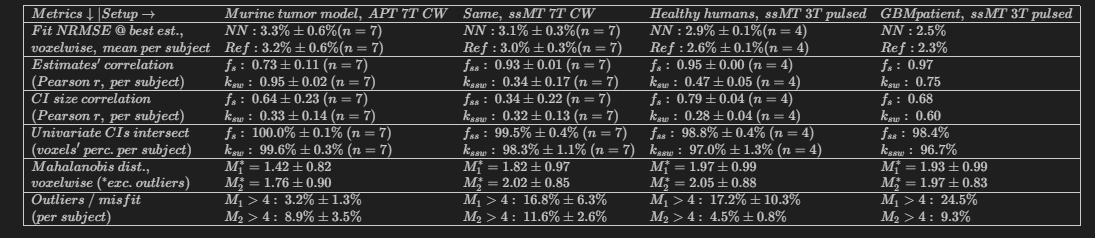

In [75]:
df

,Metrics \downarrow | Setup\rightarrow,"Healthy\ humans,\ ssMT\ 3T\ pulsed","GBM patient,\ ssMT\ 3T\ pulsed","AD patient,\ ssMT\ 3T\ pulsed","Murine\ tumor\ model,\ APT\ 7T\ CW","Same,\ ssMT\ 7T\ CW"
0,"Fit\ NRMSE\ @\ best\ est.,",NN: 2.9\%$\pm$0.1\% (n=4),NN: 2.4\%,NN: 3.1\%,NN: 3.3\%$\pm$0.7\% (n=7),NN: 3.0\%$\pm$0.3\% (n=7)
1,"voxelwise,\ mean\ per\ subject",Ref: 2.6\%$\pm$0.1\% (n=4),Ref: 2.2\%,Ref: 2.8\%,Ref: 3.2\%$\pm$0.6\% (n=7),Ref: 2.8\%$\pm$0.3\% (n=7)
2,Estimates'\ correlation,f$_{s}$:\ 0.95$\pm$0.00\ (n=4),f$_{s}$:\ 0.97,f$_{s}$:\ 0.98,f$_{s}$:\ 0.45$\pm$0.22\ (n=7),f$_{ss}$:\ 0.93$\pm$0.01\ (n=7)
3,"(Pearson\ r,\ per\ subject)",k$_{sw}$:\ 0.48$\pm$0.03\ (n=4),k$_{sw}$:\ 0.77,k$_{sw}$:\ 0.92,k$_{sw}$:\ 0.93$\pm$0.03\ (n=7),k$_{ssw}$:\ 0.38$\pm$0.14\ (n=7)
4,CI\ size\ correlation,f$_{s}$:\ 0.76$\pm$0.05\ (n=4),f$_{s}$:\ 0.65,f$_{s}$:\ 0.83,f$_{s}$:\ 0.68$\pm$0.17\ (n=7),f$_{ss}$:\ 0.30$\pm$0.22\ (n=7)
5,"(Pearson\ r,\ per\ subject)",k$_{sw}$:\ 0.28$\pm$0.07\ (n=4),k$_{sw}$:\ 0.64,k$_{sw}$:\ 0.61,k$_{sw}$:\ 0.34$\pm$0.18\ (n=7),k$_{ssw}$:\ 0.40$\pm$0.10\ (n=7)
6,Univariate\ CIs\ intersect,f$_{ss}$:\ 98.5\%$\pm$0.5\%\ (n=4),f$_{ss}$:\ 98.5\%,f$_{ss}$:\ 100.0\%,f$_{s}$:\ 99.9\%$\pm$0.1\%\ (n=7),f$_{ss}$:\ 99.4\%$\pm$0.5\%\ (n=7)
7,(voxels'\ perc.\ per\ subject),k$_{ssw}$:\ 97.1\%$\pm$1.0\%\ (n=4),k$_{ssw}$:\ 96.6\%,k$_{ssw}$:\ 99.9\%,k$_{sw}$:\ 99.5\%$\pm$0.4\%\ (n=7),k$_{ssw}$:\ 98.2\%$\pm$1.0\%\ (n=7)
8,"Mahalanobis\ dist.,\",M$_1$=2.53$\pm$0.61\ (n=4),M$_1$=2.69,M$_1$=2.82,M$_1$=1.41$\pm$0.13\ (n=7),M$_1$=2.16$\pm$0.40\ (n=7)
9,(voxels'\ median\ per\ subject),M$_2$=2.07$\pm$0.32\ (n=4),M$_2$=1.98,M$_2$=2.30,M$_2$=1.87$\pm$0.24\ (n=7),M$_2$=2.02$\pm$0.11\ (n=7)


## Phantom

In [76]:
phantom_UQ_stats = np.load(f'figs/phantom/intermediates/UQ_stats_allpoints.npz')        

f_best_dotprod_arr, k_best_dotprod_arr = zip(*phantom_UQ_stats['means_of_exact_posterior'])

In [ ]:
(phantom_f_perc_CIs_intersect, phantom_k_perc_CIs_intersect, f_perc_NN_CI_covers_exact, k_perc_NN_CI_covers_exact) = \
    au.analyze_CI_intersections(
        phantom_UQ_stats['f_est'], np.array(f_best_dotprod_arr), 
        phantom_UQ_stats['k_est'], np.array(k_best_dotprod_arr), 
        phantom_UQ_stats['cov_nnpred_scaled'], np.array(phantom_UQ_stats['covs_of_exact_posterior']), phantom_UQ_stats['good_xy_points'], 
        sli=0, is_mt=False, figsize=(10, 8), kmax=1200, df=0.005, dk=20, fmin=0.1, fmax=0.3 #, result_fig=None
    )

f_est_sli = phantom_UQ_stats['f_est'][:, 0, :]
k_est_sli = phantom_UQ_stats['k_est'][:, 0, :]
cov_nnpred_scaled_sli = phantom_UQ_stats['cov_nnpred_scaled'][:, 0, :]
f_est_nn_l = [f_est_sli[_x, _y] for (_x, _y) in phantom_UQ_stats['good_xy_points']]
k_est_nn_l = [k_est_sli[_x, _y] for (_x, _y) in phantom_UQ_stats['good_xy_points']]
cov_nnpred_scaled_l = [cov_nnpred_scaled_sli[_x, _y] for (_x, _y) in phantom_UQ_stats['good_xy_points']]

pears_f, pears_k, pears_f_ci, pears_k_ci = au.analyze_scatter(
    f_est_nn_l, f_best_dotprod_arr, k_est_nn_l, k_best_dotprod_arr, 
    cov_nnpred_scaled_l, np.array(phantom_UQ_stats['covs_of_exact_posterior']),
    is_mt=False, alpha=0.2, kmax=1200 #, to_plot=False
)

if take_typical_sample:
    phantom_mahas1_voxmed = phantom_mahas1 = np.median(phantom_UQ_stats['mahas1'].reshape(-1, 10), axis=1)
    phantom_mahas2_voxmed = phantom_mahas2 = np.median(phantom_UQ_stats['mahas2'].reshape(-1, 10), axis=1)
else:
    phantom_mahas1 = phantom_UQ_stats['mahas1']
    phantom_mahas2 = phantom_UQ_stats['mahas2']    
    
phantom_ok_mahas1_perc = 100*np.sum(phantom_mahas1 < maha_th)/len(phantom_mahas1)
phantom_ok_mahas2_perc = 100*np.sum(phantom_mahas2 < maha_th)/len(phantom_mahas2)

In [78]:
vial_labels = phantom_UQ_stats['vial_labels']
mean_nn_nrmse_byvial = np.mean([np.mean(phantom_UQ_stats['nn_posterior_min_nrmse_percs'][vial_labels==vl]) for vl in np.unique(vial_labels)])
mean_ref_nrmse_byvial = np.mean([np.mean(phantom_UQ_stats['exact_posterior_min_nrmse_percs'][vial_labels==vl]) for vl in np.unique(vial_labels)])
maha1_vial_medians = [np.median(phantom_mahas1_voxmed[vial_labels==vl]) for vl in np.unique(vial_labels)]
maha2_vial_medians = [np.median(phantom_mahas2_voxmed[vial_labels==vl]) for vl in np.unique(vial_labels)]
ok_mahas1_byvial = [100*np.sum(phantom_mahas1_voxmed[vial_labels==vl] < maha_th)/len(phantom_mahas1_voxmed[vial_labels==vl]) for vl in np.unique(vial_labels)]
ok_mahas2_byvial = [100*np.sum(phantom_mahas2_voxmed[vial_labels==vl] < maha_th)/len(phantom_mahas2_voxmed[vial_labels==vl]) for vl in np.unique(vial_labels)]

phantom_f_perc_CIs_intersect

100.0

In [ ]:
f_CIs_intersect_perc_byvial, k_CIs_intersect_perc_byvial = [], []

for vl in np.unique(vial_labels):
    (phantom_f_perc_CIs_intersect, phantom_k_perc_CIs_intersect, f_perc_NN_CI_covers_exact, k_perc_NN_CI_covers_exact) = \
        au.analyze_CI_intersections(
            phantom_UQ_stats['f_est'], np.array(f_best_dotprod_arr)[vial_labels==vl], 
            phantom_UQ_stats['k_est'], np.array(k_best_dotprod_arr)[vial_labels==vl], 
            phantom_UQ_stats['cov_nnpred_scaled'], 
            np.array(phantom_UQ_stats['covs_of_exact_posterior'][vial_labels==vl]),
            phantom_UQ_stats['good_xy_points'][vial_labels==vl], 
            sli=0, is_mt=False, figsize=(10, 8), kmax=1200, df=0.005, dk=20, fmin=0.1, fmax=0.3 #, result_fig=None
        )
    f_CIs_intersect_perc_byvial.append(phantom_f_perc_CIs_intersect)
    k_CIs_intersect_perc_byvial.append(phantom_k_perc_CIs_intersect)

In [80]:
#df

In [81]:
df_final = df.copy()
df_final

,Metrics \downarrow | Setup\rightarrow,"Healthy\ humans,\ ssMT\ 3T\ pulsed","GBM patient,\ ssMT\ 3T\ pulsed","AD patient,\ ssMT\ 3T\ pulsed","Murine\ tumor\ model,\ APT\ 7T\ CW","Same,\ ssMT\ 7T\ CW"
0,"Fit\ NRMSE\ @\ best\ est.,",NN: 2.9\%$\pm$0.1\% (n=4),NN: 2.4\%,NN: 3.1\%,NN: 3.3\%$\pm$0.7\% (n=7),NN: 3.0\%$\pm$0.3\% (n=7)
1,"voxelwise,\ mean\ per\ subject",Ref: 2.6\%$\pm$0.1\% (n=4),Ref: 2.2\%,Ref: 2.8\%,Ref: 3.2\%$\pm$0.6\% (n=7),Ref: 2.8\%$\pm$0.3\% (n=7)
2,Estimates'\ correlation,f$_{s}$:\ 0.95$\pm$0.00\ (n=4),f$_{s}$:\ 0.97,f$_{s}$:\ 0.98,f$_{s}$:\ 0.45$\pm$0.22\ (n=7),f$_{ss}$:\ 0.93$\pm$0.01\ (n=7)
3,"(Pearson\ r,\ per\ subject)",k$_{sw}$:\ 0.48$\pm$0.03\ (n=4),k$_{sw}$:\ 0.77,k$_{sw}$:\ 0.92,k$_{sw}$:\ 0.93$\pm$0.03\ (n=7),k$_{ssw}$:\ 0.38$\pm$0.14\ (n=7)
4,CI\ size\ correlation,f$_{s}$:\ 0.76$\pm$0.05\ (n=4),f$_{s}$:\ 0.65,f$_{s}$:\ 0.83,f$_{s}$:\ 0.68$\pm$0.17\ (n=7),f$_{ss}$:\ 0.30$\pm$0.22\ (n=7)
5,"(Pearson\ r,\ per\ subject)",k$_{sw}$:\ 0.28$\pm$0.07\ (n=4),k$_{sw}$:\ 0.64,k$_{sw}$:\ 0.61,k$_{sw}$:\ 0.34$\pm$0.18\ (n=7),k$_{ssw}$:\ 0.40$\pm$0.10\ (n=7)
6,Univariate\ CIs\ intersect,f$_{ss}$:\ 98.5\%$\pm$0.5\%\ (n=4),f$_{ss}$:\ 98.5\%,f$_{ss}$:\ 100.0\%,f$_{s}$:\ 99.9\%$\pm$0.1\%\ (n=7),f$_{ss}$:\ 99.4\%$\pm$0.5\%\ (n=7)
7,(voxels'\ perc.\ per\ subject),k$_{ssw}$:\ 97.1\%$\pm$1.0\%\ (n=4),k$_{ssw}$:\ 96.6\%,k$_{ssw}$:\ 99.9\%,k$_{sw}$:\ 99.5\%$\pm$0.4\%\ (n=7),k$_{ssw}$:\ 98.2\%$\pm$1.0\%\ (n=7)
8,"Mahalanobis\ dist.,\",M$_1$=2.53$\pm$0.61\ (n=4),M$_1$=2.69,M$_1$=2.82,M$_1$=1.41$\pm$0.13\ (n=7),M$_1$=2.16$\pm$0.40\ (n=7)
9,(voxels'\ median\ per\ subject),M$_2$=2.07$\pm$0.32\ (n=4),M$_2$=1.98,M$_2$=2.30,M$_2$=1.87$\pm$0.24\ (n=7),M$_2$=2.02$\pm$0.11\ (n=7)


In [82]:
# f'NN: {np.mean(phantom_UQ_stats['nn_posterior_min_nrmse_percs']):.1f}\\%' +\
#     ('$\\pm$'+f'{np.std(phantom_UQ_stats['nn_posterior_min_nrmse_percs']):.1f}\\% (n={len(phantom_UQ_stats['nn_posterior_min_nrmse_percs'])})' 
#      if mean_over_agg_voxels else ''),
phantom_KLdist_medians = [np.median(phantom_UQ_stats['KL(P1||P2)'][vial_labels==vl]) for vl in np.unique(vial_labels)]
phantom_JS_medians = [np.median(phantom_UQ_stats['Jensen-Shannon Divergence'][vial_labels==vl]) for vl in np.unique(vial_labels)]
phantom_Hell_medians = [np.median(phantom_UQ_stats['Hellinger Distance'][vial_labels==vl]) for vl in np.unique(vial_labels)]


In [83]:
df_final['L-arg. phantom,\\ 3ppm\\ 9.4T\\ CW'] = [ 
        # NRMSEs:
        #'', '',
        f'NN: {np.mean(mean_nn_nrmse_byvial):.1f}\\%'+'$\\pm$'+f'{np.std(mean_nn_nrmse_byvial):.1f}\\% ',
        f'Ref: {np.mean(mean_ref_nrmse_byvial):.1f}\\%'+'$\\pm$'+f'{np.std(mean_ref_nrmse_byvial):.1f}\\% ',
        # est correlation
        'f$_{s}$:\\ '+f'{pears_f:.2f}',
        'k$_{sw}$:\\ '+f'{pears_k:.2f}',
        # CI-size correlation
        'f$_{s}$:\\ '+f'{pears_f_ci:.2f}',
        'k$_{sw}$:\\ '+f'{pears_k_ci:.2f}',
        # CI intersect
        'f$_{s}$:\\ '+f'{np.mean(f_CIs_intersect_perc_byvial):.1f}\\%'+'$\\pm$'+f'{np.std(f_CIs_intersect_perc_byvial):.1f}\\%',
        'k$_{sw}$:\\ '+f'{np.mean(k_CIs_intersect_perc_byvial):.1f}\\%'+'$\\pm$'+f'{np.std(k_CIs_intersect_perc_byvial):.1f}\\%',
        # Mahalanobises
        f"M$_1$={np.nanmean(maha1_vial_medians):.2f}$\\pm${np.nanstd(maha1_vial_medians):.2f}", 
        f"M$_2$={np.nanmean(maha2_vial_medians):.2f}$\\pm${np.nanstd(maha2_vial_medians):.2f}", 
        f"$M_1>4$:\\ {100-np.mean(ok_mahas1_byvial):.1f}\\%$\\pm${np.std(ok_mahas1_byvial):.1f}\\% (n={len(ok_mahas1_byvial)})",
        f"$M_2>4$:\\ {100-np.mean(ok_mahas2_byvial):.1f}\\%$\\pm${np.std(ok_mahas2_byvial):.1f}\\% (n={len(ok_mahas2_byvial)})",
        f"KL:\\ {np.mean(phantom_KLdist_medians):.2f}$\\pm${np.std(phantom_KLdist_medians):.2f}", 
        f"JS:\\ {np.mean(phantom_JS_medians):.2f}$\\pm${np.std(phantom_JS_medians):.2f}",
        f"HL:\\ {np.mean(phantom_Hell_medians):.2f}$\\pm${np.std(phantom_Hell_medians):.2f}",
        ]

process_table(df_final, order=(0,3,4,1,2,5))

Metrics \downarrow | Setup\rightarrow
Healthy\ humans,\ ssMT\ 3T\ pulsed
GBM patient,\ ssMT\ 3T\ pulsed
AD patient,\ ssMT\ 3T\ pulsed
Murine\ tumor\ model,\ APT\ 7T\ CW
Same,\ ssMT\ 7T\ CW
L-arg. phantom,\ 3ppm\ 9.4T\ CW


<IPython.core.display.Latex object>

1


## Final Table (inc. human APT)

In [84]:
import pandas as pd
df_apt_human = pd.read_csv('/home/alexf/phiVAE/figs/healthy_apt/human_APT_summary.csv', index_col=0)
df_superfinal = pd.concat([df_final, df_apt_human], axis=1)
process_table(df_superfinal, order=(0,4,5,1,7,2,3,6)) # 0,3,4,1,6,2,5))

Metrics \downarrow | Setup\rightarrow
Healthy\ humans,\ ssMT\ 3T\ pulsed
GBM patient,\ ssMT\ 3T\ pulsed
AD patient,\ ssMT\ 3T\ pulsed
Murine\ tumor\ model,\ APT\ 7T\ CW
Same,\ ssMT\ 7T\ CW
L-arg. phantom,\ 3ppm\ 9.4T\ CW
Healthy\ Humans,\ APT\ 3T\ pulsed


<IPython.core.display.Latex object>

1


In [85]:
np.mean(np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 2), axis=1)

array([1.5, 3.5, 5.5, 7.5, 9.5])

### optional - simulation summary

In [86]:
def split_dict_of_lists_into_quarters(dict_of_lists):
    quarters = [{}, {}, {}, {}]    
    for key, value_list in dict_of_lists.items():
        print(f'Processing key: {key}')
        if key in ('f_est', 'k_est', 'cov_nnpred_scaled'):
            for i in range(4):
                quarters[i][key] = value_list 
            continue  # Skip these keys
        try:
            print(f'Processing list of length {len(value_list)}')
            quarter_size = len(value_list) // 4        
            for i in range(4):
                start_idx = i * quarter_size
                end_idx = (i + 1) * quarter_size if i < 3 else len(value_list)
                quarters[i][key] = value_list[start_idx:end_idx]    
        except Exception as e:
            print(f'Error processing key {key}: {e}')
            continue
    return quarters[0], quarters[1], quarters[2], quarters[3]

In [ ]:
import pandas as pd, numpy as np
from notebooks import nutils
from importlib import reload; reload(nutils)

sim_uq_metrics_data = dict(np.load('/home/alexf/phiVAE/figs/simulative/results_2026-06-01_14-17/intermediates/MT_UQ_stats_allpoints.npz', allow_pickle=True))

data_quarters = split_dict_of_lists_into_quarters(sim_uq_metrics_data)
simul_uqvsref_results_lists = [nutils.load_UQvsREF_results(x) for x in data_quarters]
simul_uqvsref_results = {k: [v[k] for v in simul_uqvsref_results_lists] for k in simul_uqvsref_results_lists[0].keys()}

df_sim = pd.DataFrame()
df_sim['MT simulated'] = [         
        f'NN: {np.mean(simul_uqvsref_results["nn_posterior_min_nrmse_percs"]):.1f}\\%'+'$\\pm$'+f'{np.std(simul_uqvsref_results["nn_posterior_min_nrmse_percs"]):.1f}\\% ',
        f'Ref: {np.mean(simul_uqvsref_results["exact_posterior_min_nrmse_percs"]):.1f}\\%'+'$\\pm$'+f'{np.std(simul_uqvsref_results["exact_posterior_min_nrmse_percs"]):.2f}\\% ',
        # # est correlation
        ' ',' ',
        # CI-size correlation
        ' ',' ',
        # # CI intersect
        'f$_{s}$:\\ '+f'{np.mean(simul_uqvsref_results["f_perc_CIs_intersect"]):.1f}\\%'+'$\\pm$'+f'{np.std(simul_uqvsref_results["f_perc_CIs_intersect"]):.1f}\\%',
        'k$_{sw}$:\\ '+f'{np.mean(simul_uqvsref_results["k_perc_CIs_intersect"]):.1f}\\%'+'$\\pm$'+f'{np.std(simul_uqvsref_results["k_perc_CIs_intersect"]):.1f}\\%',
        # Mahalanobises
        f"M$_1$={np.nanmean(simul_uqvsref_results['mahas1_typical']):.2f}$\\pm${np.nanstd(simul_uqvsref_results['mahas1_typical']):.2f}", 
        f"M$_2$={np.nanmean(simul_uqvsref_results['mahas2_typical']):.2f}$\\pm${np.nanstd(simul_uqvsref_results['mahas2_typical']):.2f}", 
        f"$M_1>4$:\\ {np.mean(simul_uqvsref_results['mahas1_percBAD']):.1f}\\%$\\pm${np.std(simul_uqvsref_results['mahas1_percBAD']):.1f}\\% (n={len(simul_uqvsref_results['mahas1_percBAD'])})",
        f"$M_2>4$:\\ {np.mean(simul_uqvsref_results['mahas2_percBAD']):.1f}\\%$\\pm${np.std(simul_uqvsref_results['mahas2_percBAD']):.1f}\\% (n={len(simul_uqvsref_results['mahas2_percBAD'])})",
        # Dist divergences
        f"KL:\\ {np.mean(simul_uqvsref_results['humanAPT_KLdist_median']):.2f}$\\pm${np.std(simul_uqvsref_results['humanAPT_KLdist_median']):.2f}", 
        f"JS:\\ {np.mean(simul_uqvsref_results['humanAPT_JS_median']):.2f}$\\pm${np.std(simul_uqvsref_results['humanAPT_JS_median']):.2f}",
        f"HL:\\ {np.mean(simul_uqvsref_results['humanAPT_Hell_median']):.2f}$\\pm${np.std(simul_uqvsref_results['humanAPT_Hell_median']):.2f}",
        ]

print(df_sim)

In [89]:
len(simul_uqvsref_results['raw_mahas1'][0])

1000

In [ ]:
df_superfinal = pd.concat([df_final, df_apt_human, df_sim], axis=1)
process_table(df_superfinal, order=(0,3,4,1,6,2,5,7))

# Figure compilation (Figs. 3,4,6)

In [91]:
def slap_label_on_container(container, label_text, loc=(-0.01, 1.05), color='black', fontsize=18):    
    ghost_ax = container.add_axes([0, 0, 1, 1], frameon=False)        
    ghost_ax.set_xticks([]); ghost_ax.set_yticks([])        
    ghost_ax.text(
        loc[0], loc[1], label_text, transform=ghost_ax.transAxes, 
        fontsize=fontsize, fontweight='bold', va='top', ha='left', 
        color=color
    )

## Mice (Fig. 3)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from core import config, data
config.Config.configure_mt_amide_preclinical()

def get_lims(data_xa):
    ''' Trim non-brain areas up to single line margin in each direction
    '''
    xmin = list(np.nansum(data_xa['roi_mask_nans'][:,0,:].to_numpy(), axis=1) > 0).index(True) - 1
    xmax = 1 - list(np.nansum(data_xa['roi_mask_nans'][:,0,:].to_numpy(), axis=1) > 0)[::-1].index(True)
    ymin = list(np.nansum(data_xa['roi_mask_nans'][:,0,:].to_numpy(), axis=0) > 0).index(True) - 1
    ymax = 1 - list(np.nansum(data_xa['roi_mask_nans'][:,0,:].to_numpy(), axis=0) > 0)[::-1].index(True)
    return xmin, xmax, ymin, ymax

def get_mask_centroid(mask):
    ''' Calculate centroid of a binary mask
    '''
    coords = np.argwhere(mask == 1)        
    return np.int32(coords.mean(axis=0))

def load_mouse_detail(mouse_name):
    ''' Load data feed and sample points for a given mouse
    '''
    data_xa = xr.open_dataset(f'data/{mouse_name}.nc' )
    
    xmin, xmax, ymin, ymax = get_lims(data_xa)
    data_xa_cutout = data_xa.isel(
        height=slice(xmin, xmax),
        width=slice(ymin, ymax) 
    )
    tumor_mask = data_xa_cutout['tumor_mask'].to_numpy().copy().squeeze()
    contralateral_mask = data_xa_cutout['contralateral_mask'].to_numpy().copy().squeeze()
    
    data_xa_cutout['B0_shift_ppm_map'] = (('height','slice','width'), np.zeros_like(data_xa_cutout['T1ms']))
    data_xa_cutout['B1_fix_factor_map'] = (('height','slice','width'), np.ones_like(data_xa_cutout['T1ms']))

    data_feed_mt = data.SlicesFeed.from_xarray(data_xa_cutout, seq_name='mt')
    data_feed_amide = data.SlicesFeed.from_xarray(data_xa_cutout, seq_name='amide')

    # Auto-create sample points as centroids
    points_tumor = [get_mask_centroid(tumor_mask)]
    points_contralateral = [get_mask_centroid(contralateral_mask)]

    return data_feed_mt, data_feed_amide, points_tumor, points_contralateral

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as patches

reload(au); reload(au.core); reload(au.metrics); reload(au.viz)

def plot_mouse_demo(mouse_name='ped_C1_1L_20241113_1245', fig=None, subfigs=None, letters=('a','b','c','d')):

    if fig is not None or subfigs is not None:
        assert fig is not None and subfigs is not None, "Either provide both fig and subfigs, or neither."
    else:
        fig = plt.figure(figsize=(14, 6), constrained_layout=True) # 16, 6           
        subfigs = fig.subfigures(2, 2, width_ratios=[3, 1.2], wspace=0.1, hspace=0.1)
    
    data_feed_mt, data_feed_amide, points_tumor, points_contralateral = load_mouse_detail(mouse_name)
    results_folder = f'figs/mice/{mouse_name}'
    
    mt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/mt_tissue_params_est.npz'))
    amide_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/amide_tissue_params_est.npz')) 
    shape = mt_tissue_params_est['fc_T'].shape
    
    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(mt_tissue_params_est, shape, is_cest=False)        
    axes = au.plot_CI_maps(
        f_est[:,0,:], f_sigma[:,0,:], 
        k_est[:,0,:], k_sigma[:,0,:],
        is_cest=False, vmax_k=70, vmax_f=30, 
        fig=subfigs[0][0], ktop=True, ticks_for_all_cbars=True, kwargs_plot_map={'pad': 0.25}
    )
    colors = ['white','gold']
    points = points_tumor + points_contralateral
    labels = [1]*len(points_tumor) + [0]*len(points_contralateral)
    for jj, (label, point) in enumerate(zip(labels, points)):
        square = patches.Rectangle((point[1]-.6, point[0]-.6), 1.5, 1.5, facecolor='none', edgecolor=colors[label], linewidth=2.5)
        axes[1, 1].add_patch(square)
        axes[1, 1].text(point[1]-(3 if label else -3), point[0]+1, ['A', 'B'][jj], color=colors[label], fontsize=15, ha='center')    
    if False: # mark RoIs
        axes[1, 1].contour(mt_tissue_params_est['tumor_mask'].astype(float), levels=[0.5], colors='orange', linewidths=1.5)
        axes[1, 1].contour(mt_tissue_params_est['contralateral_mask'].astype(float), levels=[0.5], colors='b', linewidths=1.5)
    slap_label_on_container(subfigs[0][0], f'({letters[0]})', (0.05, 1.05))
    
    ax, atips = au.juxtapose_two_voxels_posteriors(
        data_feed_mt, mt_tissue_params_est, shape, 
        points_tumor[0], points_contralateral[0], fig=subfigs[0][1]
        # sli=0, is_cest=False, data_feed_cest=None, seq_name=None, 
    )
    slap_label_on_container(subfigs[0][1], f'({letters[1]})', (0.03, 1.05))

    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(amide_tissue_params_est, shape, is_cest=True)        
    axes = au.plot_CI_maps(
        f_est[:,0,:], f_sigma[:,0,:], 
        k_est[:,0,:], k_sigma[:,0,:],
        is_cest=True, vmax_k=700, vmax_f=0.6, 
        fig=subfigs[1][0], ktop=True, ticks_for_all_cbars=True, kwargs_plot_map={'pad': 0.3}
    )
    for jj, (label, point) in enumerate(zip(labels, points)):
        square = patches.Rectangle((point[1]-.6, point[0]-.6), 1.5, 1.5, facecolor='none', edgecolor=colors[label], linewidth=2.5)
        axes[1, 1].add_patch(square)
        axes[1, 1].text(point[1]-(3 if label else -3), point[0]+1, ['A', 'B'][jj], color=colors[label], fontsize=15, ha='center')        
    slap_label_on_container(subfigs[1][0], f'({letters[2]})', (0.05, 1.05))

    ax, atips = au.juxtapose_two_voxels_posteriors(
        data_feed_mt, amide_tissue_params_est, shape, 
        points_tumor[0], points_contralateral[0], fig=subfigs[1][1],
        is_cest=True, data_feed_cest=data_feed_amide, max_k_cest=700,
    )    
    slap_label_on_container(subfigs[1][1], f'({letters[3]})', (0.03, 1.05))    
    return fig

plot_mouse_demo()

if False:    
    with PdfPages('figs/mice/fig2_all_mice.pdf') as pdf:
        for mouse_name in mice_MT_UQ_stats.keys():
            fig = plot_mouse_demo(mouse_name)
            pdf.savefig(fig) 
            plt.close(fig) 

### Multiple mice on same plot

In [156]:
#5, 6, 1, 4
mice_of_choice = [list(mice_MT_UQ_stats.keys())[mi] for mi in (4,5,0,3)]
mice_of_choice

['ped_Control_2R_2025-01-09',
 'ped_Control_1L1R_2025-01-09',
 'ozohar_two_ears_20240404_091158',
 'ped_C1_1L_20241113_1245']

### FINAL FIGURE (Fig. 3)

  0%|                                                                                                                                                                              | 0/1 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.72it/s]


nrmse_95_th 0.030673973016243482 cdf95 0.9502512708604625


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.79it/s]


nrmse_95_th 0.029269464122339398 cdf95 0.9531239292026467


...

nrmse_95_th 0.016827214710216053 cdf95 0.9384070102233357


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.58it/s]


nrmse_95_th 0.017510701451534914 cdf95 0.9494512035618763


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.66it/s]


nrmse_95_th 0.014324792200162277 cdf95 0.9514695091202157


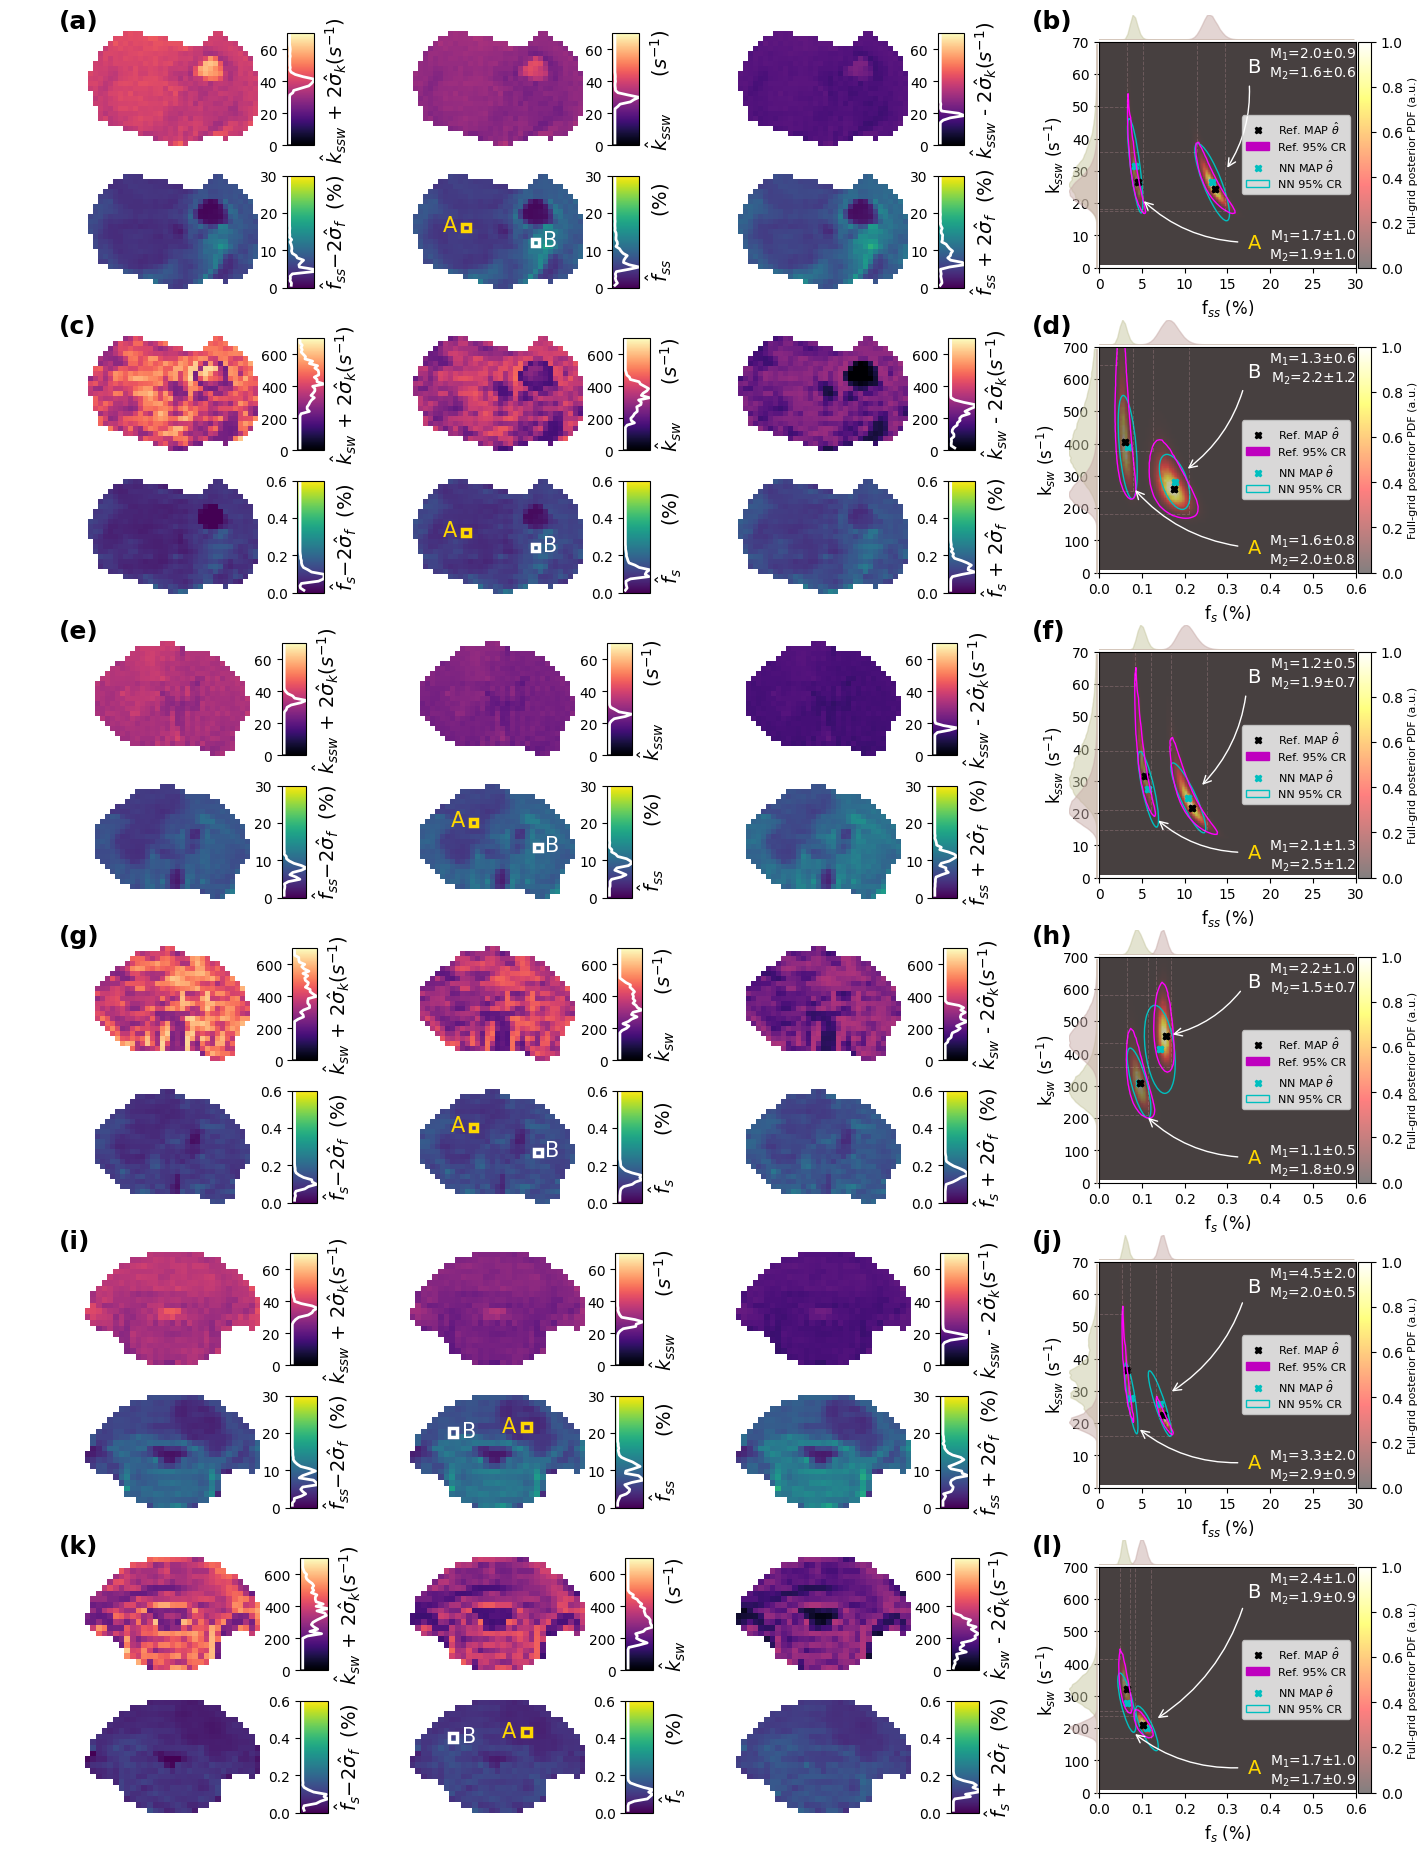

In [157]:
reload(au.viz)

config.Config.configure_mt_amide_preclinical()

fig = plt.figure(figsize=(14, 6*3), constrained_layout=True) # 16*2, 6*2    
subfigs = fig.subfigures(6, 2, width_ratios=[3, 1.2], wspace=0.05, hspace=0.1)

for pi, mouse_name in enumerate(mice_of_choice[:3]):
    letters1 = [f'a{pi+1}', f'b{pi+1}', f'c{pi+1}', f'd{pi+1}']
    letters2 = [chr(ord(let)+4*pi) for let in ('a','b','c','d')]
    letters3 = [['a','b','c','d'], ['e','f','g','h'], ['i','j','k','l'], ['m','n','o','p']][pi]
    plot_mouse_demo(
        mouse_name=mouse_name, fig=fig, 
        subfigs=subfigs[pi*2:(pi*2+2), :], 
        letters=letters3
    ) #
    
plt.savefig('figs/mice/three_mice_combined.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/mice/three_mice_combined_LOWRES.png', dpi=100, bbox_inches='tight')

## Human


In [70]:
from scipy import ndimage
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as patches


def find_interior_point(mask):
    """
    Given a binary mask, find an x,y point that's inside
    (removed at least 2 hops from pixels having zero mask value).
    """
    mask = np.copy(mask)
    mask[np.isnan(mask)] = 0  # treat NaNs as outside mask
        
    # Distance transform: each pixel gets distance to nearest 0 in mask
    dist = ndimage.distance_transform_edt(mask>0.8)
    
    # Find points at least 2 pixels away from boundary
    interior = dist >= 2
    
    if not np.any(interior):
        
        # Fallback: find point with maximum distance
        max_dist_idx = np.unravel_index(np.argmax(dist), dist.shape)
        
        plt.figure()
        plt.imshow(mask.astype(int), cmap='gray'); plt.colorbar()
        plt.show()
        
        plt.figure()
        plt.imshow(dist, cmap='gray'); plt.colorbar()
        plt.show()
        
        assert 0, "No interior point found in mask!"
        return max_dist_idx
    
    # Get coordinates of interior points
    interior_coords = np.argwhere(interior)
    
    # Return the point with maximum distance (most interior)
    max_dist_in_interior = dist[interior].max()
    interior_point = np.argwhere(dist == max_dist_in_interior)[0]
    
    return tuple(interior_point)

In [ ]:
config.Config.configure_AMIDE_clinical_whole_brain()
data.SlicesFeed.norm_type = 'l2'
# consistency with human net training
reload(au); au.au_config.mt_sim_mode = 'isar2_c' 
human_vol_sli = -30

def load_vol_detail(vol_name):
    ''' Load data feed and sample points for a given volunteer
    '''
    data_xa = xr.open_dataset(f'data/{vol_name}.nc' )
    
    gray_mask = data_xa['gray_mask'].to_numpy().copy()[:, human_vol_sli, :]
    white_mask = data_xa['white_mask'].to_numpy().copy()[:, human_vol_sli, :]

    data_feed_mt = data.SlicesFeed.from_xarray(data_xa, seq_name='mt')

    # Auto-create sample points as centroids
    points_grey = [find_interior_point(gray_mask)]
    points_white = [find_interior_point(white_mask)]

    return data_feed_mt, points_grey, points_white


def plot_human_demo(
        res_folder_name='vol8_w_net_trained_on_vol7-9-10', 
        vol_name=None, sli=human_vol_sli,
        fig=None, subfigs=None, letters=('a','b'), do_legend=False,
        is_cest=False
    ):
    vol_name = vol_name or res_folder_name.split('_w_')[0]
    results_folder = f'figs/humans/{res_folder_name}' 
    
    if fig is not None or subfigs is not None:
        assert fig is not None and subfigs is not None, "Either provide both fig and subfigs, or neither."
    else:                
        fig = plt.figure(figsize=(11, 4), constrained_layout=True) #constrained_layout=True) tight_layout=True)        
        subfigs = fig.subfigures(1, 2, width_ratios=[3, 1.7], wspace=0.05, hspace=0.1)
    
    data_feed_mt, points_grey, points_white = load_vol_detail(vol_name)
        
    tissue_params_est = mt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/mt_tissue_params_est.npz'))    
    shape = mt_tissue_params_est['fc_T'].shape
    if is_cest:
        tissue_params_est = amide_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/amide_tissue_params_est.npz'))
        
    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(tissue_params_est, shape, is_cest=is_cest)        

    cr = 5
    axes = au.plot_CI_maps(
        f_est[cr:-cr, sli, cr:-cr], f_sigma[cr:-cr, sli, cr:-cr], 
        k_est[cr:-cr, sli, cr:-cr], k_sigma[cr:-cr, sli, cr:-cr],
        is_cest=is_cest, vmax_k=70 if not is_cest else 500, vmax_f=30 if not is_cest else 1.0,
        fig=subfigs[0], ktop=True, ticks_for_all_cbars=True 
    )
    colors = ['blue','gold']
    points = points_grey + points_white
    labels = [1]*len(points_grey) + [0]*len(points_white)
    for jj, (label, point) in enumerate(zip(labels, points)):
        square = patches.Rectangle((point[1]-.6-cr, point[0]-.6-cr), 4.5, 4.5, facecolor='none', edgecolor=colors[label], linewidth=2.5)
        axes[1, 1].add_patch(square)
        axes[1, 1].text(point[1]-(3 if label else -3)-cr, point[0]+1-cr, ['A', 'B'][jj], color=colors[label], fontsize=15, ha='center')    

    slap_label_on_container(subfigs[0], f'({letters[0]})', (0.03, 1.02))

    ax, atips = au.juxtapose_two_voxels_posteriors(
        data_feed_mt, mt_tissue_params_est, shape, 
        points_grey[0], points_white[0], fig=subfigs[1],
        sli=sli, do_legend=do_legend, #is_cest=False, data_feed_cest=None, seq_name=None, 
    )
    for atip, letter, color in zip(atips, ['A', 'B'], colors[::-1]):
        ax.text(atip[0]+1.5, 23, letter, fontweight='bold', color=color, fontsize=15, ha='left', va='center')
    slap_label_on_container(subfigs[1], f'({letters[1]})', (0.03, 1.02))
    return fig

if False:    
    with PdfPages('figs/humans/fig2_all_humans.pdf') as pdf:
        for setup_name in list(human_MT_UQ_stats.keys()):
            print(setup_name)
            fig = plot_human_demo(setup_name)
            pdf.savefig(fig) 
            plt.close(fig) 
else: # demo mode - single
    plot_human_demo()
    #plot_human_demo(res_folder_name='erlangen', vol_name=)
    

In [72]:
human_MT_UQ_stats.keys()

dict_keys(['vol8_w_net_trained_on_vol7-9-10_2026-05-28_h00-m33', 'vol7_w_net_trained_on_vol8-9-10_2026-05-27_h22-m08', 'vol10_w_net_trained_on_vol7-8-9_2026-05-28_h05-m14', 'vol9_w_net_trained_on_vol7-8-10_2026-05-28_h02-m52'])

In [73]:
if False:
    fig = plt.figure(figsize=(11*2, 4*2), constrained_layout=True) #constrained_layout=True) tight_layout=True)                
    subfigs = fig.subfigures(1*2, 2*2, width_ratios=[3, 1.7, 3, 1.7], wspace=0.05, hspace=0.1)

    for pi, setup_name in enumerate(list(human_MT_UQ_stats.keys())):
        plot_human_demo(
            setup_name, fig=fig, 
            subfigs=subfigs[(pi//2), 2*(pi%2):2*(pi%2+1)], 
            #letters=[f'a{pi+1}', f'b{pi+1}'].
            letters=[chr(ord('a')+2*pi), chr(ord('b')+2*pi)], do_legend=(pi==1)
        )
        
    plt.savefig('figs/humans/fig3_all_vols_combined.png', dpi=300, bbox_inches='tight')
    plt.savefig('figs/humans/fig3_all_vols_combined_LOWRES.png', dpi=100, bbox_inches='tight')

In [162]:
from helpers import utils
reload(utils)

# For horizontal arrangement see before 2026-Jan06
def plot4volnrmse(fig=None):
    fig = fig or plt.figure(figsize=(3, 5)) #4.5, 3))


## Revised Human w. CEST (Fig. 4)



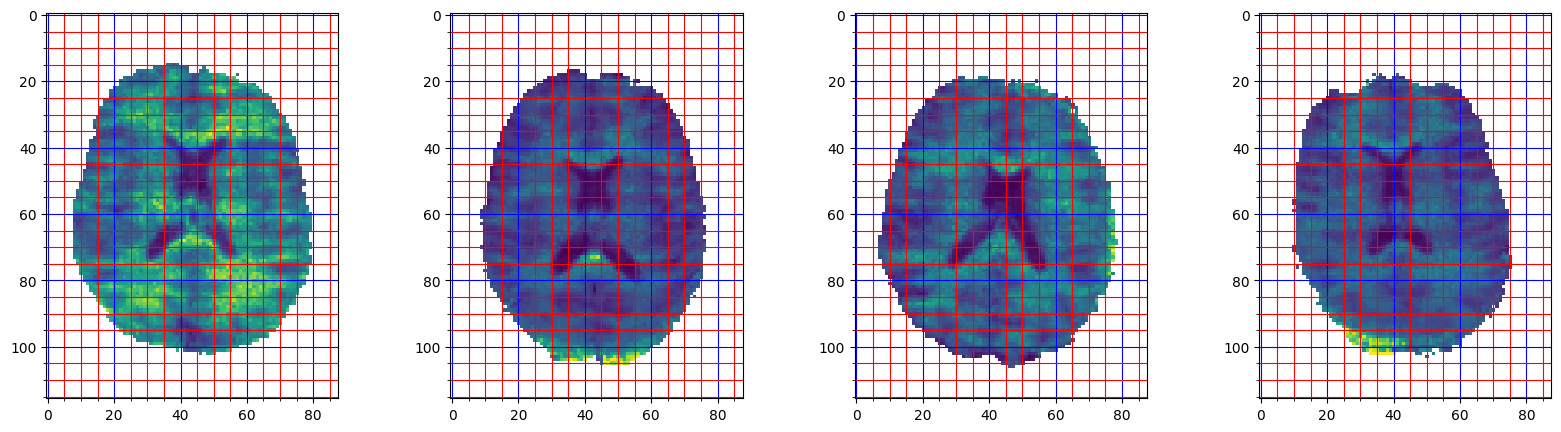

In [74]:
from matplotlib.ticker import AutoMinorLocator
from notebooks import nutils

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, vol in zip(axes, ['vol7', 'vol8', 'vol9', 'vol10']):
    vol_data_feed_mt, points_grey, points_white = nutils.load_vol_detail(vol, seq_name='mt', human_vol_sli=20)
    ax.imshow(vol_data_feed_mt.R1a_V[:,20,:])
    # Add tightly spaced minor gridlines
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.grid(which='minor', color='red')#, linestyle=':', linewidth=1, alpha=0.7)
    ax.grid(which='major', color='blue')#, linestyle='-', linewidth=0.6, alpha=0.9)
CSFpoints = {'vol7': [(45, 45)], 'vol8': [(50, 45)], 'vol9': [(52, 47)], 'vol10': [(50, 40)]}

In [76]:
np.array([1,2,3,4])[[2,2,0]]

array([3, 3, 1])

### FINAL FIGURE (Fig. 4 vols.1-2 + vols3-4 supplementary)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 25.89it/s]


/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.39s/it]


nrmse_95_th 0.0292509698601052 cdf95 0.9520164729004981


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.33s/it]


nrmse_95_th 0.030119004063022353 cdf95 0.9513610181815533


...

nrmse_95_th 0.020516719253850943 cdf95 0.9524379710878023


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.06s/it]


nrmse_95_th 0.038199722082239505 cdf95 0.9509849192698498


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.13it/s]


nrmse_95_th 0.017348177350746865 cdf95 0.9477651771011613


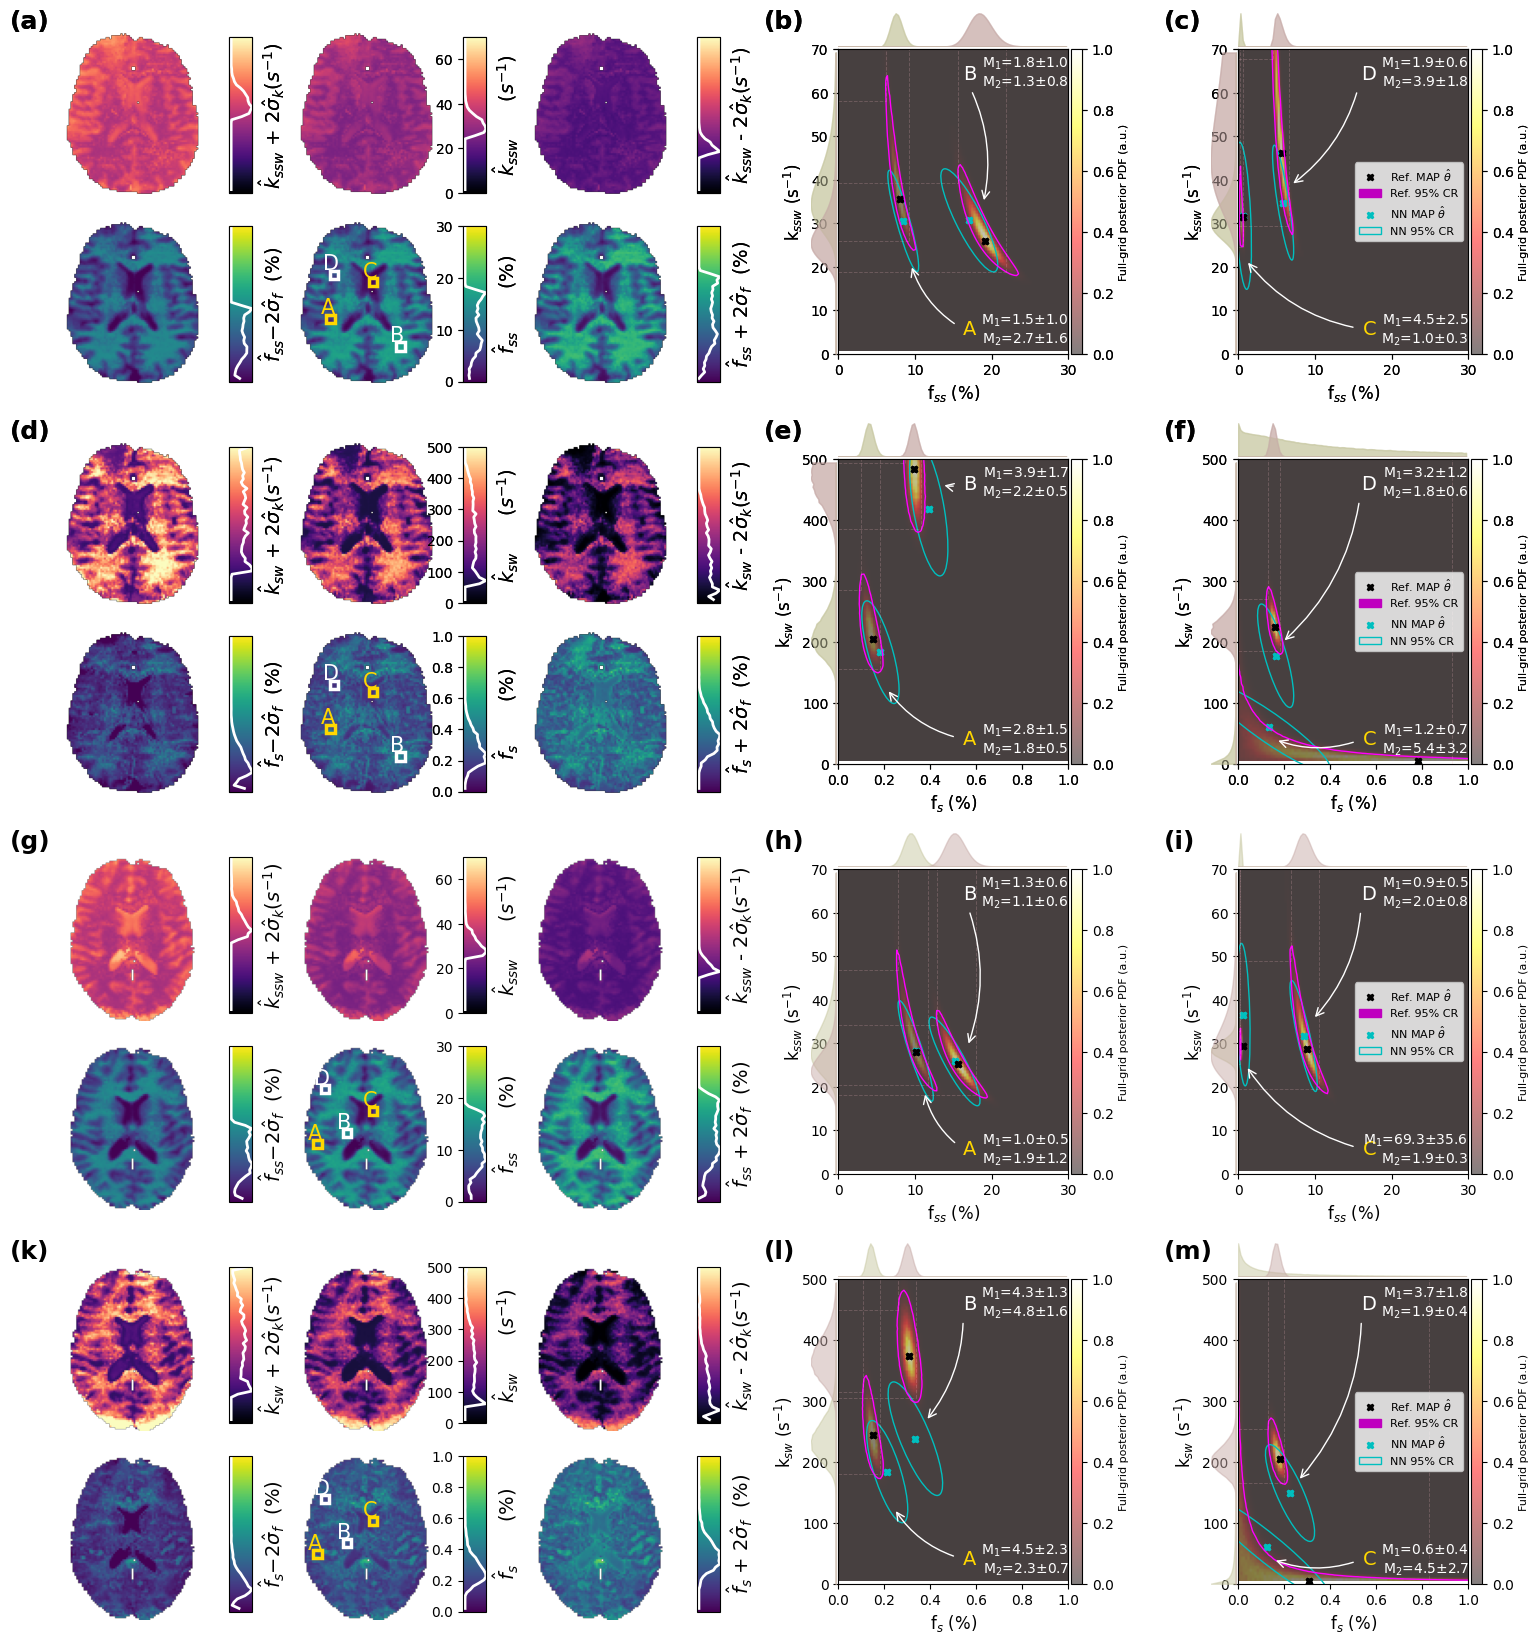

In [82]:
reload(au); reload(au.viz); reload(nutils)

figure = plt.figure(figsize=(15, 16), constrained_layout=True)
subfigs = figure.subfigures(4, 1, hspace=0.1)
    
vol_sli=20
trainfolders = ['vol8-9-10_2026-04-28_h20-m57', 'vol7-9-10_2026-04-28_h22-m45', 'vol7-8-10_2026-04-30_h14-m34', 'vol7-8-9_2026-04-29_h00-m35']
trainfolders = [f'/home/alexf/phiVAE/ckpts/healthy/{folder}' for folder in trainfolders]

def plot_human_mt_cest(_trainfolders, vols, subfigs):
    for jj, (trainfolder, testvolname) in enumerate(zip(_trainfolders, vols)):
        try:        
            ckpts2use = [f'{trainfolder}/{seqname}' for seqname in ['mt', 'cest']]
            vol_data_feed_mt, points_grey, points_white = nutils.load_vol_detail(testvolname, seq_name='mt', human_vol_sli=20)
            vol_data_feed_amide, _, _ = nutils.load_vol_detail(testvolname, seq_name='amide', human_vol_sli=20)

            mt_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ckpts2use[0], brain2test_mt=vol_data_feed_mt)
            amide_tissue_params_est, _ellipse_d = nutils.infer_ckpt(
                ckpt_folder_mt=ckpts2use[0], brain2test_mt=vol_data_feed_mt, 
                is_cest=True, ckpt_folder_cest=ckpts2use[1], brain2test_cest=vol_data_feed_amide)

            points_ABCD = [points_grey[0], points_white[0], CSFpoints[testvolname][0], points_grey[1]] # points_white[1]]
            
            nutils.patient_subfigure(
                data_feed_mt=vol_data_feed_mt, tissue_params_est=mt_tissue_params_est, points_ABCD=points_ABCD, colors=['gold','white'],
                is_cest=False, annotate_cross_mahas=True, sli=vol_sli, drop_first=False, fig=subfigs[jj*2], letters='abcdefghiklmnopqrstuvwxyz'[jj*2*3: jj*2*3+3], cropy1=12, cropx=2
            )         
            nutils.patient_subfigure(
                data_feed_mt=vol_data_feed_mt, data_feed_cest=vol_data_feed_amide, tissue_params_est=amide_tissue_params_est, points_ABCD=points_ABCD, colors=['gold','white'],
                is_cest=True, annotate_cross_mahas=True, sli=vol_sli, drop_first=False, fig=subfigs[jj*2+1], letters='abcdefghiklmnopqrstuvwxyz'[jj*2*3+3: jj*2*3+6], cropy1=12, cropx=2
            ) 
        except Exception as e:
            import traceback; traceback.print_exc();
            print(f"Error processing {trainfolder} / {testvolname}: {e}")

plot_human_mt_cest(trainfolders[:1], ['vol7'], subfigs)   
plot_human_mt_cest(trainfolders[:2], ['vol7', 'vol8'], subfigs)   
plt.savefig('figs/humans/vol78_mtcest.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/humans/vol78_mtcest_LOWRES.png', dpi=100, bbox_inches='tight')


/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
 67%|████████████████████████████████████████████████████████████████████████████████                                        | 6/9 [00:00<00:00, 27.83it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 26.75it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.85s/it]


nrmse_95_th 0.02716735078018173 cdf95 0.9483551950326488


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.40s/it]


nrmse_95_th 0.02720366479937922 cdf95 0.9473011065298842


...

nrmse_95_th 0.025881843195903885 cdf95 0.9540031312782394


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.16it/s]


nrmse_95_th 0.05577334544450484 cdf95 0.9472296501583424


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.19it/s]


nrmse_95_th 0.024077749909189646 cdf95 0.9471451618053337


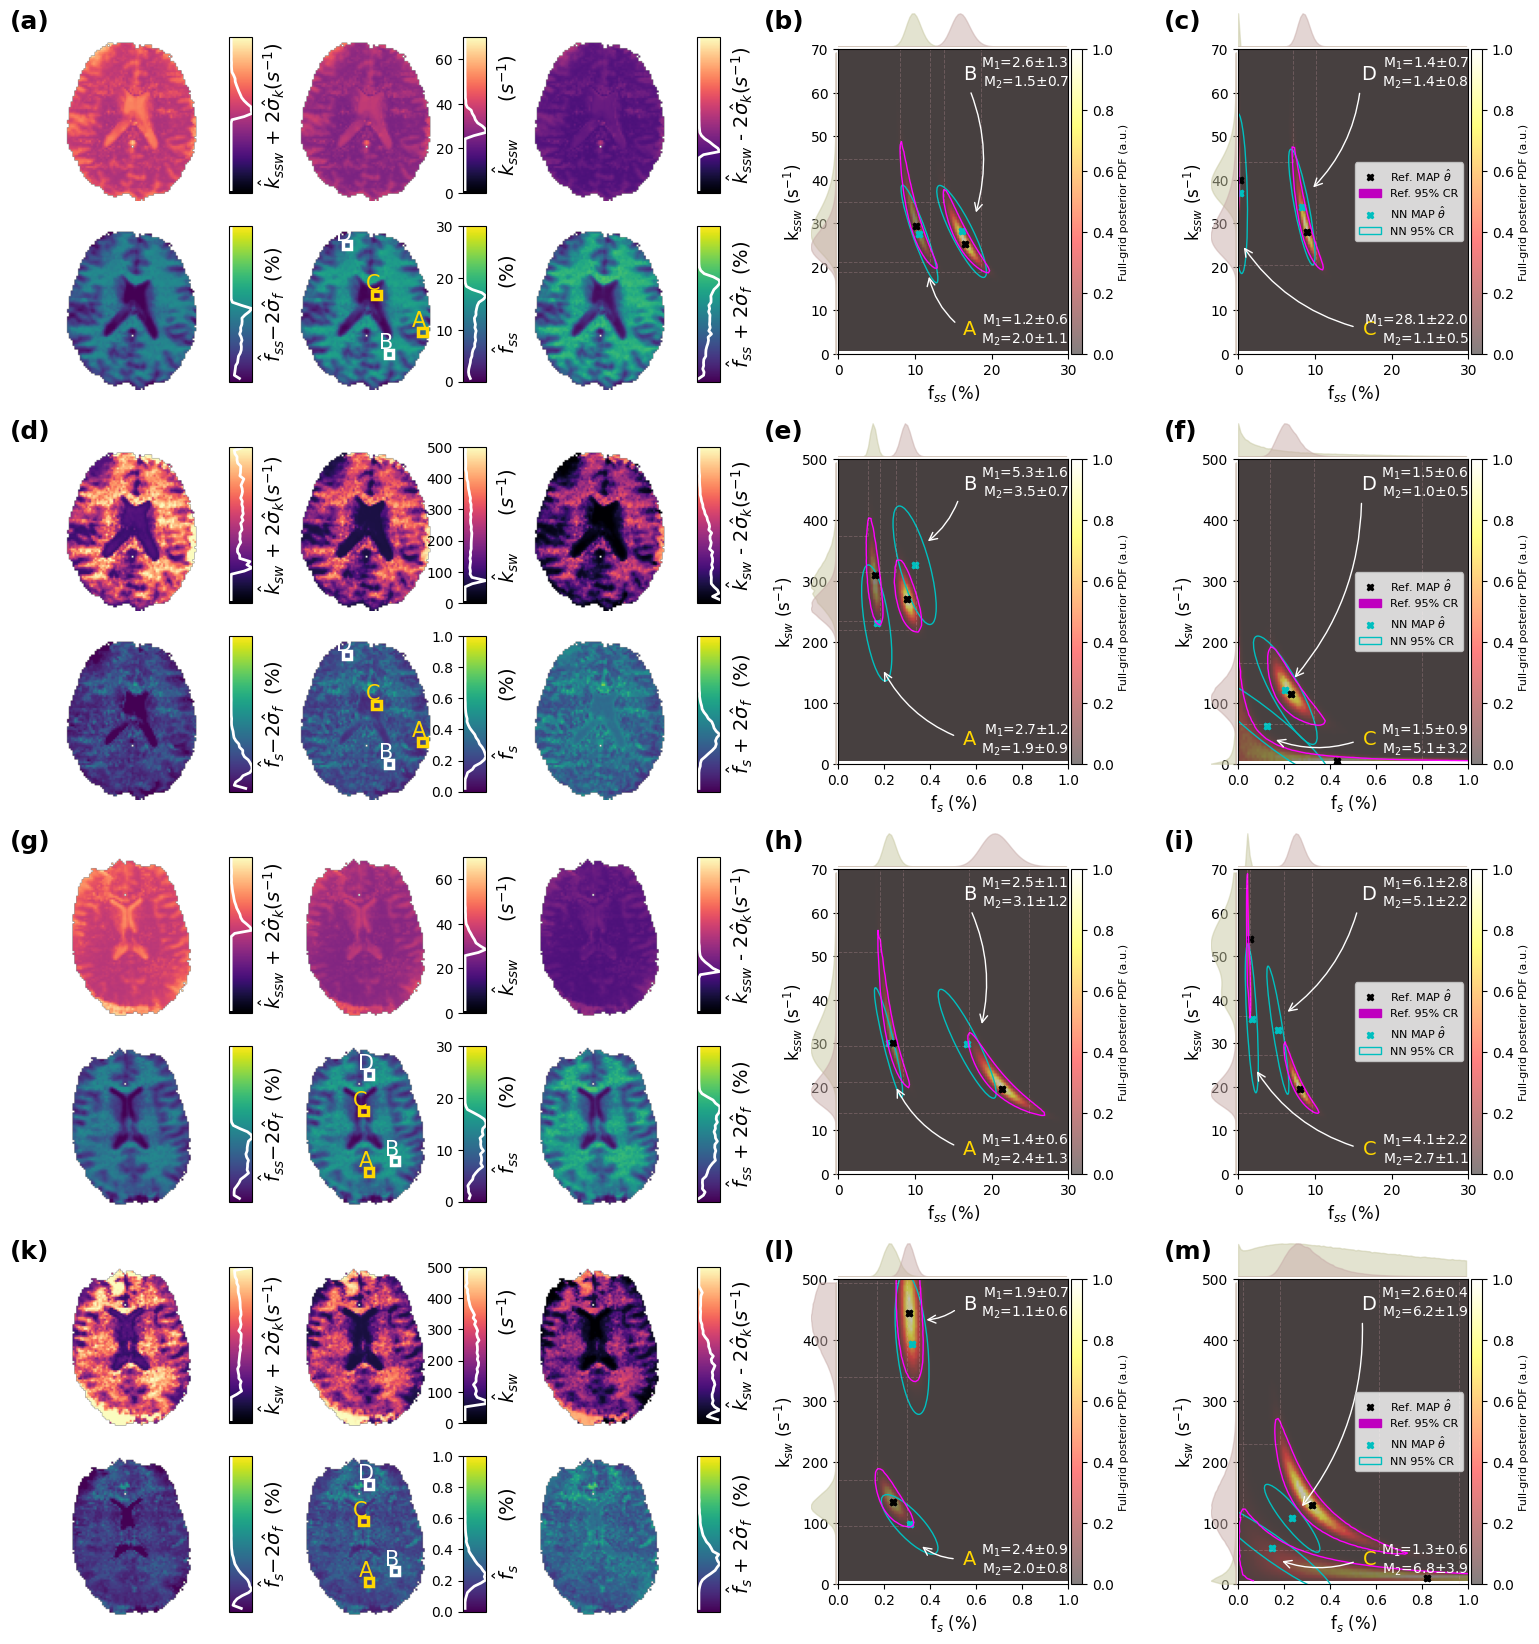

In [83]:
figure = plt.figure(figsize=(15, 16), constrained_layout=True)
subfigs = figure.subfigures(4, 1, hspace=0.1)

plot_human_mt_cest(trainfolders[2:4], ['vol9', 'vol10'], subfigs)
plt.savefig('figs/humans/vol910_mtcest.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/humans/vol910_mtcest_LOWRES.png', dpi=100, bbox_inches='tight')

## Overall performance stats

<!-- 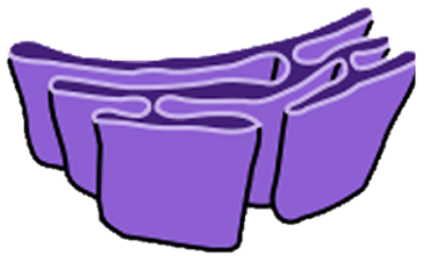
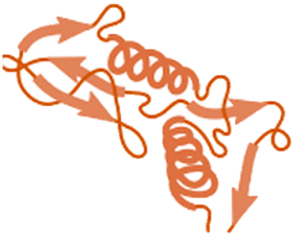 -->

In [8]:

config.Config.configure_AMIDE_clinical_whole_brain()
data.SlicesFeed.norm_type = 'l2'
# consistency with human net training
reload(au); au.au_config.mt_sim_mode = 'isar2_c' 

In [9]:
from PIL import Image
from helpers import utils
reload(utils)
reload(au); reload(au.viz); reload(au.metrics)

fig = plt.figure(figsize=(18, 6), constrained_layout=True) #constrained_layout=True) tight_layout=True)                
# Two rows; each row defines its own width ratios
leftfig, rightfig = fig.subfigures(1, 2, wspace=0.05, width_ratios=[4, 1])
row_subfigs = leftfig.subfigures(2, 1, hspace=0.1)
top_row = row_subfigs[0].subfigures(1, 4,    width_ratios=[1, 1, 1, 1], wspace=0.05)


<Figure size 1800x600 with 0 Axes>

In [72]:
# vols4fig 
# from helpers import loaders

['mahas1', 'mahas2', 'CR_areas', 'nnCR_areas', 'good_xy_points', 'timings', 'train_time', 'f_est', 'k_est', 'cov_nnpred_scaled', 'covs_of_exact_posterior', 'modes_of_exact_posterior', 'means_of_exact_posterior', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'KL(P1||P2)', 'KL(P2||P1)', 'Jensen-Shannon Divergence', 'Hellinger Distance', 'Bhattacharyya Distance', 'cdf_at_gt']
['mt_nn_pred_signal_normed_np', 'cov', 'ucov', 'scov', 'kb_T', 'fb_T', 'kc_T', 'fc_T', 'R1a_T', 'R2a_T', 'R2b_T', 'R2c_T']
['mahas1', 'mahas2', 'CR_areas', 'nnCR_areas', 'good_xy_points', 'timings', 'train_time', 'f_est', 'k_est', 'cov_nnpred_scaled', 'covs_of_exact_posterior', 'modes_of_exact_posterior', 'means_of_exact_posterior', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'KL(P1||P2)', 'KL(P2||P1)', 'Jensen-Shannon Divergence', 'Hellinger Distance', 'Bhattacharyya Distance', 'cdf_at_gt']
['mt_nn_pred_signal_normed_np', 'cov', 'ucov', 'scov', 'kb_T', 'fb_T', 'kc_T', 'fc_

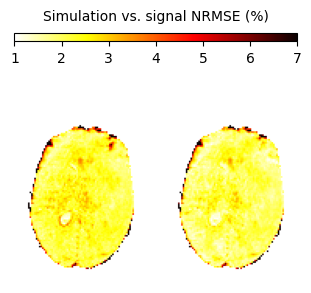

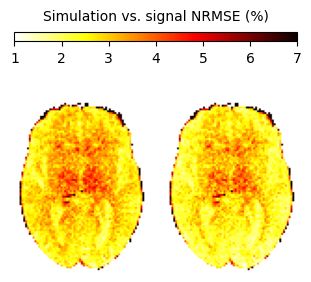

In [109]:
patient_MT_UQ_stats = np.load(f'{GBM_patient_res_folder}/intermediates/MT_UQ_stats_allpoints.npz')  

def plot_nrmse_map(
        result_folder, fig=None, axes=None, ax_cbar=None, 
        tissue_params_est_npzs_by_vol=None, sli=27, is_amide=False, patient_name='erlangen', trans=True, crop=1,
        at_nn_str='PS-VAE MAP', at_ref_str='Ref. MAP', nrmse_cbar_label='Simulation vs. signal NRMSE (%)'
        ):
    fig = fig or plt.figure(figsize=(3, 3), constrained_layout=True) #constrained_layout=True) tight_layout=True)
    
    uq_stats = np.load(f'{result_folder}/intermediates/{"APT" if is_amide else "MT"}_UQ_stats_allpoints.npz')
    tissue_params_est = np.load(f'{result_folder}/intermediates/{"amide" if is_amide else "mt"}_tissue_params_est.npz')
    
    if axes is None: 
        gs = fig.add_gridspec(2, 2, height_ratios=[0.15, 4])#, hspace=0.3, wspace=0.3)    
        axes = np.zeros( (2,), dtype=object)    
        for j in range(2):
            axes[j] = fig.add_subplot(gs[1, j])    
        ax_cbar = fig.add_subplot(gs[0, :])

    # -- vols load --
    # -- patients load --
        
    print(list(uq_stats.keys())) #), [v.shape](uq_stats.values()))
    print(list(tissue_params_est.keys()))
    abs_min_nrmse_perc_map = np.zeros(tissue_params_est['fc_T'].shape[::2]) # nrmse.shape)
    nn_nrmse_perc_map = np.zeros(tissue_params_est['fc_T'].shape[::2])
    
    for (_x, _y), nrmse_abs_min_perc, nn_nrmse_perc in zip(uq_stats['good_xy_points'], uq_stats['exact_posterior_min_nrmse_percs'], uq_stats['nn_posterior_min_nrmse_percs']): # vol_stats['modes_of_exact_posterior']):
        abs_min_nrmse_perc_map[_x, _y] = nrmse_abs_min_perc
        nn_nrmse_perc_map[_x, _y] = nn_nrmse_perc
        
    axes[0].imshow(nn_nrmse_perc_map[crop:-crop, crop:-crop].T if trans else nn_nrmse_perc_map[crop:-crop, crop:-crop], vmin=1, vmax=7, cmap='hot_r');
    axes[1].imshow(abs_min_nrmse_perc_map[crop:-crop, crop:-crop].T if trans else abs_min_nrmse_perc_map[crop:-crop, crop:-crop], vmin=1, vmax=7, cmap='hot_r');                
    if ax_cbar is not None:
        cbar = plt.colorbar(mappable=axes[1].images[0], cax=ax_cbar, orientation='horizontal') # ax=axes[0, jj]) 
        cbar.set_label(nrmse_cbar_label, labelpad=-40) # 'NRMSE (%)'

    for ax in axes.flatten():
        utils.remove_spines(ax, axisoff=False)
        
plot_nrmse_map(GBM_patient_res_folder, trans=False, crop=1)
plot_nrmse_map(AD_patient_res_folder, sli=3, patient_name='ichilov_alz', trans=False, crop=10)


['mahas1', 'mahas2', 'CR_areas', 'nnCR_areas', 'good_xy_points', 'f_est', 'k_est', 'cov_nnpred_scaled', 'covs_of_exact_posterior', 'modes_of_exact_posterior', 'means_of_exact_posterior', 'timings', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'KL(P1||P2)', 'KL(P2||P1)', 'Jensen-Shannon Divergence', 'Hellinger Distance', 'Bhattacharyya Distance', 'cdf_at_gt']
['APT_nn_pred_signal_normed_np', 'tumor_mask', 'contralateral_mask', 'cov', 'ucov', 'scov', 'kb_T', 'fb_T', 'kc_T', 'fc_T', 'R1a_T', 'R2a_T', 'R2b_T', 'R2c_T']
['mahas1', 'mahas2', 'CR_areas', 'nnCR_areas', 'good_xy_points', 'f_est', 'k_est', 'cov_nnpred_scaled', 'covs_of_exact_posterior', 'modes_of_exact_posterior', 'means_of_exact_posterior', 'timings', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'KL(P1||P2)', 'KL(P2||P1)', 'Jensen-Shannon Divergence', 'Hellinger Distance', 'Bhattacharyya Distance', 'cdf_at_gt']
['APT_nn_pred_signal_normed_np', 'tumor_mask', 'contralateral_mask', 'cov'

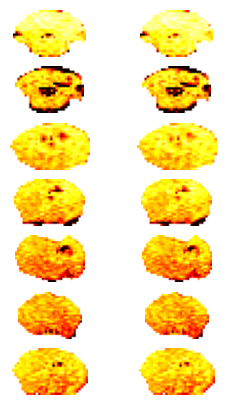

In [110]:
fig, axes = plt.subplots(7, 2, figsize=(3, 5))
for jj, mice_folder in enumerate(mice_folders):
    plot_nrmse_map(mice_folder, sli=0, fig=fig, axes=axes[jj, :], trans=False, is_amide=True)

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: xlabel='PS-VAE MAP'>, <Axes: xlabel='Ref. MAP'>]],
      dtype=object)

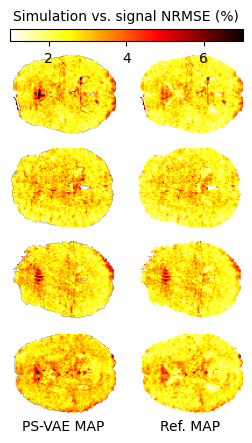

In [111]:
from helpers import utils; reload(utils)
from notebooks import nutils; reload(nutils)

# For horizontal arrangement see before 2026-Jan06
def plot4volnrmse(human_UQ_stats, fig=None, tissue_params_est_npzs_by_vol=None, human_vol_sli=-30, is_amide=False,
                   at_nn_str='PS-VAE MAP', at_ref_str='Ref. MAP', nrmse_cbar_label='Simulation vs. signal NRMSE (%)'):
    vol_names = [uq_stats_key.split('_w_')[0] for uq_stats_key in human_UQ_stats.keys()]
    uq_stats_key_by_vol = {uq_stats_key.split('_w_')[0]: uq_stats_key for uq_stats_key in human_UQ_stats.keys()}
    tissue_params_est_npzs_by_vol = tissue_params_est_npzs_by_vol or {
        vol_name: f'{vols4fig}/{uq_stats_key_by_vol[vol_name]}/intermediates/mt_tissue_params_est.npz'             
        for vol_name in vol_names
        }    
    fig = fig or plt.figure(figsize=(3, 5)) #4.5, 3))
    gs = fig.add_gridspec(5, 2, height_ratios=[0.15, 1, 1, 1, 1])#, hspace=0.3, wspace=0.3)    
    axes = np.zeros((4, 2), dtype=object)
    for i in range(4):
        for j in range(2):
            axes[i, j] = fig.add_subplot(gs[i+1, j])    
    ax_cbar = fig.add_subplot(gs[0, :])
    axes[3,0].set_xlabel(at_nn_str) #, color='black')
    axes[3,1].set_xlabel(at_ref_str) #, color='black')
    #for jj, (vol_name, tissue_params_est_npz, uq_stats_key) in enumerate(zip(vol_names, tissue_params_est_npzs, human_UQ_stats.keys())): # human_MT_UQ_stats.keys()):
    #for jj, (tissue_params_est_npz, uq_stats_key) in enumerate(zip( tissue_params_est_npzs, human_UQ_stats.keys())): # human_MT_UQ_stats.keys()):
    for jj, vol_name in enumerate(vol_names): # human_MT_UQ_stats.keys()):
        uq_stats_key = uq_stats_key_by_vol[vol_name]
        tissue_params_est = dict(np.load(tissue_params_est_npzs_by_vol[vol_name], allow_pickle=True))  
        data_feed, _, __ = nutils.load_vol_detail(vol_name, seq_name='amide' if is_amide else 'mt', human_vol_sli=human_vol_sli)
        
        _key = 'nn_pred_sim_signal_amide' if is_amide else 'mt_nn_pred_signal_normed_np'
        simulated = tissue_params_est[_key][:, :, human_vol_sli, :]    
        measured = data_feed.measured_normed_T[:, :, human_vol_sli, :]
        simulated /= np.linalg.norm(simulated, axis=0)
        measured /= np.linalg.norm(measured, axis=0) # just to be sure
        nrmse = np.linalg.norm(simulated - measured, axis=0)
        axes[jj, 0].imshow(100*nrmse[15:-10, 10:-10].T, vmin=1, vmax=7, cmap='hot_r');
        if jj==3:
            cbar = plt.colorbar(mappable=axes[jj, 0].images[0], cax=ax_cbar, orientation='horizontal') # ax=axes[0, jj]) 
            cbar.set_label(nrmse_cbar_label, labelpad=-40)
        vol_stats = human_UQ_stats[uq_stats_key]
        abs_min_nrmse_map = np.zeros(data_feed.shape[0::2])
        for (_x, _y), nrmse_abs_min_perc in zip(vol_stats['good_xy_points'], vol_stats['exact_posterior_min_nrmse_percs']): # vol_stats['modes_of_exact_posterior']):
            abs_min_nrmse_map[_x, _y] = nrmse_abs_min_perc
        axes[jj, 1].imshow(abs_min_nrmse_map[15:-10, 10:-10].T, vmin=1, vmax=7, cmap='hot_r');                
        
    for ax in axes.flatten():
        utils.remove_spines(ax, axisoff=False)
        #axes[0, jj].axis('off') # removes ylabels as well
        
    return axes

plot4volnrmse(human_MT_UQ_stats)

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: xlabel='PS-VAE MAP'>, <Axes: xlabel='Ref. MAP'>]],
      dtype=object)

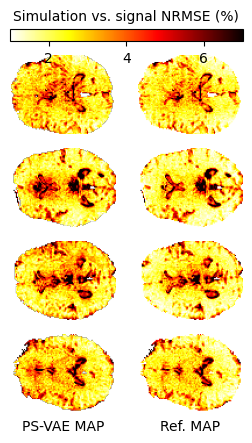

In [112]:

plot4volnrmse(human_APT_UQ_stats, fig=None, tissue_params_est_npzs_by_vol=tissue_params_est_npzs_by_vol, is_amide=True )

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >],
       [<Axes: xlabel='PS-VAE MAP'>, <Axes: xlabel='Ref. MAP'>]],
      dtype=object)

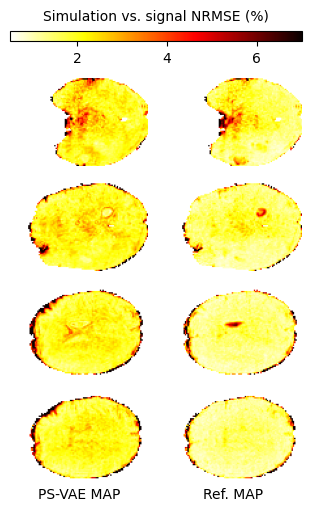

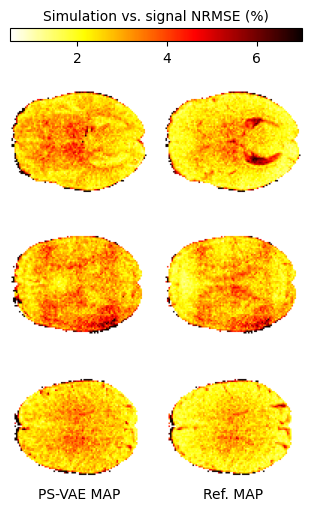

In [113]:
def plot3slicenrmse(err_nn, err_ref, fig=None, slis=[15,20,25], crop=10,
                    at_nn_str='PS-VAE MAP', at_ref_str='Ref. MAP', nrmse_cbar_label='Simulation vs. signal NRMSE (%)'
                    ):
    fig = fig or plt.figure(figsize=(3,5), constrained_layout=True) #4.5, 3))   
    gs = fig.add_gridspec(len(slis)+1, 2, height_ratios=[0.1]+[1]*len(slis), hspace=0.003, wspace=0.003) 
    axes = np.zeros((len(slis), 2), dtype=object)
    for i in range(len(slis)):
        for j in range(2):
            axes[i, j] = fig.add_subplot(gs[i+1, j])    
    ax_cbar = fig.add_subplot(gs[0, :])
    axes[len(slis)-1, 0].set_xlabel(at_nn_str) #, color='black')
    axes[len(slis)-1, 1].set_xlabel(at_ref_str) #, color='black')
    
    for jj, sli in enumerate(slis): # human_MT_UQ_stats.keys()):    
        axes[jj, 0].imshow(100*err_nn[crop:-crop, sli, crop:-crop].T, vmin=0.5, vmax=7, cmap='hot_r', aspect='equal');
        if jj==len(slis)-1:
            cbar = plt.colorbar(mappable=axes[jj, 0].images[0], cax=ax_cbar, orientation='horizontal') # ax=axes[0, jj]) 
            cbar.set_label(nrmse_cbar_label, labelpad=-40)
        axes[jj, 1].imshow(100*err_ref[crop:-crop, sli, crop:-crop].T, vmin=0.5, vmax=7, cmap='hot_r', aspect='equal');                
    for ax in axes.flatten():
        utils.remove_spines(ax, axisoff=False)        
        
    return axes

patients_nrmse_nnvsdict = np.load('figs/patients/nrmse_nn_vs_dict.npz')
plot3slicenrmse(patients_nrmse_nnvsdict['nn_err_erl'], patients_nrmse_nnvsdict['dict_err_erl'], fig=None, slis=[12, 25, 38,40], crop=10)
plot3slicenrmse(patients_nrmse_nnvsdict['nn_err_alz'], patients_nrmse_nnvsdict['dict_err_alz'], fig=None, slis=[3, 6, 9], crop=10)


## FINAL FIGURE - stats (Fig. 6)

/tmp/ipykernel_1763304/671180647.py:44: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.4)


['mahas1', 'mahas2', 'CR_areas', 'nnCR_areas', 'good_xy_points', 'timings', 'train_time', 'f_est', 'k_est', 'cov_nnpred_scaled', 'covs_of_exact_posterior', 'modes_of_exact_posterior', 'means_of_exact_posterior', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'KL(P1||P2)', 'KL(P2||P1)', 'Jensen-Shannon Divergence', 'Hellinger Distance', 'Bhattacharyya Distance', 'cdf_at_gt']
['MT_nn_pred_signal_normed_np', 'tumor_mask', 'contralateral_mask', 'cov', 'ucov', 'scov', 'kb_T', 'fb_T', 'kc_T', 'fc_T', 'R1a_T', 'R2a_T', 'R2b_T', 'R2c_T']
['mahas1', 'mahas2', 'CR_areas', 'nnCR_areas', 'good_xy_points', 'timings', 'train_time', 'f_est', 'k_est', 'cov_nnpred_scaled', 'covs_of_exact_posterior', 'modes_of_exact_posterior', 'means_of_exact_posterior', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'KL(P1||P2)', 'KL(P2||P1)', 'Jensen-Shannon Divergence', 'Hellinger Distance', 'Bhattacharyya Distance', 'cdf_at_gt']
['MT_nn_pred_signal_normed_np', 'tumor_mask', '

/home/alexf/phiVAE/analyze_uncertainty/metrics.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{x:.0f}%" for x in plt.gca().get_yticks() * 100])
/home/alexf/phiVAE/analyze_uncertainty/metrics.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{x:.0f}%" for x in plt.gca().get_yticks() * 100])
/home/alexf/phiVAE/analyze_uncertainty/metrics.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{x:.0f}%" for x in plt.gca().get_yticks() * 100])
/home/alexf/phiVAE/analyze_uncertainty/metrics.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabe

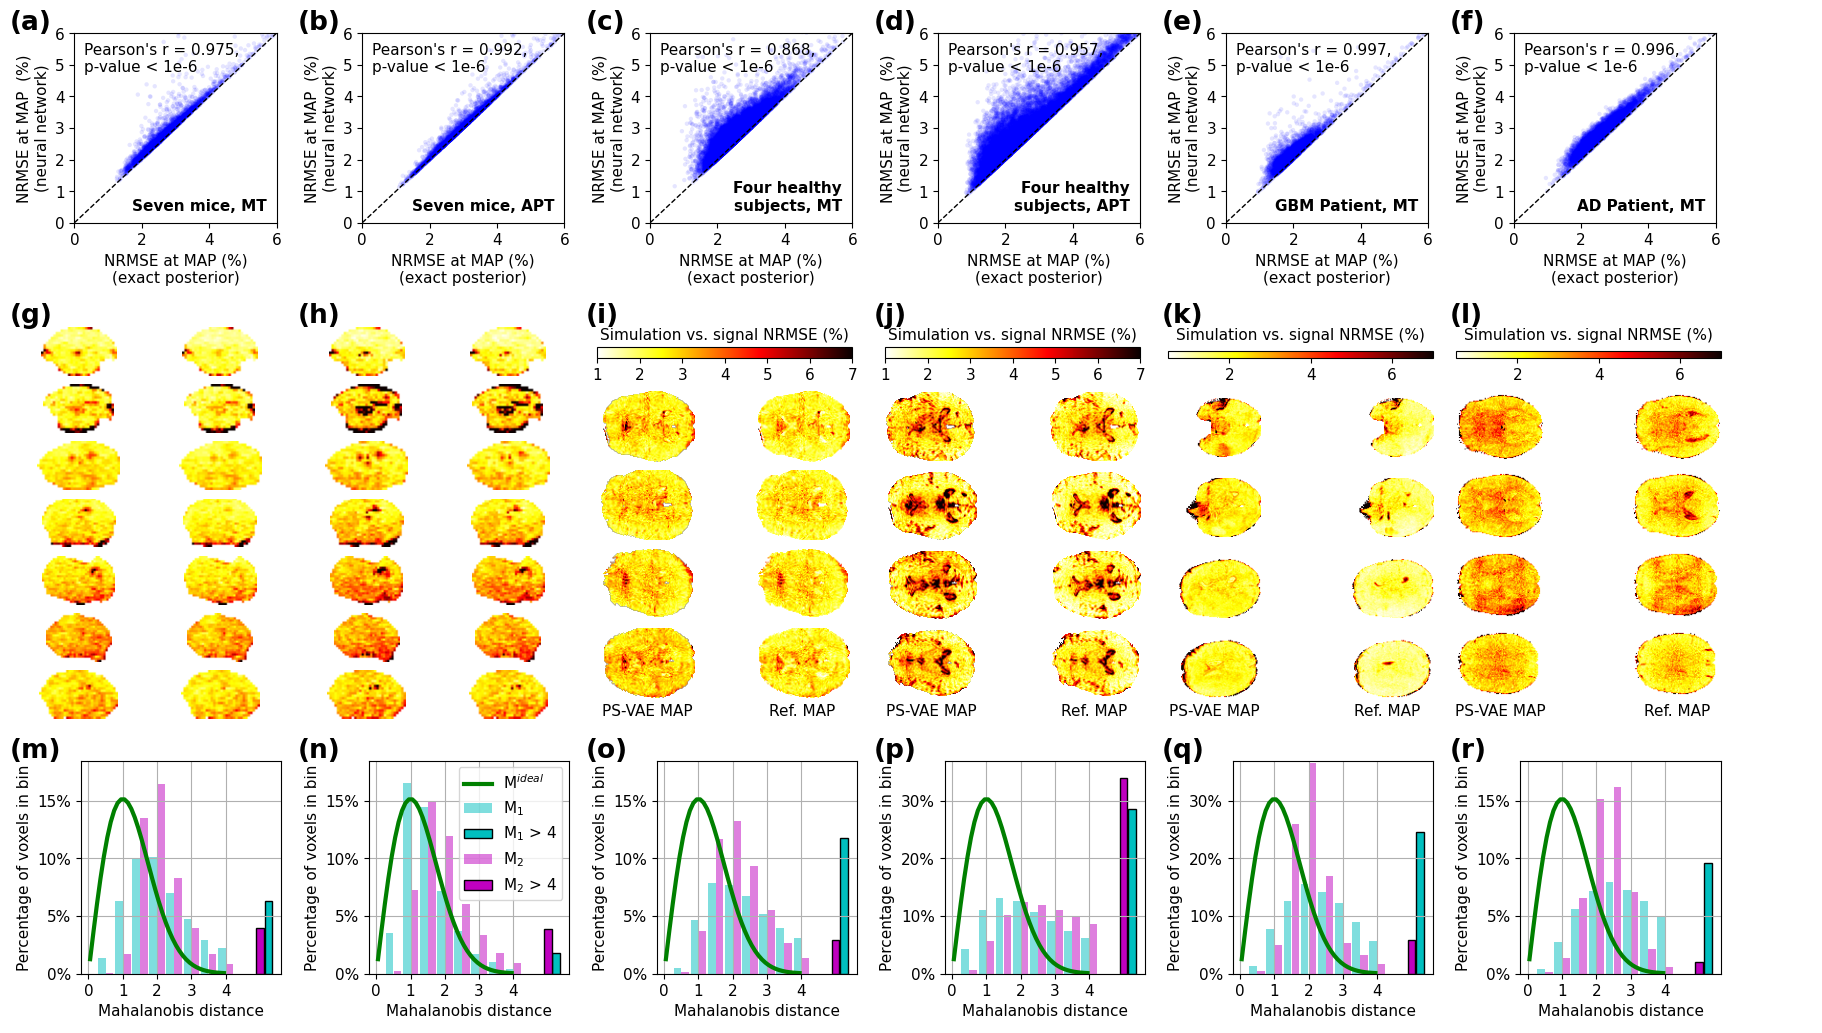

In [118]:
reload(au.metrics)
reload(au)

fig = plt.figure(figsize=(18, 10), constrained_layout=True) #constrained_layout=True) tight_layout=True)                
# Two rows; each row defines its own width ratios
leftfig, rightfig = fig.subfigures(1, 2, wspace=0.05, width_ratios=[4, 0.1])
row_subfigs = leftfig.subfigures(3, 1, height_ratios=(1,1.5,1), hspace=0.1)
top_row = row_subfigs[0].subfigures(1, 6,    wspace=0.05)
mid_row = row_subfigs[1].subfigures(1, 6, wspace=0.05) 
bottom_row = row_subfigs[2].subfigures(1, 6, wspace=0.05) 
subfigs = np.array([top_row, bottom_row])

axes=plot_nrmse_scatter(mt_agg=AGG_mice_MT_res, fig=subfigs[0,0], mt_apt_or_both='MT', draw_title=False)
axes[0].text(0.95, 0.05, 'Seven mice, MT', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
axes=plot_nrmse_scatter( apt_agg=AGG_mice_APT_res, fig=subfigs[0,1], mt_apt_or_both='APT', draw_title=False)
axes[0].text(0.95, 0.05, 'Seven mice, APT', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
slap_label_on_container(subfigs[0,0], "(a)")
slap_label_on_container(subfigs[0,1], "(b)")

sfig = subfigs[0,2]
axes=plot_nrmse_scatter(mt_agg=AGG_human_MT_res, fig=sfig, mt_apt_or_both='MT', draw_title=False)
axes[0].text(0.95, 0.05, 'Four healthy\nsubjects, MT', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
slap_label_on_container(sfig, "(c)")

sfig = subfigs[0,3]
axes=plot_nrmse_scatter(apt_agg=AGG_human_APT_res, fig=sfig, mt_apt_or_both='APT', draw_title=False)
axes[0].text(0.95, 0.05, 'Four healthy\nsubjects, APT', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
slap_label_on_container(sfig, "(d)")

sfig = subfigs[0,4]
axes=plot_nrmse_scatter(mt_agg=GBM_patient_MT_UQ_stats, fig=sfig, mt_apt_or_both='MT', draw_title=False)
axes[0].text(0.95, 0.05, 'GBM Patient, MT', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
slap_label_on_container(sfig, "(e)")

sfig = subfigs[0,5]
axes=plot_nrmse_scatter(mt_agg=ADpatient_MT_UQ_stats, fig=sfig, mt_apt_or_both='MT', draw_title=False)
axes[0].text(0.95, 0.05, 'AD Patient, MT', transform=axes[0].transAxes, fontsize=10, fontweight='bold', va='bottom', ha='right')
slap_label_on_container(sfig, "(f)")

# -------------------
if False:
    sfig = rightfig
    plot4volnrmse(human_MT_UQ_stats, fig=sfig) # subfigs[0, 3])
    slap_label_on_container(sfig, "(f)", loc=(-0.01, 1.025))
    
sfig = mid_row[0]
axes = sfig.subplots(7, 2)
for jj, mice_folder in enumerate(mice_folders):
    plot_nrmse_map(mice_folder, sli=0, fig=sfig, axes=axes[jj, :], trans=False)
sfig = mid_row[1]
axes = sfig.subplots(7, 2)
for jj, mice_folder in enumerate(mice_folders):
    plot_nrmse_map(mice_folder, sli=0, fig=sfig, axes=axes[jj, :], trans=False, is_amide=True)

plot4volnrmse(human_MT_UQ_stats, fig=mid_row[2]) # subfigs[0, 3])
plot4volnrmse(human_APT_UQ_stats, fig=mid_row[3], tissue_params_est_npzs_by_vol=tissue_params_est_npzs_by_vol, is_amide=True )

plot3slicenrmse(patients_nrmse_nnvsdict['nn_err_erl'], patients_nrmse_nnvsdict['dict_err_erl'], fig=mid_row[4], slis=[8, 18, 28, 38], crop=10)
plot3slicenrmse(patients_nrmse_nnvsdict['nn_err_alz'], patients_nrmse_nnvsdict['dict_err_alz'], fig=mid_row[5], slis=[2, 4, 6, 8], crop=10)

# -------------------

for letter, _sfig in zip('ghijkl', mid_row):
    slap_label_on_container(_sfig, f"({letter})")
for letter, _sfig in zip('mnopqr', subfigs[1, :]):
    slap_label_on_container(_sfig, f"({letter})", loc=(-0.01, 1.07))

sfig = subfigs[1, 0]
au.summarize_mahas(maha_lists['all_mahas1_mt'], maha_lists['all_mahas2_mt'], th=maha_th, fig=sfig, do_legend=False); plt.ylim(0, 0.37)
sfig = subfigs[1, 1]
au.summarize_mahas(maha_lists['all_mahas1_apt'], maha_lists['all_mahas2_apt'], th=maha_th, fig=sfig, do_legend=True); plt.ylim(0, 0.37)
sfig = subfigs[1, 2]
au.summarize_mahas(AGG_human_MT_res['mahas1'], AGG_human_MT_res['mahas2'], th=maha_th, fig=sfig, do_legend=False); plt.ylim(0, 0.37)
sfig = subfigs[1, 3]
au.summarize_mahas(AGG_human_APT_res['mahas1'], AGG_human_APT_res['mahas2'], th=maha_th, fig=sfig, do_legend=False); plt.ylim(0, 0.37)
sfig = subfigs[1, 4]
au.summarize_mahas(patient_MT_UQ_stats['mahas1'], patient_MT_UQ_stats['mahas2'], th=maha_th, fig=sfig, do_legend=False); plt.ylim(0, 0.37)
sfig = subfigs[1, 5]
au.summarize_mahas(ADpatient_MT_UQ_stats['mahas1'], ADpatient_MT_UQ_stats['mahas2'], th=maha_th, fig=sfig, do_legend=False); plt.ylim(0, 0.37)

from helpers import utils; reload(utils)
utils.increment_all_fonts(fig, 1)

plt.savefig('figs/all_stats_combined.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/all_stats_combined_LOWRES.png', dpi=100, bbox_inches='tight')

In [115]:
AGG_human_MT_res.keys()

dict_keys(['means_of_exact_posterior', 'covs_of_exact_posterior', 'timings', 'exact_posterior_min_nrmse_percs', 'nn_posterior_min_nrmse_percs', 'mahas1', 'mahas2', 'f_est', 'k_est', 'cov_nnpred_scaled'])

# Application (Fig. 8)

## UQ vs. RoI-var

In [ ]:
from importlib import reload
import os, numpy as np, matplotlib.pyplot as plt

import analyze_uncertainty as au; reload(au)
from core import config
config.Config.configure_mt_amide_preclinical()

mice_MT_UQ_stats = {}
mice_APT_UQ_stats = {} 

for x in os.listdir('figs/mice/'):
    if not 'BAD' in x and os.path.isdir(f'figs/mice/{x}'): #x.startswith('vol'):
        print(x)
        try:
            mice_MT_UQ_stats[x] = np.load(f'figs/mice/{x}/intermediates/MT_UQ_stats_allpoints.npz')    
        except Exception as e:
            print(e)
        try:
            mice_APT_UQ_stats[x] = np.load(f'figs/mice/{x}/intermediates/APT_UQ_stats_allpoints.npz')    
        except Exception as e:
            print(e)

ozohar_two_ears_20240404_091158
ozohar_right_20240404_125156
C4_None_20_alex
[Errno 2] No such file or directory: 'figs/mice/C4_None_20_alex/intermediates/MT_UQ_stats_allpoints.npz'
[Errno 2] No such file or directory: 'figs/mice/C4_None_20_alex/intermediates/APT_UQ_stats_allpoints.npz'
ped_Control_2L_2025-01-09
ped_C1_1L_20241113_1245
ped_Control_2R_2025-01-09
ped_Control_1L1R_2025-01-09
fig2
[Errno 2] No such file or directory: 'figs/mice/fig2/intermediates/MT_UQ_stats_allpoints.npz'
[Errno 2] No such file or directory: 'figs/mice/fig2/intermediates/APT_UQ_stats_allpoints.npz'
ped_Control_None_2025-01-09


In [ ]:
# Method 1: Nested curly braces in f-string (recommended)
precision = 2
value = 3.14159

formatted = f"{value:.{precision}f}"
print(formatted)  # Output: 3.14


3.14


In [ ]:
import pandas as pd
from IPython.display import display, Latex

def get_uq_vs_var_df(
        f_est, k_est, cov_nnpred_scaled, points_mask1, points_mask2, 
        f_tot_std1, f_tot_std2, k_tot_std1, k_tot_std2, sli=0, is_amide=False, subjID='Mouse #1'      
    ):
    s_or_ss = 's' if is_amide else 'ss'
    fprec = 3 if is_amide else 1
    f_est_sli = f_est[:,sli,:]
    k_est_sli = k_est[:,sli,:]
    x_coords, y_coords = zip(*points_mask1)
    x_coords2, y_coords2 = zip(*points_mask2)
    cov_nnpred_scaled_sli = cov_nnpred_scaled[:,sli,:,...]
    f_pred_std = np.sqrt(cov_nnpred_scaled_sli[x_coords, y_coords, 0, 0])
    k_pred_std = np.sqrt(cov_nnpred_scaled_sli[x_coords, y_coords, 1, 1])
    f_pred_std2 = np.sqrt(cov_nnpred_scaled_sli[x_coords2, y_coords2, 0, 0])
    k_pred_std2 = np.sqrt(cov_nnpred_scaled_sli[x_coords2, y_coords2, 1, 1])
    f1m = np.nanmean(f_est_sli[x_coords, y_coords])
    f2m = np.nanmean(f_est_sli[x_coords2, y_coords2])
    k1m = np.nanmean(k_est_sli[x_coords, y_coords])
    k2m = np.nanmean(k_est_sli[x_coords2, y_coords2])
    return pd.DataFrame({ 
        " ": [subjID+': tumor', subjID+': contralateral', subjID+': contrast?'],
        f'$\\hat{{f}}_{{{s_or_ss}}}$\\ (\\%)': [
            f"{f1m:.{fprec}f}$\\pm${np.nanstd(f_est_sli[x_coords, y_coords]):.{fprec}f}", 
            f"{f2m:.{fprec}f}$\\pm${np.nanstd(f_est_sli[x_coords2, y_coords2]):.{fprec}f}",
            f"CUR={np.abs(f1m-f2m)/np.sqrt(f_tot_std1**2 + f_tot_std2**2):.1f}"
            ],
        f'UQ:\\ $\\hat{{\\sigma}}(f_{{{s_or_ss}}})$\\ (\\%)': [
            f"{np.nanmean(f_pred_std):.{fprec}f}$\\pm${np.nanstd(f_pred_std):.{fprec}f}",
            f"{np.nanmean(f_pred_std2):.{fprec}f}$\\pm${np.nanstd(f_pred_std2):.{fprec}f}",
            "{}"
            ],
        f'$\\sqrt{{V^{{(tot)}}_{{f{s_or_ss}}}}}$\\ (\\%)': [
            f"{f_tot_std1:.{fprec}f}",
            f"{f_tot_std2:.{fprec}f}",
            ""
            ],
        f'$\\hat{{k}}_{{{s_or_ss}}}\\ (s^{{-1}}$)': [
            f"{k1m:.1f}$\\pm${np.nanstd(k_est_sli[x_coords, y_coords]):.1f}", 
            f"{k2m:.1f}$\\pm${np.nanstd(k_est_sli[x_coords2, y_coords2]):.1f}",
            f"CUR={np.abs(k1m-k2m)/np.sqrt(k_tot_std1**2 + k_tot_std2**2):.1f}"
            ],
        f'UQ:\\ $\\hat{{\\sigma}}(k_{{{s_or_ss}}})\\ (s^{{-1}}$)': [
            f"{np.nanmean(k_pred_std):.2f}$\\pm${np.nanstd(k_pred_std):.2f}",
            f"{np.nanmean(k_pred_std2):.2f}$\\pm${np.nanstd(k_pred_std2):.2f}",
            ""
            ],
        f'$\\sqrt{{V^{{(tot)}}_{{k{s_or_ss}w}}}}\\ (s^{{-1}}$)': [
            f"{k_tot_std1:.1f}",
            f"{k_tot_std2:.1f}",
            ""
            ],  
    }) 
    
def df2latex(df, column_format='l|ccc|ccc|ccc|ccc|r'):
    # Generate LaTeX code (default is tabular)
    latex_code = df.to_latex(index=False, escape=False, column_format=column_format)
    # Convert 'tabular' to 'array' for MathJax/KaTeX rendering in Notebooks
    # 1. Replace environment name
    latex_array = latex_code.replace('tabular', 'array')
    # 2. Replace booktabs rules with hline (if present)
    latex_array = latex_array.replace('$','')
    latex_array = latex_array.replace('\\toprule', '\\hline').replace('\\midrule', '\\hline').replace('\\bottomrule', '\\hline')
    # 3. Wrap in math mode delimiters $$ ... $$
    latex_display = f"$$ \n{latex_array}\n $$"
    display(Latex(latex_display))
    print (latex_code)     

In [ ]:
reload(au)

## Aggregating tumor/contralateral across all mice
ff_mt, kk_mt, covcov_mt, all_masked_labels = [], [], [], []
ff_apt, kk_apt, covcov_apt = [], [], []
mt_dfs, apt_dfs = [], []

for mouseid, mouse_name in enumerate(mice_MT_UQ_stats.keys()):
    results_folder = f'figs/mice/{mouse_name}'
    mt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/mt_tissue_params_est.npz'))
    shape = mt_tissue_params_est['fc_T'].shape    
    points_mask1 = np.argwhere(mt_tissue_params_est['tumor_mask']==1).tolist()
    points_mask2 = np.argwhere(mt_tissue_params_est['contralateral_mask']==1).tolist()
    all_masked_points = points_mask1 + points_mask2
    _all_masked_labels = [1]*len(points_mask1) + [0]*len(points_mask2)
    all_masked_labels.extend(_all_masked_labels)
    
    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(mt_tissue_params_est, shape, is_cest=False)        
    _ff_mt = f_est[[p[0] for p in all_masked_points], 0, [p[1] for p in all_masked_points]].flatten()
    _kk_mt = k_est[[p[0] for p in all_masked_points], 0, [p[1] for p in all_masked_points]].flatten()
    _covcov_mt = cov_nnpred_scaled[[p[0] for p in all_masked_points], 0, [p[1] for p in all_masked_points]]
    ff_mt.extend(_ff_mt)
    kk_mt.extend(_kk_mt)      
    covcov_mt.extend(_covcov_mt)
    
    fss_stats_tumor, kssw_stats_tumor, fss_stats, kssw_stats, fss_CUR, kssw_CUR = au.demo_classification_app(
        ff=_ff_mt, kk=_kk_mt, covcov=_covcov_mt, 
        all_masked_labels=_all_masked_labels, is_mt=True
    )
    df_mt = get_uq_vs_var_df(
        f_est, k_est, cov_nnpred_scaled, points_mask1, points_mask2, 
        fss_stats_tumor[1], fss_stats[1], kssw_stats_tumor[1], kssw_stats[1], 
        is_amide=False, subjID=f'Mouse {mouseid+1}'
    )
    mt_dfs.append(df_mt)
    df2latex(df_mt)
    apt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/amide_tissue_params_est.npz'))
    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(apt_tissue_params_est, shape, is_cest=True)            
    _ff_apt = f_est[[p[0] for p in all_masked_points], 0, [p[1] for p in all_masked_points]].flatten()
    ff_apt.extend(_ff_apt)
    _kk_apt = k_est[[p[0] for p in all_masked_points], 0, [p[1] for p in all_masked_points]].flatten()
    kk_apt.extend(_kk_apt)      
    _covcov_apt = cov_nnpred_scaled[[p[0] for p in all_masked_points], 0, [p[1] for p in all_masked_points]]
    covcov_apt.extend(_covcov_apt)
    
    fs_stats_tumor, ksw_stats_tumor, fs_stats, ksw_stats, fs_CUR, ksw_CUR  = au.demo_classification_app(
        ff=_ff_apt, kk=_kk_apt, covcov=_covcov_apt, 
        all_masked_labels=_all_masked_labels, is_mt=False
    )
    df_apt = get_uq_vs_var_df(
        f_est, k_est, cov_nnpred_scaled, points_mask1, points_mask2, 
        fs_stats_tumor[1], fs_stats[1], ksw_stats_tumor[1], ksw_stats[1],
        is_amide=True, subjID=f'Mouse {mouseid+1}'
    )
    apt_dfs.append(df_apt)
    df2latex(df_apt)

In [ ]:
# Concatenate all DataFrames and reset index for proper display
df_combined = pd.concat(mt_dfs + apt_dfs, ignore_index=True)

# Set the first column as index to group rows by subject
df_merged = df_combined.groupby(' ', sort=False).first()

df_merged = df_merged.reset_index()

for jj in range(len(df_merged.iloc[:, 0])):
    if jj%3 != 0 :
        a, b = df_merged.iloc[jj, 0].split(':')
        df_merged.iloc[jj, 0] = ' '*len(a) + b

# Display the combined table
df2latex(df_merged.reset_index().iloc[:, 1:], column_format='l|ccc|ccc|ccc|ccc|r')

<IPython.core.display.Latex object>

\begin{tabular}{l|ccc|ccc|ccc|ccc|r}
\toprule
  & $\hat{f}_{ss}$\ (\%) & UQ:\ $\hat{\sigma}(f_{ss})$\ (\%) & $\sqrt{V^{(tot)}_{fss}}$\ (\%) & $\hat{k}_{ss}\ (s^{-1}$) & UQ:\ $\hat{\sigma}(k_{ss})\ (s^{-1}$) & $\sqrt{V^{(tot)}_{kssw}}\ (s^{-1}$) & $\hat{f}_{s}$\ (\%) & UQ:\ $\hat{\sigma}(f_{s})$\ (\%) & $\sqrt{V^{(tot)}_{fs}}$\ (\%) & $\hat{k}_{s}\ (s^{-1}$) & UQ:\ $\hat{\sigma}(k_{s})\ (s^{-1}$) & $\sqrt{V^{(tot)}_{ksw}}\ (s^{-1}$) \\
\midrule
Mouse 1: tumor & 4.9$\pm$1.6 & 0.4$\pm$0.1 & 1.6 & 26.3$\pm$1.7 & 4.09$\pm$0.19 & 4.3 & 0.068$\pm$0.012 & 0.009$\pm$0.001 & 0.015 & 297.1$\pm$41.4 & 38.55$\pm$4.47 & 56.0 \\
        contralateral & 8.7$\pm$1.8 & 0.6$\pm$0.1 & 1.9 & 25.9$\pm$1.7 & 4.15$\pm$0.24 & 4.5 & 0.111$\pm$0.022 & 0.011$\pm$0.001 & 0.025 & 260.5$\pm$59.8 & 34.28$\pm$5.25 & 69.1 \\
        contrast? & CUR=1.5 & {} &  & CUR=0.1 &  &  & CUR=1.5 & {} &  & CUR=0.4 &  &  \\
Mouse 2: tumor & 4.2$\pm$2.8 & 0.4$\pm$0.1 & 2.8 & 27.8$\pm$2.8 & 5.40$\pm$1.06 & 6.1 & 0.066$\pm$0.020 & 0.

In [ ]:
# POC of dithering been here before 2026-Feb-01

ozohar_two_ears_20240404_091158


/home/alexf/phiVAE/analyze_uncertainty/apps.py:678: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  sample = np.random.multivariate_normal(


ozohar_right_20240404_125156
ped_Control_2L_2025-01-09
ped_C1_1L_20241113_1245
ped_Control_2R_2025-01-09
ped_Control_1L1R_2025-01-09
ped_Control_None_2025-01-09


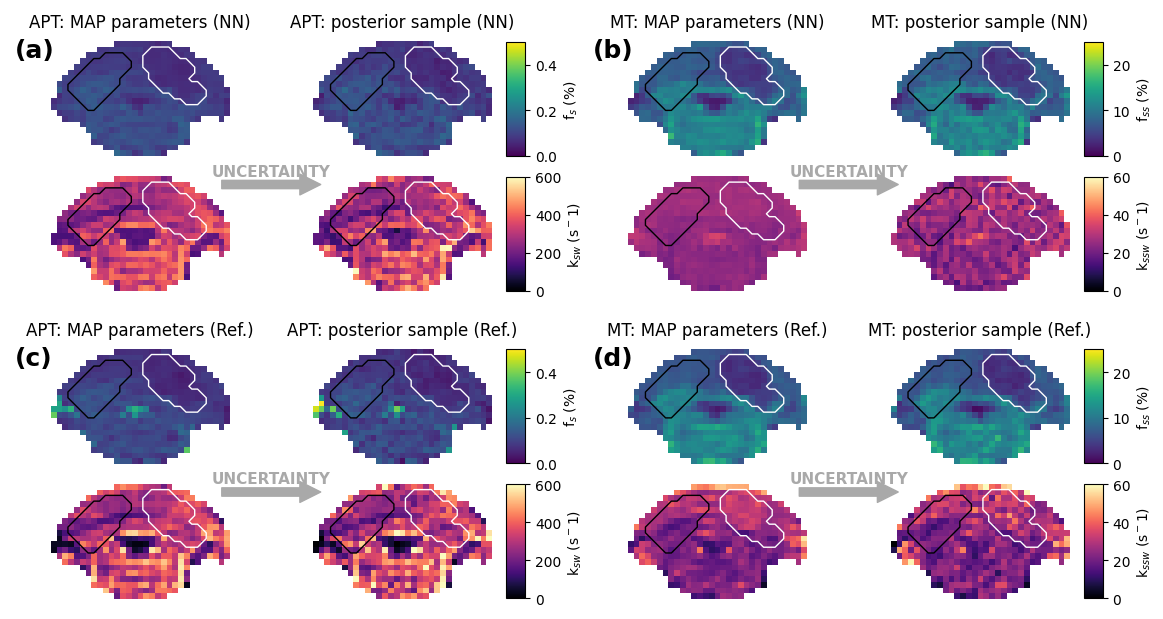

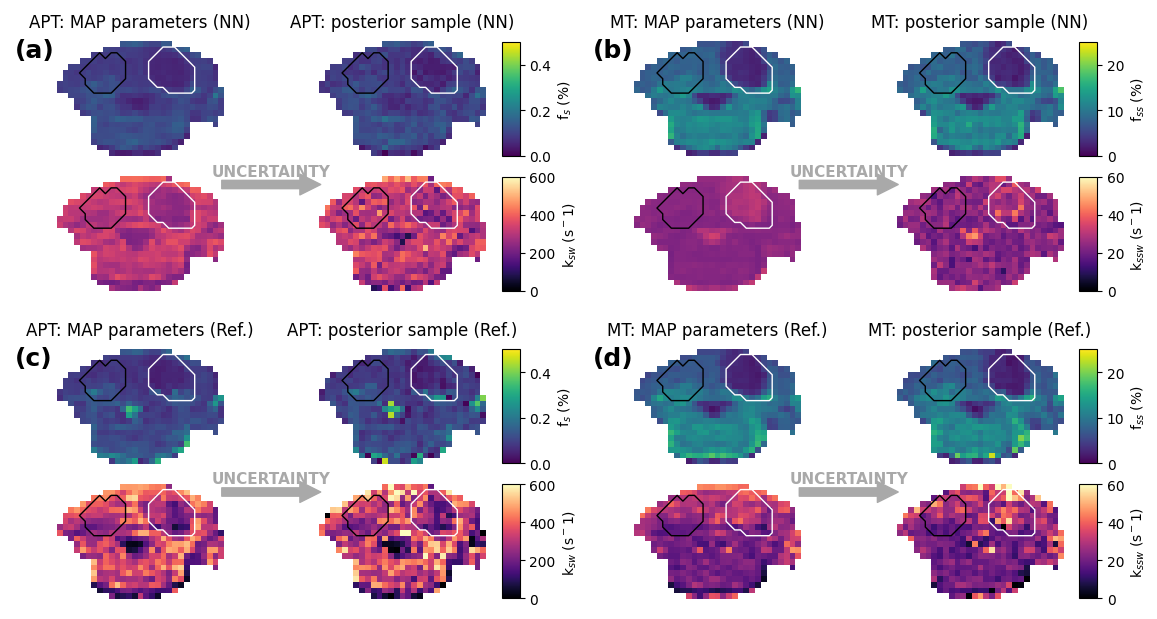

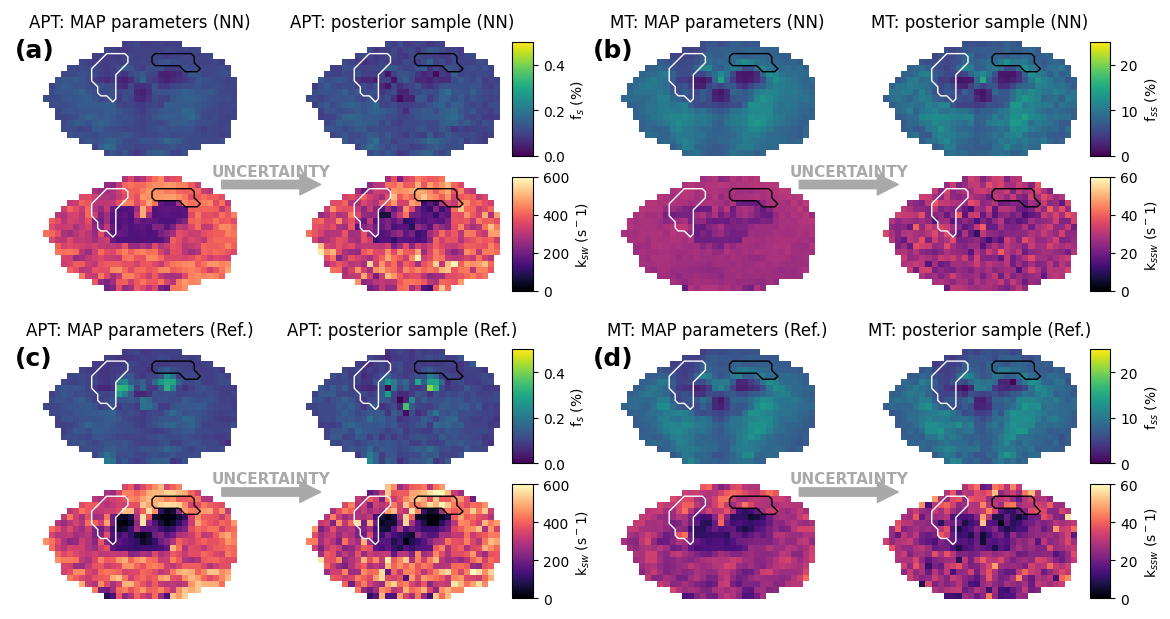

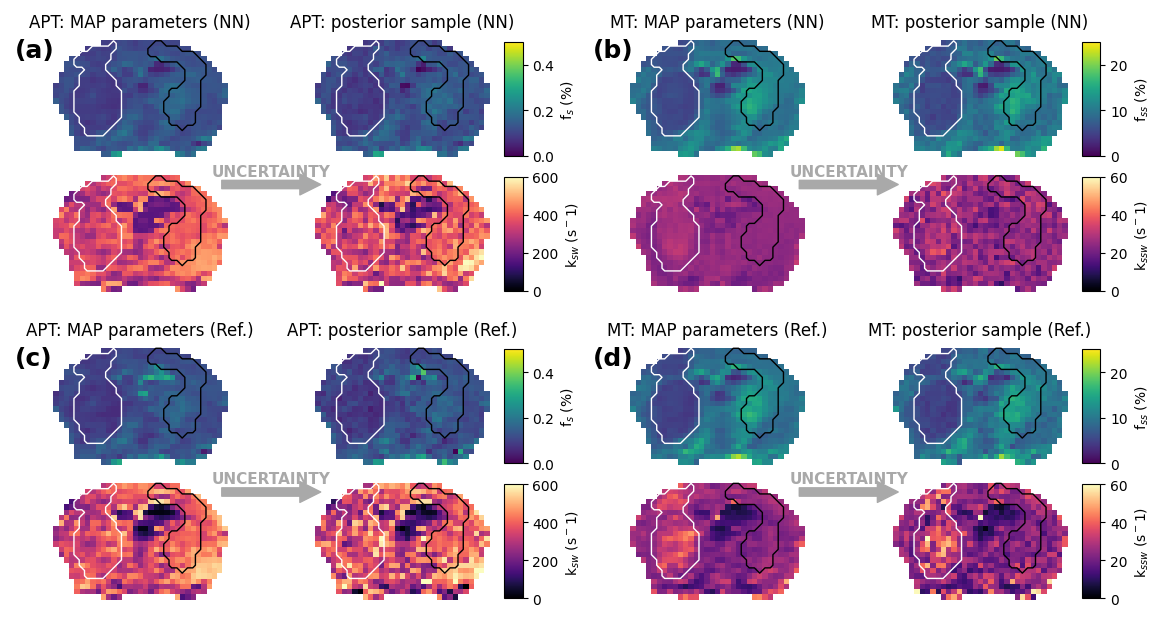

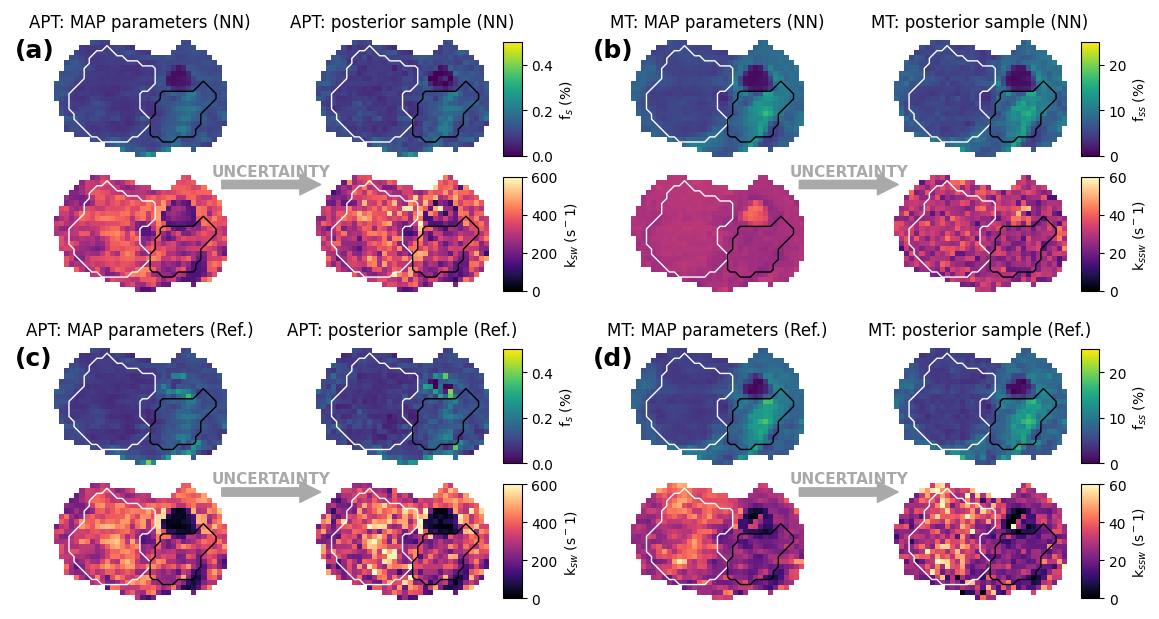

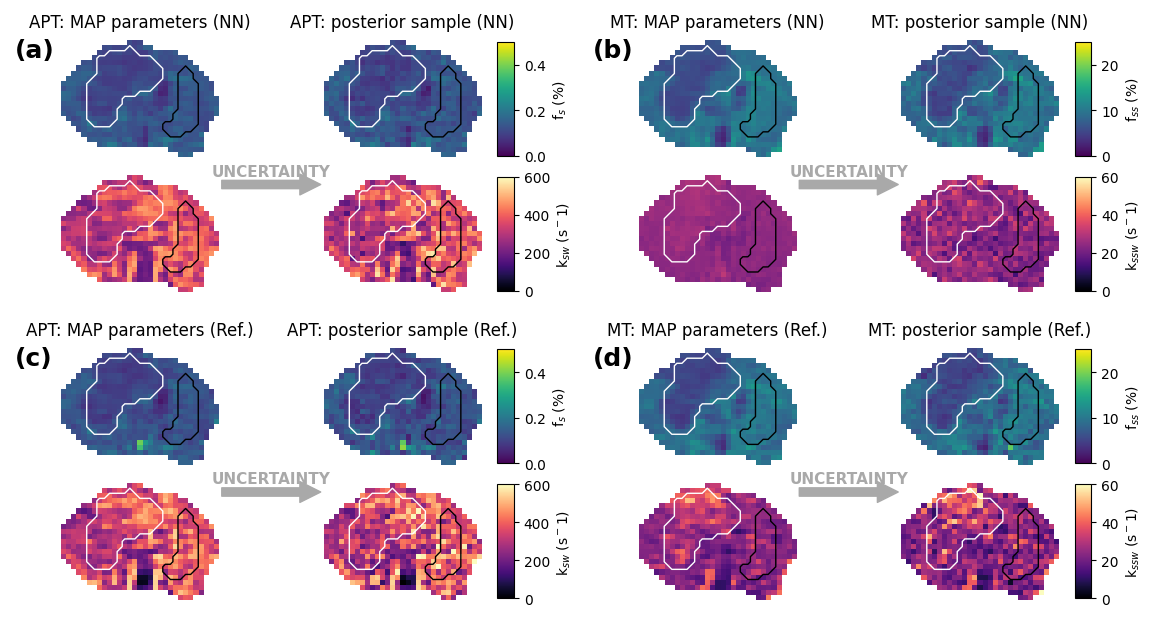

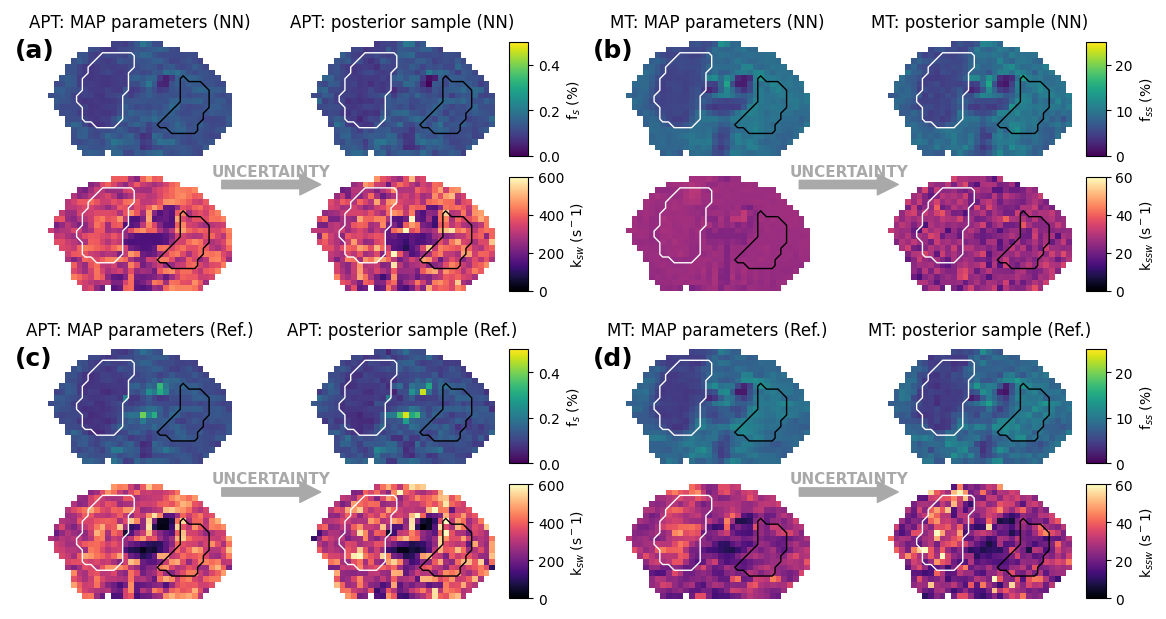

In [ ]:
def demo_dithering(mouse_name, fig=None, panel_labels=True, contours=True):
    fig = fig or plt.figure(figsize=(11, 6), constrained_layout=True)
    subfigs = fig.subfigures(2, 2, wspace=0.1, hspace=0.05, width_ratios=[1, 1])
    results_folder = f'figs/mice/{mouse_name}'
    mt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/mt_tissue_params_est.npz'))
    apt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/amide_tissue_params_est.npz')) 
    shape = apt_tissue_params_est['fc_T'].shape   
    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(apt_tissue_params_est, shape, is_cest=True)  
    
    mouse_UQ_stats = mice_APT_UQ_stats[mouse_name]
    fs_dict_est_map, ks_dict_est_map = [np.full(shape[0::2], np.nan) for jj in range(2)]
    fsks_cov_dict_est_map = np.full(shape[0::2]+(2,2), np.nan)
    for (_x, _y), f_k_dict_est, cov_dict_est in zip(
            mouse_UQ_stats['good_xy_points'], mouse_UQ_stats['means_of_exact_posterior'], 
            mouse_UQ_stats['covs_of_exact_posterior']
            ):
        fs_dict_est_map[_x, _y], ks_dict_est_map[_x, _y] = f_k_dict_est
        fsks_cov_dict_est_map[_x, _y] = cov_dict_est

    au.apps.nn_vs_ref_est_vs_posterior_sample(
        f_est[:,0,:], k_est[:,0,:], cov_nnpred_scaled[:,0,:,...], 
        fs_dict_est_map, ks_dict_est_map, fsks_cov_dict_est_map, 
        figNN= subfigs[0, 0], figRef= subfigs[1, 0], fmax=0.5, kmax=600, ss='s'
        )
    if panel_labels:
        slap_label_on_container(subfigs[0, 0], "(a)", loc=(0.01, 0.9))
        slap_label_on_container(subfigs[1, 0], "(c)", loc=(0.01, 0.9))
    
    f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
        au.extract_nn_estimate_of_posterior(mt_tissue_params_est, shape, is_cest=False)  
        
    mouse_UQ_stats = mice_MT_UQ_stats[mouse_name]
    fss_dict_est_map, kss_dict_est_map = [np.full(shape[0::2], np.nan) for jj in range(2)]
    fsskss_cov_dict_est_map = np.full(shape[0::2]+(2,2), np.nan)
    for (_x, _y), f_k_dict_est, cov_dict_est in zip(
            mouse_UQ_stats['good_xy_points'], mouse_UQ_stats['means_of_exact_posterior'], 
            mouse_UQ_stats['covs_of_exact_posterior']
            ):
        fss_dict_est_map[_x, _y], kss_dict_est_map[_x, _y] = f_k_dict_est
        fsskss_cov_dict_est_map[_x, _y] = cov_dict_est
                
    au.apps.nn_vs_ref_est_vs_posterior_sample(
        f_est[:,0,:], k_est[:,0,:], cov_nnpred_scaled[:,0,:,...], 
        fss_dict_est_map, kss_dict_est_map, fsskss_cov_dict_est_map, 
        figNN= subfigs[0, 1], figRef= subfigs[1, 1], fmax=25, kmax=60, ss='ss'
        )
    
    if panel_labels:
        slap_label_on_container(subfigs[0, 1], "(b)", loc=(0.01, 0.9))
        slap_label_on_container(subfigs[1, 1], "(d)", loc=(0.01, 0.9))

    arrtxt = "UNCERTAINTY"
    #Single sample of\n each voxel's posterior
    #Randomly apply \nvoxelwise uncertainty
    reload(au.helpers);
    for _label,_sfigrow in (
        (arrtxt, subfigs[0]), 
        (arrtxt, subfigs[1])):
        for _sfig in _sfigrow:
            au.helpers.draw_fat_arrow(
                _sfig, 
                start=(0.4, 0.4), 
                end=(0.6, 0.4), 
                label=_label,
                color="darkgray", fontsize=11
            )
    if contours:
        for subfig in subfigs.flatten():
            for ax in subfig.axes[:4]:
                ax.contour(mt_tissue_params_est['tumor_mask'].astype(float), levels=[0.5], colors='white', linewidths=1)
                ax.contour(mt_tissue_params_est['contralateral_mask'].astype(float), levels=[0.5], colors='black', linewidths=1)            
            
    return fig

for mouse_name in mice_MT_UQ_stats.keys():
    try:
        print(mouse_name)
        fig=demo_dithering(mouse_name)
        plt.savefig(f'figs/mice/{mouse_name}/fig_dithering.png', dpi=200)
    except Exception as e:
        raise(e)
        print(f"Could not make dithering fig for {mouse_name}")

## FINAL FIGURE (Fig. 8)

/home/alexf/phiVAE/analyze_uncertainty/apps.py:482: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  sample = np.random.multivariate_normal((mu_f, mu_k), _cov, size=psample)
/home/alexf/phiVAE/analyze_uncertainty/apps.py:482: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  sample = np.random.multivariate_normal((mu_f, mu_k), _cov, size=psample)
/home/alexf/phiVAE/analyze_uncertainty/apps.py:629: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  sample = np.random.multivariate_normal((mu_f, mu_k), cov, size=psample)


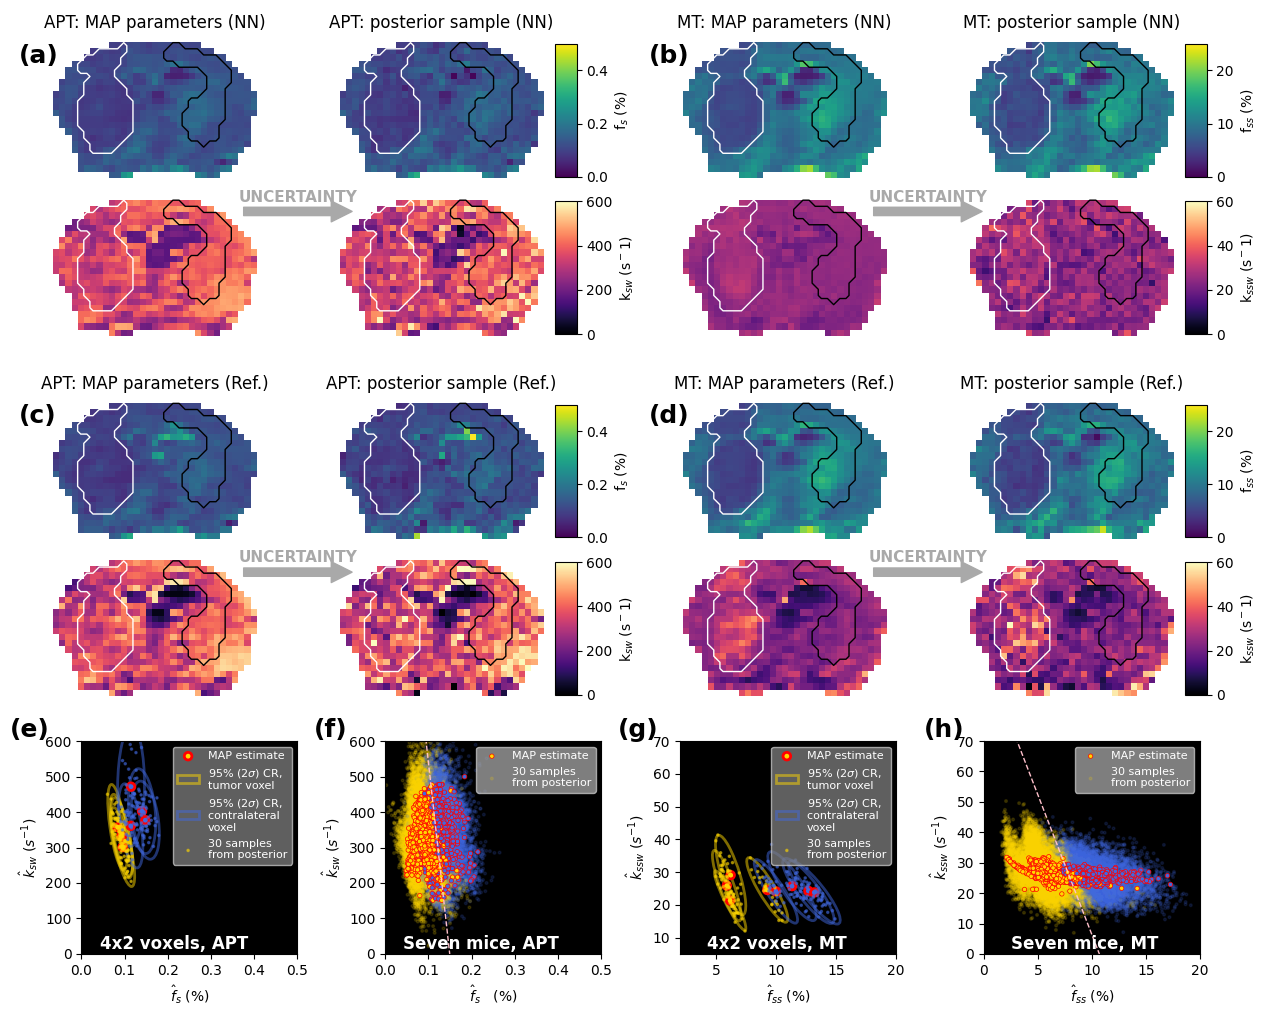

In [ ]:
mouse_name = 'ped_C1_1L_20241113_1245'
results_folder = f'figs/mice/{mouse_name}'

reload(au); reload(au.viz); reload(au.apps)
     
mainfig = plt.figure(figsize=(12, 10), constrained_layout=True) 
top_row, bottom_row = mainfig.subfigures(2, 1, hspace=0.05, height_ratios=[2.5, 1])

# === Top row - dithering demo with single mouse
demo_dithering(mouse_name, fig=top_row)

# == Bottom row, 1,3 (out of 0-3): classification apps for all mice aggregated

subfigs = bottom_row.subfigures(1, 4, width_ratios=(1, 1, 1, 1), wspace=0.05)

tmp_subfig = subfigs[1]
au.demo_classification_app(
        ff=ff_apt, kk=kk_apt, covcov=covcov_apt, 
        all_masked_labels=all_masked_labels,
        is_mt=False,
        fig=tmp_subfig  
    )
slap_label_on_container(tmp_subfig, "(f)", loc=(-0.01, 1.05))
slap_label_on_container(tmp_subfig, "Seven mice, APT", loc=(0.3, 0.27), color='white', fontsize=12)

tmp_subfig = subfigs[3]
au.demo_classification_app(
        ff=ff_mt, kk=kk_mt, covcov=covcov_mt, 
        all_masked_labels=all_masked_labels,
        is_mt=True, fig=tmp_subfig
    )
slap_label_on_container(tmp_subfig, "(h)", loc=(0, 1.05))
slap_label_on_container(tmp_subfig, "Seven mice, MT", loc=(0.3, 0.27), color='white', fontsize=12)

## == Bottom row, 0,2: posterior sampling demos for single mouse

mt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/mt_tissue_params_est.npz'))
shape = mt_tissue_params_est['fc_T'].shape    
points_mask1 = np.argwhere(mt_tissue_params_est['tumor_mask']==1).tolist()
points_mask2 = np.argwhere(mt_tissue_params_est['contralateral_mask']==1).tolist()

apt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/amide_tissue_params_est.npz'))
f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
    au.extract_nn_estimate_of_posterior(apt_tissue_params_est, shape, is_cest=True)  
inds1 = np.random.randint(0, len(points_mask1), 4).tolist()
inds2 = np.random.randint(0, len(points_mask2), 4).tolist()
labels = [1]*len(inds1) + [0]*len(inds2)
points = np.array(points_mask1)[inds1].tolist() + np.array(points_mask2)[inds2].tolist()
ff, kk, covcov, widths, heights, angles = [
    xmap[[p[0] for p in points], 0, [p[1] for p in points]]
    for xmap in [f_est, k_est, cov_nnpred_scaled, width, height, angle]
]
au.demo_posterior_sampling(ff, kk, covcov, widths, heights, angles, labels, fig=subfigs[0], fontsize=8, is_mt=False)
slap_label_on_container(subfigs[0], "(e)", loc=(-0.01, 1.05))
slap_label_on_container(subfigs[0], "4x2 voxels, APT", loc=(0.3, 0.27), color='white', fontsize=12)

# --------------------------------------

mt_tissue_params_est = dict(np.load(f'{results_folder}/intermediates/mt_tissue_params_est.npz'))
shape = mt_tissue_params_est['fc_T'].shape    
points_mask1 = np.argwhere(mt_tissue_params_est['tumor_mask']==1).tolist()
points_mask2 = np.argwhere(mt_tissue_params_est['contralateral_mask']==1).tolist()
f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
    au.extract_nn_estimate_of_posterior(mt_tissue_params_est, shape, is_cest=False)  
inds1 = np.random.randint(0, len(points_mask1), 4).tolist()
inds2 = np.random.randint(0, len(points_mask2), 4).tolist()
labels = [1]*len(inds1) + [0]*len(inds2)
points = np.array(points_mask1)[inds1].tolist() + np.array(points_mask2)[inds2].tolist()
ff, kk, covcov, widths, heights, angles = [
    xmap[[p[0] for p in points], 0, [p[1] for p in points]]
    for xmap in [f_est, k_est, cov_nnpred_scaled, width, height, angle]
]
au.demo_posterior_sampling(ff, kk, covcov, widths, heights, angles, labels, fig=subfigs[2], fontsize=8)
slap_label_on_container(subfigs[2], "(g)", loc=(-0.01, 1.05))
slap_label_on_container(subfigs[2], "4x2 voxels, MT", loc=(0.3, 0.27), color='white', fontsize=12)
plt.xlim(0, 15)

############################################################

plt.savefig(f'figs/mice/{mouse_name}/mouse_dither_UQvsRoI.png', dpi=300, bbox_inches='tight')
plt.savefig(f'figs/mice/{mouse_name}/mouse_dither_UQvsRoI_LOWRES.png', dpi=100, bbox_inches='tight')
plt.savefig(f'figs/mice/mouse_dither_UQvsRoI.png', dpi=300, bbox_inches='tight')
plt.savefig(f'figs/mice/mouse_dither_UQvsRoI_LOWRES.png', dpi=100, bbox_inches='tight')

In [ ]:
mouse_name

'ped_C1_1L_20241113_1245'

## MOVIE CREATION (Video 1)

In [ ]:
reload(au); reload(au.helpers)
nf = 10
frames = au.helpers.create_frames(demo_dithering, num_frames=nf*3, mouse_name='ped_C1_1L_20241113_1245')
frames += au.helpers.create_frames(demo_dithering, num_frames=nf*3, mouse_name='ozohar_right_20240404_125156')
for mouse_name in set(mice_MT_UQ_stats.keys()) - {'ped_C1_1L_20241113_1245', 'ozohar_right_20240404_125156'}:
    try:
        print(mouse_name)
        frames += au.helpers.create_frames(demo_dithering, num_frames=nf, mouse_name=mouse_name)
    except Exception as e:
        raise(e)
        print(f"Could not make dithering frames for {mouse_name}")

Generating frame 1/30...


/home/alexf/phiVAE/analyze_uncertainty/apps.py:678: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  sample = np.random.multivariate_normal(


Generating frame 2/30...
Generating frame 3/30...
Generating frame 4/30...
Generating frame 5/30...
Generating frame 6/30...
Generating frame 7/30...
Generating frame 8/30...
Generating frame 9/30...
Generating frame 10/30...
Generating frame 11/30...
Generating frame 12/30...
Generating frame 13/30...
Generating frame 14/30...
Generating frame 15/30...
Generating frame 16/30...
Generating frame 17/30...
Generating frame 18/30...
Generating frame 19/30...
Generating frame 20/30...
Generating frame 21/30...
Generating frame 22/30...
Generating frame 23/30...
Generating frame 24/30...
Generating frame 25/30...
Generating frame 26/30...
Generating frame 27/30...
Generating frame 28/30...
Generating frame 29/30...
Generating frame 30/30...
Generating frame 1/30...
Generating frame 2/30...
Generating frame 3/30...
Generating frame 4/30...
Generating frame 5/30...
Generating frame 6/30...
Generating frame 7/30...
Generating frame 8/30...
Generating frame 9/30...
Generating frame 10/30...
Gen

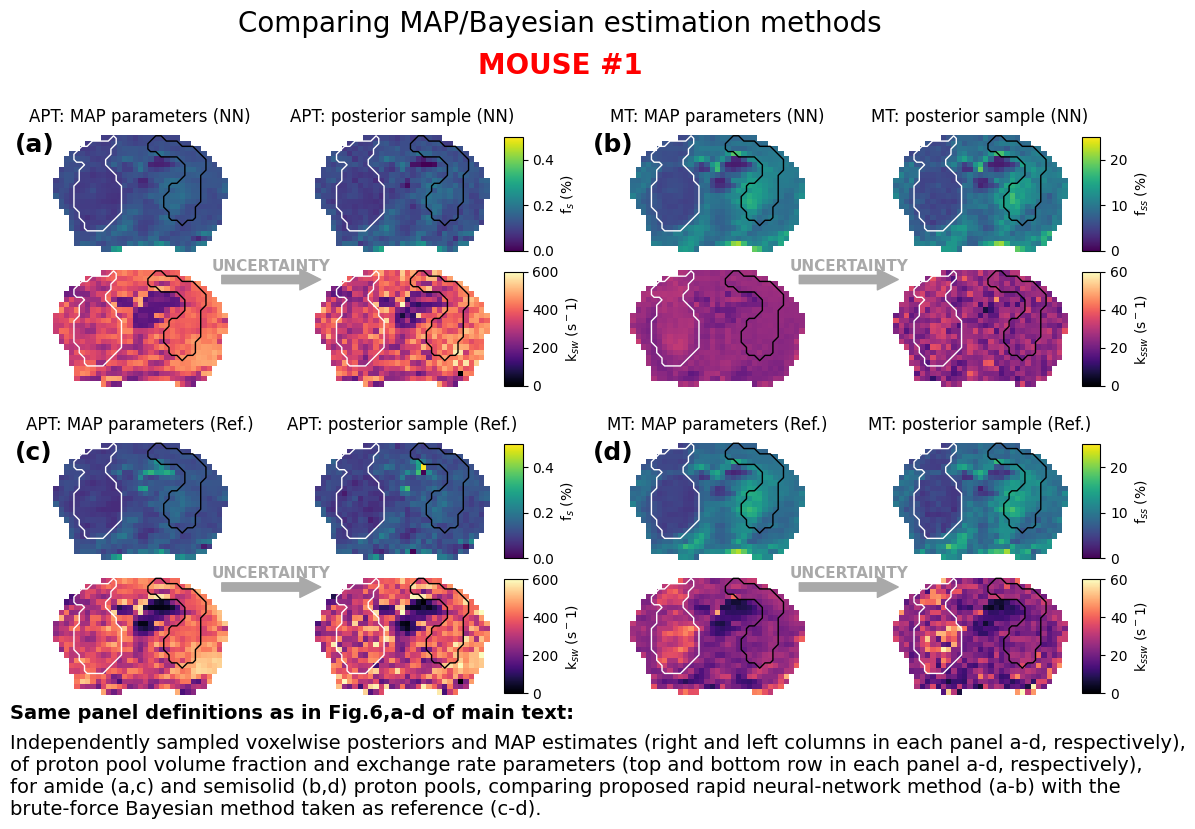

In [ ]:
def annotate_dither_fig(fig, mouse_id=1):
    fig.text(0.5, 1.12, "Comparing MAP/Bayesian estimation methods", ha='center', fontsize=20) #16, fontweight='bold')
    fig.text(0.5, 1.05, f"MOUSE #{mouse_id}", ha='center', fontsize=20, color='red', fontweight='bold')
    fig.text(0.0, 0.0, "Same panel definitions as in Fig.6,a-d of main text:", ha='left', va='top', fontsize=14, fontweight='bold')
    fig.text(0.0, -0.05, "Independently sampled voxelwise posteriors and MAP estimates (right and left columns in each panel a-d, respectively),\n"+
             "of proton pool volume fraction and exchange rate parameters (top and bottom row in each panel a-d, respectively),\n"+
            "for amide (a,c) and semisolid (b,d) proton pools, comparing proposed rapid neural-network method (a-b) with the\nbrute-force Bayesian method taken as reference (c-d).", 
            va='top', ha='left', fontsize=14)

fig = demo_dithering('ped_C1_1L_20241113_1245')
annotate_dither_fig(fig, 1)

In [ ]:
reload(au); reload(au.helpers)


def dith_fig(mouse_name, mouse_id):
    fig = demo_dithering(mouse_name, panel_labels=True, contours=False)
    annotate_dither_fig(fig, mouse_id)
    return fig
    
def fig_generator(frames_per_mouse=2):
    fpm = frames_per_mouse
    for _ in range(fpm*4):
        yield dith_fig('ped_C1_1L_20241113_1245', 1 )
    for _ in range(fpm*3):
        yield dith_fig('ozohar_right_20240404_125156', 2)
    for ii, mouse_name in enumerate( set(mice_MT_UQ_stats.keys()) - {'ped_C1_1L_20241113_1245', 'ozohar_right_20240404_125156'}):
        try:
            print(mouse_name)
            for _ in range(fpm*2):
                yield dith_fig(mouse_name, ii+3)
        except Exception as e:
            print(f"Could not make dithering frames for {mouse_name}")  

# better use 'libx264' (H.264) and 'yuv420p' to ensure compatibility with standard players (QuickTime, Windows, Web) ??            
au.helpers.save_frames_to_mp4(fig_generator(frames_per_mouse=15), 'figs/dither_all_mice.mp4', fps=15)

ped_Control_2R_2025-01-09
ped_Control_None_2025-01-09
ped_Control_1L1R_2025-01-09
ped_Control_2L_2025-01-09
ozohar_two_ears_20240404_091158
Falling back to OpenCV VideoWriter...
Video saved to figs/dither_all_mice.mp4 (via cv2/mp4v)


In [ ]:
# ffmpeg -y -i figs/dither_all_mice.mp4 -c:v libx264 -profile:v high -level 4.0 -pix_fmt yuv420p -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" -r 15 -movflags +faststart figs/dither_all_mice_compatible.mp4

### Removed content

see versions before 2026-Jan-27